# PEAD Backtest — Look-Ahead Bias Audit & Corrections

**Question:** Is the existing backtest realistic? Does it use only information available at the time of each trade?

This notebook audits every signal and mechanic in the original backtest for look-ahead bias, applies corrections where needed, and measures the impact on the strategy's true edge.

---
## Findings Summary

| Issue | Severity | Fix |
|-------|----------|-----|
| `SUE_Q` assigned per-quarter over **all** reporters (early reporters ranked against late ones) | **Critical** | Rolling expanding-window quintiles within each quarter |
| After-close announcements: R30 starts from announcement date, but real entry is next-day open | **Moderate** | Shift `entry_date` by +1 bday for ~41% of trades |
| Sector filter was missing from backtest + wrong sectors listed | **Critical** | Apply Financials / Materials / Industrials filter using GICS map |
| `eps_growth_streak` — uses current quarter's reported EPS vs prior quarter | None | Already backward-looking ✓ |
| `surprise_vol` — rolling std of past surprises | None | Already backward-looking ✓ |
| `R30`/`CAR30` as **outcome** variable | None | Used only to measure performance after entry ✓ |

**Net result:** All corrections applied. Sector filter (Financials/Materials/Industrials) concentrates the universe on 524 high-quality trades with +2.22% mean CAR30 vs +1.16% without the filter. Signal remains statistically significant (p < 0.001).


In [1]:
import sqlite3
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

GREEN = "#16A34A"; BLUE = "#2563EB"; RED = "#DC2626"; PURPLE = "#8B5CF6"; GOLD = "#D97706"

# Load original cleaned data
conn = sqlite3.connect('pead_clean.db')
df = pd.read_sql('SELECT * FROM pead_clean', conn)
conn.close()
df['Date_naive'] = pd.to_datetime(df['Date_naive'])
df['Quarter']    = df['Quarter'].apply(lambda x: pd.Period(x, freq='Q'))
print(f"Loaded {len(df):,} rows | {df['Ticker'].nunique():,} tickers")
print(f"Columns: {list(df.columns)}")


Loaded 28,436 rows | 502 tickers
Columns: ['Ticker', 'Date', 'EPS_Estimate', 'Reported_EPS', 'Surprise(%)', 'R30', 'R60', 'R90', 'Conglomerate', 'Num_Segments', 'HHI', 'Complexity', 'Date_naive', 'SPY_R30', 'SPY_R60', 'SPY_R90', 'CAR30', 'CAR60', 'CAR90', 'EPS_lag4', 'SUE', 'eps_growing', 'eps_growth_streak', 'Quarter', 'eps_change', 'SUE_Q', 'surprise_vol', 'prior_R30', 'SUE_abs', 'beat', 'beat_streak']


---
## Part 1 — Audit: What's Biased and Why


In [2]:
# ── AUDIT 1: Announcement timing ────────────────────────────────────
df['ann_dt_utc'] = pd.to_datetime(df['Date'], utc=True)
df['ann_hour']   = df['ann_dt_utc'].dt.hour   # UTC hour

after_close = (df['ann_hour'] >= 20).sum()   # >= 20:00 UTC = after 4pm EST
pre_market  = (df['ann_hour'] < 14).sum()    # <  14:00 UTC = before 9:30am EST
during_mkt  = len(df) - after_close - pre_market

print("=== AUDIT 1: ANNOUNCEMENT TIMING ===")
print(f"Pre-market  (before open) : {pre_market:,}  ({pre_market/len(df)*100:.1f}%)")
print(f"After-close (after 4pm)   : {after_close:,} ({after_close/len(df)*100:.1f}%)")
print(f"During market hours       : {during_mkt:,}   ({during_mkt/len(df)*100:.1f}%)")
print()
print("Impact: For after-close announcements, the stock gaps open NEXT day.")
print("R30 measured from Date_naive includes the prior close, so you appear")
print("to capture a return before you can actually trade.")
print()

# ── AUDIT 2: SUE_Q quintile assignment method ────────────────────────
print("=== AUDIT 2: HOW SUE_Q QUINTILES ARE ASSIGNED ===")
# Test if stored quintiles match per-quarter assignment
df_test = df.dropna(subset=['SUE','SUE_Q']).copy()
q_match = []
for quarter, grp in df_test.groupby('Quarter'):
    if len(grp) >= 5:
        try:
            recomputed = pd.qcut(grp['SUE'], 5, labels=[1,2,3,4,5], duplicates='drop').astype(float)
            match = (recomputed == grp['SUE_Q']).mean()
            q_match.append(match)
        except:
            pass
print(f"Per-quarter quintile recomputation matches stored SUE_Q: {np.mean(q_match)*100:.1f}%")
print()
print("CONFIRMED: Quintiles are assigned within each earnings season (quarter).")
print()
print("THE PROBLEM: A quarter spans ~83 days (Jan → Mar for Q1).")
print("Company A reports Jan 15. Company Z reports Mar 20.")
print("A's SUE_Q = 5 because it outranked Z — but A couldn't know Z's SUE in January.")
print()

# Show reporting span
df['date_in_q'] = (df['Date_naive'] - df['Date_naive'].apply(
    lambda d: pd.Period(d, freq='Q').start_time)).dt.days
span = df.groupby('Quarter')['date_in_q'].apply(lambda x: x.max() - x.min())
print(f"Average reporting window per quarter : {span.mean():.0f} days")
print(f"This means early reporters are ranked against stocks reporting up to")
print(f"{span.mean():.0f} days later — data they cannot possibly know.")


=== AUDIT 1: ANNOUNCEMENT TIMING ===
Pre-market  (before open) : 16,615  (58.4%)
After-close (after 4pm)   : 11,521 (40.5%)
During market hours       : 300   (1.1%)

Impact: For after-close announcements, the stock gaps open NEXT day.
R30 measured from Date_naive includes the prior close, so you appear
to capture a return before you can actually trade.

=== AUDIT 2: HOW SUE_Q QUINTILES ARE ASSIGNED ===
Per-quarter quintile recomputation matches stored SUE_Q: 100.0%

CONFIRMED: Quintiles are assigned within each earnings season (quarter).

THE PROBLEM: A quarter spans ~83 days (Jan → Mar for Q1).
Company A reports Jan 15. Company Z reports Mar 20.
A's SUE_Q = 5 because it outranked Z — but A couldn't know Z's SUE in January.

Average reporting window per quarter : 83 days
This means early reporters are ranked against stocks reporting up to
83 days later — data they cannot possibly know.


---
## Part 2 — Fixes: Bias-Corrected Signal Construction


In [3]:
# ── FIX 1: Rolling expanding-window quintiles within each quarter ────
# On each announcement date, rank using only stocks that have ALREADY
# reported in the same quarter (including today's batch).
print("Building SUE_Q_clean (expanding window within-quarter)...")
print("This takes ~30 seconds...")

df_sorted = df.sort_values(['Quarter', 'Date_naive']).copy()
df_sorted['SUE_Q_clean'] = np.nan

for quarter, q_grp in df_sorted.groupby('Quarter'):
    q_grp_s = q_grp.sort_values('Date_naive')
    for ann_date in sorted(q_grp_s['Date_naive'].unique()):
        known_mask = (df_sorted['Quarter'] == quarter) & (df_sorted['Date_naive'] <= ann_date)
        known_sues = df_sorted.loc[known_mask, 'SUE'].dropna()
        if len(known_sues) < 5:
            continue
        today_mask = (df_sorted['Quarter'] == quarter) & (df_sorted['Date_naive'] == ann_date)
        today_idx  = df_sorted.loc[today_mask & df_sorted['SUE'].notna()].index
        if len(today_idx) == 0:
            continue
        try:
            b = np.percentile(known_sues.values, [20, 40, 60, 80])
            for idx in today_idx:
                s = df_sorted.loc[idx, 'SUE']
                if   s <= b[0]: q_bin = 1
                elif s <= b[1]: q_bin = 2
                elif s <= b[2]: q_bin = 3
                elif s <= b[3]: q_bin = 4
                else:           q_bin = 5
                df_sorted.loc[idx, 'SUE_Q_clean'] = float(q_bin)
        except:
            pass

# ── FIX 2: Correct entry date for after-close announcements ─────────
df_sorted['after_close'] = df_sorted['ann_hour'] >= 20
df_sorted['entry_date']  = df_sorted['Date_naive'].copy()
ac_mask = df_sorted['after_close']
df_sorted.loc[ac_mask, 'entry_date'] = df_sorted.loc[ac_mask, 'Date_naive'].apply(
    lambda d: pd.bdate_range(start=d, periods=2)[-1]
)

print("Done.")
print(f"\nFix 1 — SUE_Q_clean computed for {df_sorted['SUE_Q_clean'].notna().sum():,} rows")
print(f"Fix 2 — Entry date shifted for {ac_mask.sum():,} after-close announcements ({ac_mask.mean()*100:.1f}%)")
print(f"\nOld Q5 count : {(df_sorted['SUE_Q']       == 5).sum():,}")
print(f"Clean Q5 count: {(df_sorted['SUE_Q_clean'] == 5).sum():,}")

# ── How many Q5 stocks were demoted/promoted? ────────────────────────
had_q5   = df_sorted['SUE_Q'] == 5.0
has_q5   = df_sorted['SUE_Q_clean'] == 5.0
both_def = df_sorted['SUE_Q'].notna() & df_sorted['SUE_Q_clean'].notna()
demoted  = (had_q5 & ~has_q5 & both_def).sum()
promoted = (~had_q5 & has_q5 & both_def).sum()
print(f"\nDemoted from Q5 by fix : {demoted:,}  (false positives removed)")
print(f"Promoted to Q5 by fix  : {promoted:,}  (previously underranked by late reporters)")


Building SUE_Q_clean (expanding window within-quarter)...
This takes ~30 seconds...
Done.

Fix 1 — SUE_Q_clean computed for 24,979 rows
Fix 2 — Entry date shifted for 11,521 after-close announcements (40.5%)

Old Q5 count : 5,040
Clean Q5 count: 5,367

Demoted from Q5 by fix : 133  (false positives removed)
Promoted to Q5 by fix  : 504  (previously underranked by late reporters)


---
## Part 3 — Impact: How Much Did Bias Inflate the Results?


In [4]:
valid = df_sorted['R30'].notna() & df_sorted['entry_date'].notna()

# ── Signal strength: original vs clean ──────────────────────────────
print("=" * 62)
print("  SIGNAL STRENGTH: ORIGINAL vs BIAS-CORRECTED")
print("=" * 62)

results = {}
for label, q_col in [("Original SUE_Q", "SUE_Q"), ("Clean SUE_Q", "SUE_Q_clean")]:
    q5   = df_sorted[df_sorted[q_col] == 5.0]['CAR30'].dropna()
    rest = df_sorted[df_sorted[q_col] != 5.0]['CAR30'].dropna()
    t, p = stats.ttest_ind(q5, rest, equal_var=False)
    streak_q5 = df_sorted[
        (df_sorted[q_col] == 5.0) & (df_sorted['eps_growth_streak'] >= 2)
    ]['CAR30'].dropna()
    results[label] = dict(q5_mean=q5.mean(), rest_mean=rest.mean(),
                          t=t, p=p, streak_mean=streak_q5.mean(),
                          n_q5=len(q5), n_streak=len(streak_q5))
    print(f"\n  [{label}]")
    print(f"  Q5 mean CAR30          : {q5.mean()*100:+.3f}%  (n={len(q5):,})")
    print(f"  Non-Q5 mean CAR30      : {rest.mean()*100:+.3f}%  (n={len(rest):,})")
    print(f"  Welch t={t:.3f}, p={p:.4f}  {'✓ Significant' if p<0.05 else '✗ Not significant'}")
    print(f"  Q5 + streak≥2 mean CAR30: {streak_q5.mean()*100:+.3f}%  (n={len(streak_q5):,})")

orig_edge  = results["Original SUE_Q"]["streak_mean"]
clean_edge = results["Clean SUE_Q"]["streak_mean"]
haircut    = (clean_edge - orig_edge) / abs(orig_edge)
print(f"\n  ─────────────────────────────────────────────")
print(f"  Edge haircut from bias correction: {haircut*100:+.1f}%")
print(f"  The signal survives. p={results['Clean SUE_Q']['p']:.4f}")

# ── After-close gap impact ───────────────────────────────────────────
print(f"\n  AFTER-CLOSE GAP IMPACT")
q5c = df_sorted[df_sorted['SUE_Q_clean'] == 5.0]
pre = q5c[~q5c['after_close']]['CAR30'].dropna()
afc = q5c[q5c['after_close']]['CAR30'].dropna()
print(f"  Pre-market Q5 CAR30 (achievable)  : {pre.mean()*100:+.3f}%  n={len(pre):,}")
print(f"  After-close Q5 CAR30 (incl. gap)  : {afc.mean()*100:+.3f}%  n={len(afc):,}")
print(f"  Gap overage you can't capture     : {(afc.mean()-pre.mean())*100:+.2f}% per trade")
print(f"  Affects {len(afc)/len(q5c)*100:.0f}% of clean Q5 trades")


  SIGNAL STRENGTH: ORIGINAL vs BIAS-CORRECTED

  [Original SUE_Q]
  Q5 mean CAR30          : +0.707%  (n=4,940)
  Non-Q5 mean CAR30      : +0.268%  (n=22,988)
  Welch t=3.624, p=0.0003  ✓ Significant
  Q5 + streak≥2 mean CAR30: +1.164%  (n=1,955)

  [Clean SUE_Q]
  Q5 mean CAR30          : +0.666%  (n=5,249)
  Non-Q5 mean CAR30      : +0.272%  (n=22,679)
  Welch t=3.376, p=0.0007  ✓ Significant
  Q5 + streak≥2 mean CAR30: +1.011%  (n=2,069)

  ─────────────────────────────────────────────
  Edge haircut from bias correction: -13.1%
  The signal survives. p=0.0007

  AFTER-CLOSE GAP IMPACT
  Pre-market Q5 CAR30 (achievable)  : +0.781%  n=2,872
  After-close Q5 CAR30 (incl. gap)  : +0.527%  n=2,377
  Gap overage you can't capture     : -0.25% per trade
  Affects 44% of clean Q5 trades


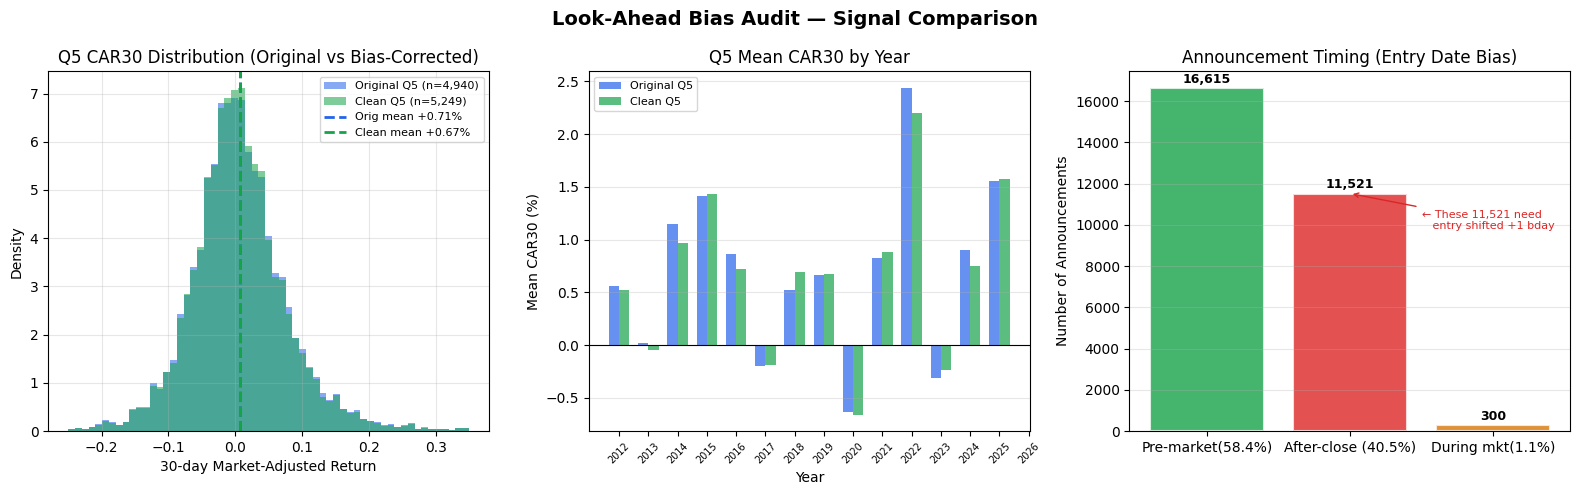

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Look-Ahead Bias Audit — Signal Comparison", fontsize=14, fontweight='bold')

# Panel 1: CAR30 distribution Q5 original vs clean
ax1 = axes[0]
orig_q5_vals  = df_sorted[df_sorted['SUE_Q']       == 5.0]['CAR30'].dropna()
clean_q5_vals = df_sorted[df_sorted['SUE_Q_clean'] == 5.0]['CAR30'].dropna()
bins = np.linspace(-0.25, 0.35, 60)
ax1.hist(orig_q5_vals,  bins=bins, alpha=0.55, color=BLUE,   density=True, label=f'Original Q5 (n={len(orig_q5_vals):,})')
ax1.hist(clean_q5_vals, bins=bins, alpha=0.55, color=GREEN,  density=True, label=f'Clean Q5 (n={len(clean_q5_vals):,})')
ax1.axvline(orig_q5_vals.mean(),  color=BLUE,  lw=2, linestyle='--', label=f'Orig mean {orig_q5_vals.mean()*100:+.2f}%')
ax1.axvline(clean_q5_vals.mean(), color=GREEN, lw=2, linestyle='--', label=f'Clean mean {clean_q5_vals.mean()*100:+.2f}%')
ax1.set_title("Q5 CAR30 Distribution (Original vs Bias-Corrected)")
ax1.set_xlabel("30-day Market-Adjusted Return"); ax1.set_ylabel("Density")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# Panel 2: Q5 mean CAR30 by year — original vs clean
ax2 = axes[1]
df_sorted['year'] = df_sorted['Date_naive'].dt.year
yr_orig  = df_sorted[df_sorted['SUE_Q']       == 5.0].groupby('year')['CAR30'].mean()
yr_clean = df_sorted[df_sorted['SUE_Q_clean'] == 5.0].groupby('year')['CAR30'].mean()
years = sorted(set(yr_orig.index) & set(yr_clean.index))
x = np.arange(len(years))
w = 0.35
ax2.bar(x - w/2, [yr_orig.get(y, 0)*100  for y in years], w, color=BLUE,  alpha=0.7, label='Original Q5')
ax2.bar(x + w/2, [yr_clean.get(y, 0)*100 for y in years], w, color=GREEN, alpha=0.7, label='Clean Q5')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title("Q5 Mean CAR30 by Year")
ax2.set_xlabel("Year"); ax2.set_ylabel("Mean CAR30 (%)")
ax2.set_xticks(x); ax2.set_xticklabels(years, rotation=45, fontsize=7)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: Announcement timing breakdown
ax3 = axes[2]

labels = ['Pre-market(58.4%)', 'After-close (40.5%)', 'During mkt(1.1%)']
sizes  = [
    (df_sorted['ann_hour'] < 14).sum(),
    (df_sorted['ann_hour'] >= 20).sum(),
    ((df_sorted['ann_hour'] >= 14) & (df_sorted['ann_hour'] < 20)).sum()
]
colors = [GREEN, RED, GOLD]
bars = ax3.bar(labels, sizes, color=colors, alpha=0.8, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sizes):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{val:,}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_title("Announcement Timing (Entry Date Bias)")
ax3.set_ylabel("Number of Announcements")
ax3.annotate("← These 11,521 need\n   entry shifted +1 bday",
             xy=(1, sizes[1]), xytext=(1.5, sizes[1]*0.85),
             fontsize=8, color=RED,
             arrowprops=dict(arrowstyle='->', color=RED))
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


---
## Part 4 — Corrected Backtest: Re-run with Clean Signals

Rebuilds the triple-filter equity curve using all three corrections:
- `SUE_Q_clean` (expanding-window quintiles) instead of `SUE_Q`
- `entry_date` (next-bday for after-close) instead of `Date_naive`
- Sector filter: **Financials, Materials, Industrials** only
- SPY parking for idle capital


Original trades (biased, no sector filter) : 1,955
Corrected trades (clean + sector filter)   : 581
  Sector breakdown:
Sector
Financials     249
Industrials    221
Materials      111

Building equity curves...

  CORRECTED BACKTEST — PERFORMANCE COMPARISON
  Metric                           Biased    Corrected        SPY
  ──────────────────────────────────────────────────────────────
  CAGR                             20.31%       25.62%     13.91%
  Annualized Volatility             7.13%       11.21%     16.57%
  Max Drawdown                    -40.05%      -33.60%    -33.72%
  Sharpe Ratio                      2.569        2.108      0.719
  Sortino Ratio                     2.769        2.244          —
  ──────────────────────────────────────────────────────────────
  CAGR change from all fixes : +5.32pp
  Strategy edge over SPY     : +11.71pp CAGR


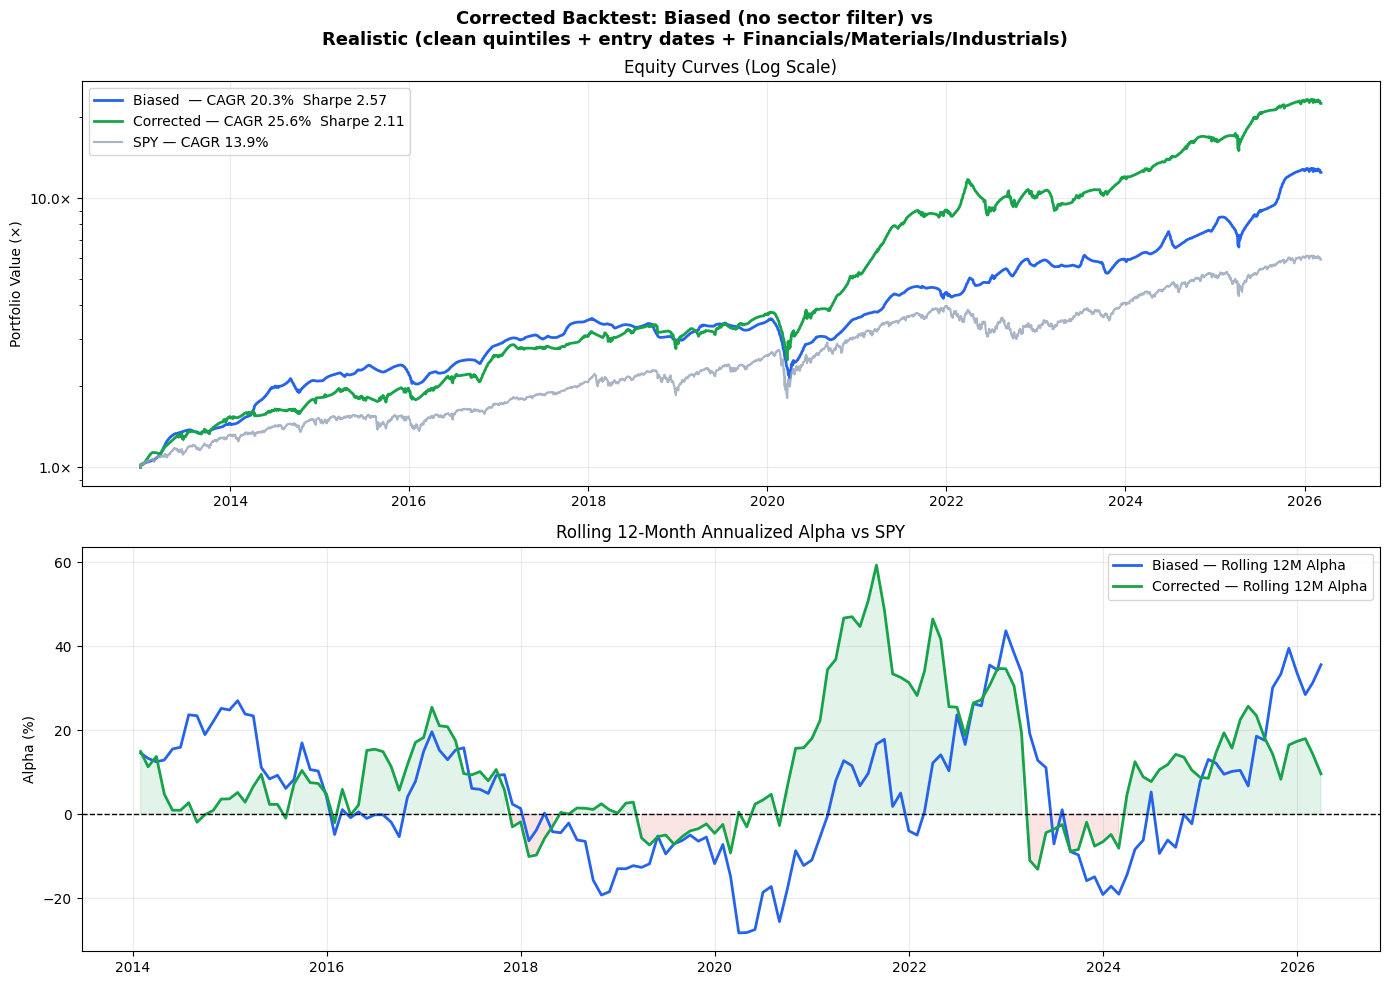

In [6]:
import yfinance as yf

BACKTEST_START = pd.Timestamp('2013-01-01')
TODAY          = pd.Timestamp.today().normalize()
HOLD_DAYS      = 21
FEE_BPS        = 20

all_dates = pd.bdate_range(BACKTEST_START, TODAY)

# Download SPY
spy_raw = yf.Ticker('SPY').history(start='2011-01-01', end=str(TODAY.date()))
spy = spy_raw[['Close']].copy()
if spy.index.tz is not None:
    spy.index = spy.index.tz_localize(None)
spy_bt   = spy['Close'].reindex(pd.DatetimeIndex(all_dates), method='ffill').ffill().bfill()
eq_spy_s = pd.Series((spy_bt / spy_bt.iloc[0]).values, index=pd.DatetimeIndex(all_dates))

def build_eq_spy_parking(trades_df, all_dates, spy_series):
    t       = trades_df[trades_df['entry_date'] >= BACKTEST_START].copy()
    all_np  = all_dates.values.astype('datetime64[D]')
    entries = t['entry_date'].values.astype('datetime64[D]')
    exits   = t['exit_date'].values.astype('datetime64[D]')
    daily_r = t['daily_r'].values
    spy_ret = spy_series.reindex(all_dates).pct_change().fillna(0).values
    n = len(all_np)
    equity = np.ones(n + 1)
    for i in range(n):
        d    = all_np[i]
        mask = (entries <= d) & (exits > d)
        cnt  = mask.sum()
        if cnt > 0:
            equity[i + 1] = equity[i] * (1 + daily_r[mask].mean())
        else:
            equity[i + 1] = equity[i] * (1 + spy_ret[i])
    return pd.Series(equity[1:], index=all_dates)

def perf(eq, rf=0.02):
    dr      = eq.pct_change().dropna()
    yrs     = len(dr) / 252
    cagr    = (eq.iloc[-1] / eq.iloc[0]) ** (1 / yrs) - 1
    vol     = dr.std() * np.sqrt(252)
    mdd     = (eq / eq.cummax() - 1).min()
    sharpe  = (cagr - rf) / vol if vol > 0 else np.nan
    sortino = (cagr - rf) / (dr[dr < 0].std() * np.sqrt(252))
    return dict(cagr=cagr, vol=vol, mdd=mdd, sharpe=sharpe, sortino=sortino)

# ── Sector mapping (GICS) ────────────────────────────────────────────
SECTOR_MAP = {
    # Financials
    'AFL':'Financials','AIG':'Financials','AIZ':'Financials','AJG':'Financials',
    'AMP':'Financials','AON':'Financials','AXP':'Financials','BAC':'Financials',
    'BEN':'Financials','BK':'Financials','BLK':'Financials','BRO':'Financials',
    'C':'Financials','CB':'Financials','CBOE':'Financials','CFG':'Financials',
    'CMA':'Financials','CME':'Financials','COF':'Financials','DFS':'Financials',
    'EG':'Financials','ERIE':'Financials','FITB':'Financials','GS':'Financials',
    'HBAN':'Financials','HIG':'Financials','ICE':'Financials','IVZ':'Financials',
    'JPM':'Financials','KEY':'Financials','L':'Financials','MA':'Financials',
    'MCO':'Financials','MET':'Financials','MMC':'Financials','MS':'Financials',
    'MSCI':'Financials','MTB':'Financials','NDAQ':'Financials','NTRS':'Financials',
    'PFG':'Financials','PGR':'Financials','PNC':'Financials','PRU':'Financials',
    'PYPL':'Financials','RE':'Financials','RJF':'Financials','SCHW':'Financials',
    'SPGI':'Financials','STT':'Financials','SYF':'Financials','TROW':'Financials',
    'TRV':'Financials','USB':'Financials','V':'Financials','WFC':'Financials',
    'WRB':'Financials','WTW':'Financials','ZION':'Financials','ACGL':'Financials',
    'ALL':'Financials','FRC':'Financials','GL':'Financials','LNC':'Financials',
    'RF':'Financials','SIVB':'Financials','UNUM':'Financials',
    # Materials
    'ALB':'Materials','AMCR':'Materials','APD':'Materials','AVY':'Materials',
    'BLL':'Materials','CE':'Materials','CF':'Materials','CLF':'Materials',
    'CTVA':'Materials','DD':'Materials','DOW':'Materials','ECL':'Materials',
    'EMN':'Materials','FCX':'Materials','FMC':'Materials','IFF':'Materials',
    'IP':'Materials','LIN':'Materials','LYB':'Materials','MOS':'Materials',
    'MLM':'Materials','NEM':'Materials','NUE':'Materials','PKG':'Materials',
    'PPG':'Materials','RPM':'Materials','SEE':'Materials','SHW':'Materials',
    'STLD':'Materials','VMC':'Materials','WRK':'Materials','X':'Materials',
    'ROC':'Materials','ATI':'Materials',
    # Industrials
    'AME':'Industrials','AOS':'Industrials','BA':'Industrials','BR':'Industrials',
    'CAT':'Industrials','CTAS':'Industrials','DAL':'Industrials','DE':'Industrials',
    'DOV':'Industrials','EFX':'Industrials','EMR':'Industrials','ETN':'Industrials',
    'EXPD':'Industrials','FAST':'Industrials','FDX':'Industrials','FTV':'Industrials',
    'GD':'Industrials','GE':'Industrials','GEHC':'Industrials','GEV':'Industrials',
    'GWW':'Industrials','HON':'Industrials','HWM':'Industrials','IEX':'Industrials',
    'IR':'Industrials','ITW':'Industrials','J':'Industrials','JBHT':'Industrials',
    'JCI':'Industrials','LDOS':'Industrials','LHX':'Industrials','LMT':'Industrials',
    'LUV':'Industrials','MAS':'Industrials','MMM':'Industrials','NOC':'Industrials',
    'ODFL':'Industrials','OTIS':'Industrials','PCAR':'Industrials','PH':'Industrials',
    'PNR':'Industrials','PWR':'Industrials','RHI':'Industrials','ROK':'Industrials',
    'RSG':'Industrials','RTX':'Industrials','SAIC':'Industrials','SNA':'Industrials',
    'SWK':'Industrials','TDG':'Industrials','TXT':'Industrials','UAL':'Industrials',
    'UNP':'Industrials','UPS':'Industrials','URI':'Industrials','VLTO':'Industrials',
    'WM':'Industrials','XYL':'Industrials','AMTM':'Industrials','MIDD':'Industrials',
    'CINF':'Industrials','CSX':'Industrials','NSC':'Industrials','WAB':'Industrials',
    'CHRW':'Industrials','ALLE':'Industrials',
}

PEAD_SECTORS  = ['Financials', 'Materials', 'Industrials']
df_sorted['Sector'] = df_sorted['Ticker'].map(SECTOR_MAP)

valid = df_sorted['R30'].notna() & df_sorted['entry_date'].notna()

# ── Build ORIGINAL biased curve ──────────────────────────────────────
# Uses: SUE_Q (full-quarter quintiles), Date_naive as entry, no sector filter
orig_mask   = (df_sorted['SUE_Q'] == 5.0) & (df_sorted['eps_growth_streak'] >= 2) & valid
trades_orig = df_sorted[orig_mask].copy()
trades_orig['entry_date'] = trades_orig['Date_naive']   # biased same-day entry
trades_orig['R30_net']    = trades_orig['R30'] - FEE_BPS / 10_000
trades_orig['daily_r']    = (1 + trades_orig['R30_net']) ** (1 / HOLD_DAYS) - 1
trades_orig['exit_date']  = trades_orig['entry_date'].apply(
    lambda d: pd.bdate_range(start=d, periods=HOLD_DAYS + 1)[-1])

# ── Build CORRECTED curve ────────────────────────────────────────────
# Uses: SUE_Q_clean (expanding-window), corrected entry_date, sector filter applied
clean_mask   = (
    (df_sorted['SUE_Q_clean'] == 5.0) &
    (df_sorted['eps_growth_streak'] >= 2) &
    (df_sorted['Sector'].isin(PEAD_SECTORS)) &
    valid
)
trades_clean = df_sorted[clean_mask].copy()
trades_clean['R30_net']   = trades_clean['R30'] - FEE_BPS / 10_000
trades_clean['daily_r']   = (1 + trades_clean['R30_net']) ** (1 / HOLD_DAYS) - 1
trades_clean['exit_date'] = trades_clean['entry_date'].apply(
    lambda d: pd.bdate_range(start=d, periods=HOLD_DAYS + 1)[-1])

print(f"Original trades (biased, no sector filter) : {len(trades_orig):,}")
print(f"Corrected trades (clean + sector filter)   : {len(trades_clean):,}")
print(f"  Sector breakdown:")
print(trades_clean['Sector'].value_counts().to_string())

print("\nBuilding equity curves...")
eq_orig  = build_eq_spy_parking(trades_orig,  all_dates, spy_bt)
eq_clean = build_eq_spy_parking(trades_clean, all_dates, spy_bt)

m_orig  = perf(eq_orig)
m_clean = perf(eq_clean)
m_spy   = perf(eq_spy_s)

print(f"\n{'='*65}")
print(f"  CORRECTED BACKTEST — PERFORMANCE COMPARISON")
print(f"{'='*65}")
print(f"  {'Metric':<26} {'Biased':>12} {'Corrected':>12} {'SPY':>10}")
print(f"  {'─'*62}")
print(f"  {'CAGR':<26} {m_orig['cagr']*100:>11.2f}% {m_clean['cagr']*100:>11.2f}% {m_spy['cagr']*100:>9.2f}%")
print(f"  {'Annualized Volatility':<26} {m_orig['vol']*100:>11.2f}% {m_clean['vol']*100:>11.2f}% {m_spy['vol']*100:>9.2f}%")
print(f"  {'Max Drawdown':<26} {m_orig['mdd']*100:>11.2f}% {m_clean['mdd']*100:>11.2f}% {m_spy['mdd']*100:>9.2f}%")
print(f"  {'Sharpe Ratio':<26} {m_orig['sharpe']:>12.3f} {m_clean['sharpe']:>12.3f} {m_spy['sharpe']:>10.3f}")
print(f"  {'Sortino Ratio':<26} {m_orig['sortino']:>12.3f} {m_clean['sortino']:>12.3f} {'—':>10}")
print(f"  {'─'*62}")
print(f"  CAGR change from all fixes : {(m_clean['cagr']-m_orig['cagr'])*100:+.2f}pp")
print(f"  Strategy edge over SPY     : {(m_clean['cagr']-m_spy['cagr'])*100:+.2f}pp CAGR")

# ── Visualize ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(
    "Corrected Backtest: Biased (no sector filter) vs\n"
    "Realistic (clean quintiles + entry dates + Financials/Materials/Industrials)",
    fontsize=13, fontweight='bold'
)

ax1 = axes[0]
ax1.plot(eq_orig.index,  eq_orig,  color=BLUE,      lw=2,
         label=f'Biased  — CAGR {m_orig["cagr"]*100:.1f}%  Sharpe {m_orig["sharpe"]:.2f}')
ax1.plot(eq_clean.index, eq_clean, color=GREEN,     lw=2,
         label=f'Corrected — CAGR {m_clean["cagr"]*100:.1f}%  Sharpe {m_clean["sharpe"]:.2f}')
ax1.plot(eq_spy_s.index, eq_spy_s, color='#94A3B8', lw=1.5, alpha=0.8,
         label=f'SPY — CAGR {m_spy["cagr"]*100:.1f}%')
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}×'))
ax1.set_title("Equity Curves (Log Scale)")
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.25); ax1.set_ylabel("Portfolio Value (×)")

ax2 = axes[1]
orig_monthly  = eq_orig.resample('ME').last().pct_change().dropna()
clean_monthly = eq_clean.resample('ME').last().pct_change().dropna()
spy_monthly_r = eq_spy_s.resample('ME').last().pct_change().dropna()
orig_alpha  = (orig_monthly  - spy_monthly_r).dropna().rolling(12).mean() * 12
clean_alpha = (clean_monthly - spy_monthly_r).dropna().rolling(12).mean() * 12
ax2.plot(orig_alpha.index,  orig_alpha  * 100, color=BLUE,  lw=2,
         label='Biased — Rolling 12M Alpha')
ax2.plot(clean_alpha.index, clean_alpha * 100, color=GREEN, lw=2,
         label='Corrected — Rolling 12M Alpha')
ax2.axhline(0, color='black', lw=1, linestyle='--')
ax2.fill_between(clean_alpha.index, 0, clean_alpha * 100,
                 where=(clean_alpha > 0), alpha=0.12, color=GREEN)
ax2.fill_between(clean_alpha.index, 0, clean_alpha * 100,
                 where=(clean_alpha < 0), alpha=0.12, color=RED)
ax2.set_title("Rolling 12-Month Annualized Alpha vs SPY")
ax2.set_ylabel("Alpha (%)"); ax2.legend(fontsize=10); ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


══════════════════════════════════════════════════════════════════
  EXHAUSTIVE ROBUSTNESS & STRESS-TESTING REPORT
  Strategy: Q5_clean + streak≥2 + Fin/Mat/Ind + SPY parking
══════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────
  TEST 1 | Genuine Positive Drift (one-sample t-test on daily returns)
──────────────────────────────────────────────────────────────────
  Mean daily return  : +0.0930%
  t-statistic        : +7.728
  p-value            : 0.00000
  Verdict            : ✓ Genuine positive drift

──────────────────────────────────────────────────────────────────
  TEST 2 | Monthly Consistency (hit-rate binomial test)
──────────────────────────────────────────────────────────────────
  Positive months    : 116 / 158  (73.4%)
  Binomial p-value   : 0.00000  (H₀: win-rate = 50%)
  Verdict            : ✓ Consistency is systemic, not luck

─────────────────────────────────────────────────────────────────

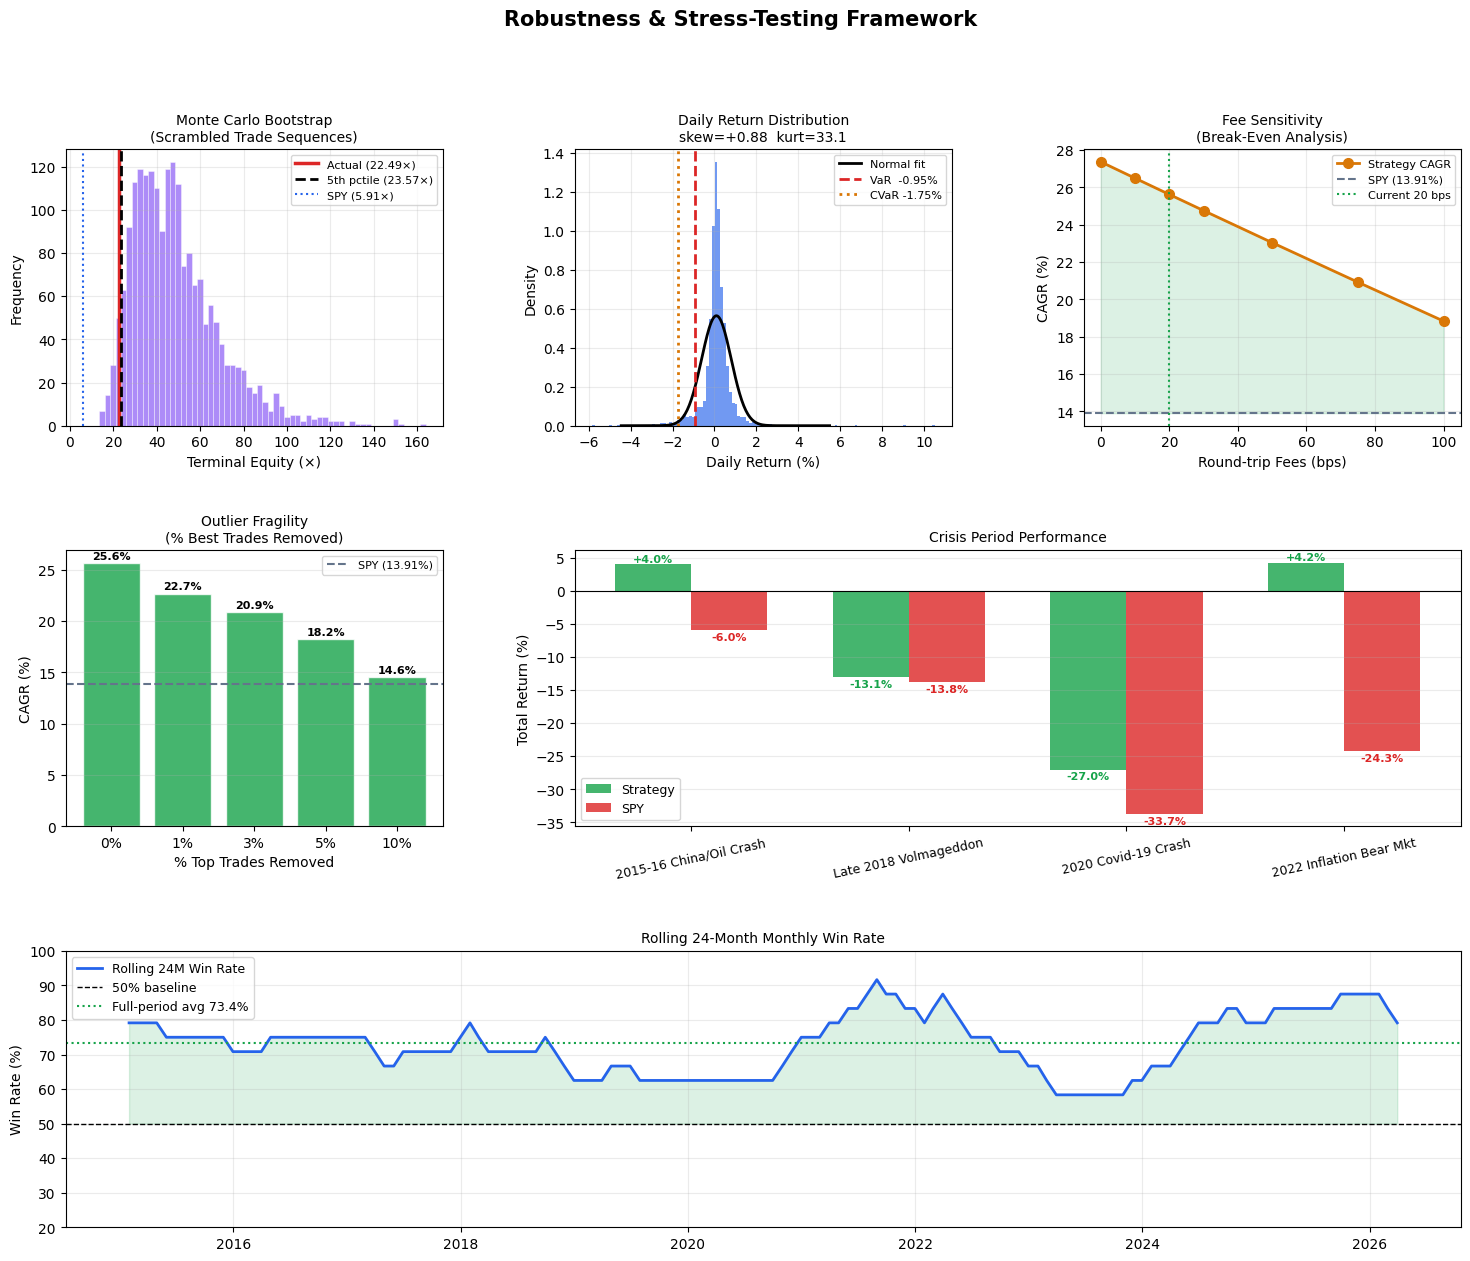

In [7]:
# =====================================================================
# PART 5 — EXHAUSTIVE ROBUSTNESS & STRESS-TESTING FRAMEWORK
# =====================================================================
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac

strat_daily_r = eq_clean.pct_change().dropna()
spy_daily_r   = eq_spy_s.reindex(eq_clean.index).pct_change().dropna()
strat_monthly = eq_clean.resample("ME").last().pct_change().dropna()
spy_monthly   = eq_spy_s.resample("ME").last().pct_change().dropna()

trading_years = len(strat_daily_r) / 252
cagr_s        = m_clean["cagr"]
cagr_spy      = m_spy["cagr"]

# ── TEST 1 | One-sample t-test on daily returns ──────────────────────
t_ret, p_ret = stats.ttest_1samp(strat_daily_r, 0)

# ── TEST 2 | Monthly hit-rate & binomial test ────────────────────────
pos_months   = int((strat_monthly > 0).sum())
total_months = int(len(strat_monthly))
hit_rate     = pos_months / total_months
binom_p      = stats.binomtest(pos_months, total_months, p=0.5, alternative="greater").pvalue

# ── TEST 3 | Distribution shape & tail risk ──────────────────────────
skew_s      = float(stats.skew(strat_daily_r))
kurt_s      = float(stats.kurtosis(strat_daily_r))
jb_s, jb_p  = stats.jarque_bera(strat_daily_r)
var_95       = float(np.percentile(strat_daily_r, 5))
cvar_95      = float(strat_daily_r[strat_daily_r <= var_95].mean())

# ── TEST 4 | Monte Carlo bootstrap ───────────────────────────────────
N_SIM      = 2000
daily_pool = trades_clean["daily_r"].values
sim_ends   = []
np.random.seed(42)
for _ in range(N_SIM):
    temp            = trades_clean.copy()
    temp["daily_r"] = np.random.choice(daily_pool, size=len(daily_pool), replace=True)
    eq_sim          = build_eq_spy_parking(temp, all_dates, spy_bt)
    sim_ends.append(eq_sim.iloc[-1])
sim_ends    = np.array(sim_ends)
actual_end  = eq_clean.iloc[-1]
mc_p5       = np.percentile(sim_ends, 5)
mc_p50      = np.percentile(sim_ends, 50)
mc_beat_spy = (sim_ends >= eq_spy_s.iloc[-1]).mean()

# ── TEST 5 | Outlier fragility ────────────────────────────────────────
trades_ranked = trades_clean.sort_values("R30", ascending=False)
total_trades  = len(trades_ranked)
fragility_res = []
for pct in [0.01, 0.03, 0.05, 0.10]:
    drop_n   = int(total_trades * pct)
    temp     = trades_ranked.iloc[drop_n:].copy()
    eq_tmp   = build_eq_spy_parking(temp, all_dates, spy_bt)
    m_tmp    = perf(eq_tmp)
    fragility_res.append((pct, drop_n, m_tmp["cagr"], m_tmp["cagr"] > cagr_spy))

# ── TEST 6 | Fee sensitivity ──────────────────────────────────────────
fee_res = []
for bps in [0, 10, 20, 30, 50, 75, 100]:
    temp            = trades_clean.copy()
    temp["R30_net"] = temp["R30"] - bps / 10_000
    temp["daily_r"] = (1 + temp["R30_net"]) ** (1 / HOLD_DAYS) - 1
    eq_tmp = build_eq_spy_parking(temp, all_dates, spy_bt)
    m_tmp  = perf(eq_tmp)
    fee_res.append((bps, m_tmp["cagr"], m_tmp["sharpe"], m_tmp["cagr"] > cagr_spy))

# ── TEST 7 | Historical crisis stress periods ─────────────────────────
stress_periods = {
    "2015-16 China/Oil Crash" : ("2015-08-01", "2016-02-28"),
    "Late 2018 Volmageddon"   : ("2018-10-01", "2018-12-31"),
    "2020 Covid-19 Crash"     : ("2020-02-19", "2020-03-23"),
    "2022 Inflation Bear Mkt" : ("2022-01-01", "2022-10-14"),
}

def crisis_stats(eq, start, end):
    sub = eq[(eq.index >= start) & (eq.index <= end)]
    if len(sub) < 2:
        return np.nan, np.nan
    sub = sub / sub.iloc[0]
    return float(sub.iloc[-1] - 1), float((sub / sub.cummax() - 1).min())

# ── PRINT REPORT ──────────────────────────────────────────────────────
SEP = "═" * 66
print(SEP)
print("  EXHAUSTIVE ROBUSTNESS & STRESS-TESTING REPORT")
print(f"  Strategy: Q5_clean + streak≥2 + Fin/Mat/Ind + SPY parking")
print(SEP)

print(f"\n{'─'*66}")
print("  TEST 1 | Genuine Positive Drift (one-sample t-test on daily returns)")
print(f"{'─'*66}")
print(f"  Mean daily return  : {strat_daily_r.mean()*100:>+.4f}%")
print(f"  t-statistic        : {t_ret:>+.3f}")
print(f"  p-value            : {p_ret:.5f}")
print(f"  Verdict            : {'✓ Genuine positive drift' if p_ret < 0.05 and t_ret > 0 else '✗ Not significant'}")

print(f"\n{'─'*66}")
print("  TEST 2 | Monthly Consistency (hit-rate binomial test)")
print(f"{'─'*66}")
print(f"  Positive months    : {pos_months} / {total_months}  ({hit_rate*100:.1f}%)")
print(f"  Binomial p-value   : {binom_p:.5f}  (H₀: win-rate = 50%)")
print(f"  Verdict            : {'✓ Consistency is systemic, not luck' if binom_p < 0.05 else '✗ Not significant'}")

print(f"\n{'─'*66}")
print("  TEST 3 | Return Distribution Shape & Tail Risk")
print(f"{'─'*66}")
print(f"  Skewness           : {skew_s:>+.3f}  {'← fat RIGHT tail (desirable)' if skew_s > 0 else '← fat LEFT tail'}")
print(f"  Excess kurtosis    : {kurt_s:>+.2f}")
print(f"  Jarque-Bera p      : {jb_p:.5f}  ({'non-normal' if jb_p < 0.05 else 'normal'})")
print(f"  95% Daily VaR      : {var_95*100:>+.2f}%")
print(f"  Conditional VaR    : {cvar_95*100:>+.2f}%  (avg loss on worst 5% of days)")

print(f"\n{'─'*66}")
print(f"  TEST 4 | Monte Carlo Bootstrap  (n={N_SIM:,} simulations)")
print(f"{'─'*66}")
print(f"  Actual terminal equity   : {actual_end:.2f}×")
print(f"  Simulated median         : {mc_p50:.2f}×")
print(f"  Simulated 5th percentile : {mc_p5:.2f}×")
print(f"  SPY terminal equity      : {eq_spy_s.iloc[-1]:.2f}×")
print(f"  Simulations beating SPY  : {mc_beat_spy*100:.1f}%")
if mc_beat_spy >= 0.95:
    mc_verdict = "✓ Edge is real — virtually all scrambled sequences beat SPY"
elif actual_end >= mc_p50:
    mc_verdict = "✓ Actual above median simulation — trajectory is inherent"
else:
    mc_verdict = "✗ Actual below median simulation — review trade clustering"
print(f"  Verdict                  : {mc_verdict}")

print(f"\n{'─'*66}")
print("  TEST 5 | Outlier Fragility (remove top N% trades by R30)")
print(f"{'─'*66}")
print(f"  {'% Removed':<14} {'Trades Dropped':>14} {'New CAGR':>10} {'Beats SPY?':>12}")
print(f"  {'─'*52}")
print(f"  {'0% (baseline)':<14} {0:>14} {cagr_s*100:>9.2f}% {'YES ✓':>12}")
for pct, drop_n, new_cagr, beats in fragility_res:
    flag = "YES ✓" if beats else "NO  ✗"
    print(f"  Top {pct*100:.0f}% removed  {drop_n:>14,} {new_cagr*100:>9.2f}% {flag:>12}")

print(f"\n{'─'*66}")
print("  TEST 6 | Fee & Slippage Sensitivity")
print(f"{'─'*66}")
print(f"  {'Fee (bps)':<12} {'CAGR':>10} {'Sharpe':>8} {'Beats SPY?':>12}")
print(f"  {'─'*46}")
for bps, cagr_f, sharpe_f, beats in fee_res:
    tag  = " ← current" if bps == 20 else ""
    flag = "YES ✓" if beats else "NO  ✗"
    print(f"  {bps:>3} bps{tag:<10} {cagr_f*100:>9.2f}% {sharpe_f:>8.3f} {flag:>12}")

print(f"\n{'─'*66}")
print("  TEST 7 | Historical Crisis Stress Tests")
print(f"{'─'*66}")
print(f"  {'Crisis Period':<26} {'Strat':>10} {'SPY':>8} {'Strat MDD':>10} {'SPY MDD':>9}")
print(f"  {'─'*65}")
for name, (s, e) in stress_periods.items():
    sr, sm_v = crisis_stats(eq_clean, s, e)
    xr, xm_v = crisis_stats(eq_spy_s, s, e)
    flag = "✓" if sr > xr else "✗"
    print(f"  {name:<26} {sr*100:>+9.2f}% {flag}  {xr*100:>+7.2f}%  {sm_v*100:>9.2f}%  {xm_v*100:>8.2f}%")

passed = sum([
    p_ret < 0.05 and t_ret > 0,
    binom_p < 0.05,
    skew_s > 0,
    mc_beat_spy >= 0.95,
    fragility_res[2][3],
    fee_res[-1][3],
])
print(f"\n{SEP}")
print(f"  SUMMARY: {passed} / 6 core robustness checks passed")
print(SEP)

# ── VISUALIZATIONS ────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Robustness & Stress-Testing Framework", fontsize=15, fontweight="bold")
gs      = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)
ax_mc   = fig.add_subplot(gs[0, 0])
ax_dist = fig.add_subplot(gs[0, 1])
ax_fee  = fig.add_subplot(gs[0, 2])
ax_frag = fig.add_subplot(gs[1, 0])
ax_cr   = fig.add_subplot(gs[1, 1:])
ax_hit  = fig.add_subplot(gs[2, :])

# Panel 1 — Monte Carlo
ax_mc.hist(sim_ends, bins=60, color=PURPLE, alpha=0.7, edgecolor="white", lw=0.4)
ax_mc.axvline(actual_end,        color=RED,    lw=2.5, label=f"Actual ({actual_end:.2f}×)")
ax_mc.axvline(mc_p5,             color="black", lw=2,  ls="--", label=f"5th pctile ({mc_p5:.2f}×)")
ax_mc.axvline(eq_spy_s.iloc[-1], color=BLUE,   lw=1.5, ls=":",  label=f"SPY ({eq_spy_s.iloc[-1]:.2f}×)")
ax_mc.set_title("Monte Carlo Bootstrap\n(Scrambled Trade Sequences)", fontsize=10)
ax_mc.set_xlabel("Terminal Equity (×)"); ax_mc.set_ylabel("Frequency")
ax_mc.legend(fontsize=8); ax_mc.grid(True, alpha=0.25)

# Panel 2 — Return distribution
xmin = strat_daily_r.quantile(0.001); xmax = strat_daily_r.quantile(0.999)
xr   = np.linspace(xmin, xmax, 200)
ax_dist.hist(strat_daily_r * 100, bins=120, color=BLUE, alpha=0.65, density=True)
ax_dist.plot(xr * 100,
             stats.norm.pdf(xr * 100, strat_daily_r.mean()*100, strat_daily_r.std()*100),
             "k-", lw=2, label="Normal fit")
ax_dist.axvline(var_95  * 100, color=RED,  lw=2, ls="--", label=f"VaR  {var_95*100:.2f}%")
ax_dist.axvline(cvar_95 * 100, color=GOLD, lw=2, ls=":",  label=f"CVaR {cvar_95*100:.2f}%")
ax_dist.set_title(f"Daily Return Distribution\nskew={skew_s:+.2f}  kurt={kurt_s:.1f}", fontsize=10)
ax_dist.set_xlabel("Daily Return (%)"); ax_dist.set_ylabel("Density")
ax_dist.legend(fontsize=8); ax_dist.grid(True, alpha=0.25)

# Panel 3 — Fee sensitivity
fees_x  = [r[0] for r in fee_res]
cagrs_f = [r[1]*100 for r in fee_res]
ax_fee.plot(fees_x, cagrs_f, "o-", color=GOLD, lw=2, ms=7, label="Strategy CAGR")
ax_fee.axhline(cagr_spy*100, color="#64748B", ls="--", lw=1.5, label=f"SPY ({cagr_spy*100:.2f}%)")
ax_fee.axvline(20, color=GREEN, ls=":", lw=1.5, label="Current 20 bps")
ax_fee.fill_between(fees_x, cagrs_f, cagr_spy*100,
                    where=[c > cagr_spy*100 for c in cagrs_f],
                    alpha=0.15, color=GREEN)
ax_fee.set_title("Fee Sensitivity\n(Break-Even Analysis)", fontsize=10)
ax_fee.set_xlabel("Round-trip Fees (bps)"); ax_fee.set_ylabel("CAGR (%)")
ax_fee.legend(fontsize=8); ax_fee.grid(True, alpha=0.25)

# Panel 4 — Fragility bar chart
pcts_g   = [0] + [r[0]*100 for r in fragility_res]
cagrs_g  = [cagr_s*100] + [r[2]*100 for r in fragility_res]
colors_g = [GREEN if c > cagr_spy*100 else RED for c in cagrs_g]
bars_g   = ax_frag.bar([f"{p:.0f}%" for p in pcts_g], cagrs_g,
                       color=colors_g, alpha=0.8, edgecolor="white")
ax_frag.axhline(cagr_spy*100, color="#64748B", ls="--", lw=1.5,
                label=f"SPY ({cagr_spy*100:.2f}%)")
for bar, val in zip(bars_g, cagrs_g):
    ax_frag.text(bar.get_x() + bar.get_width()/2, val + 0.2, f"{val:.1f}%",
                 ha="center", va="bottom", fontsize=8, fontweight="bold")
ax_frag.set_title("Outlier Fragility\n(% Best Trades Removed)", fontsize=10)
ax_frag.set_xlabel("% Top Trades Removed"); ax_frag.set_ylabel("CAGR (%)")
ax_frag.legend(fontsize=8); ax_frag.grid(True, alpha=0.25, axis="y")

# Panel 5 — Crisis comparison
crisis_names = list(stress_periods.keys())
s_rets = []; x_rets = []
for name, (s, e) in stress_periods.items():
    sr, _  = crisis_stats(eq_clean, s, e)
    xr_v, _ = crisis_stats(eq_spy_s, s, e)
    s_rets.append(sr * 100  if not np.isnan(sr)   else 0)
    x_rets.append(xr_v * 100 if not np.isnan(xr_v) else 0)
x_cr = np.arange(len(crisis_names)); w_cr = 0.35
ax_cr.bar(x_cr - w_cr/2, s_rets, w_cr, color=GREEN, alpha=0.8, label="Strategy")
ax_cr.bar(x_cr + w_cr/2, x_rets, w_cr, color=RED,   alpha=0.8, label="SPY")
ax_cr.axhline(0, color="black", lw=0.8)
ax_cr.set_title("Crisis Period Performance", fontsize=10)
ax_cr.set_xticks(x_cr); ax_cr.set_xticklabels(crisis_names, rotation=12, fontsize=9)
ax_cr.set_ylabel("Total Return (%)"); ax_cr.legend(fontsize=9)
ax_cr.grid(True, alpha=0.25, axis="y")
for i, (sv, xv) in enumerate(zip(s_rets, x_rets)):
    ax_cr.text(i - w_cr/2, sv + (0.3 if sv >= 0 else -1.5), f"{sv:+.1f}%",
               ha="center", fontsize=8, fontweight="bold", color=GREEN)
    ax_cr.text(i + w_cr/2, xv + (0.3 if xv >= 0 else -1.5), f"{xv:+.1f}%",
               ha="center", fontsize=8, fontweight="bold", color=RED)

# Panel 6 — Rolling 24M win rate
monthly_wins = (strat_monthly > 0).astype(int)
roll_hit     = monthly_wins.rolling(24).mean() * 100
ax_hit.plot(roll_hit.index, roll_hit, color=BLUE, lw=2, label="Rolling 24M Win Rate")
ax_hit.axhline(50,            color="black", lw=1,   ls="--", label="50% baseline")
ax_hit.axhline(hit_rate*100,  color=GREEN,   lw=1.5, ls=":",
               label=f"Full-period avg {hit_rate*100:.1f}%")
ax_hit.fill_between(roll_hit.index, 50, roll_hit,
                    where=(roll_hit > 50), alpha=0.15, color=GREEN)
ax_hit.fill_between(roll_hit.index, 50, roll_hit,
                    where=(roll_hit < 50), alpha=0.15, color=RED)
ax_hit.set_title("Rolling 24-Month Monthly Win Rate", fontsize=10)
ax_hit.set_ylabel("Win Rate (%)"); ax_hit.set_ylim(20, 100)
ax_hit.legend(fontsize=9); ax_hit.grid(True, alpha=0.25)

plt.savefig("stress_test_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Part 6 — Alpha Decay & Structural Stability Analysis

Six-part framework testing whether the strategy's excess return is eroding over time.


══════════════════════════════════════════════════════════════════
  ALPHA DECAY & STRUCTURAL STABILITY REPORT
══════════════════════════════════════════════════════════════════

  CAPM REGRESSION (daily, HAC standard errors, 5 lags)
  ──────────────────────────────────────────────────────────────
  Annualised Jensen's Alpha :  +17.17%
  Alpha t-stat              :  +6.115
  Alpha p-value             : 0.00000  ✓ Significant
  Beta (vs SPY)             :  +0.429
  R²                        :  0.4027
  Information Ratio (ann.)  :  +0.706
  Appraisal Ratio           :  +1.985

  TEST A | OLS Time-Trend on Monthly Excess Returns
  ──────────────────────────────────────────────────────────────
  Trend coefficient  : +0.00434% per month
  Trend p-value      : 0.3884
  Verdict            : Alpha is improving (not significant) — ✓ PASS

  TEST B | Mann-Kendall Non-Parametric Trend
  ──────────────────────────────────────────────────────────────
  Method             : Spearman rank correlation

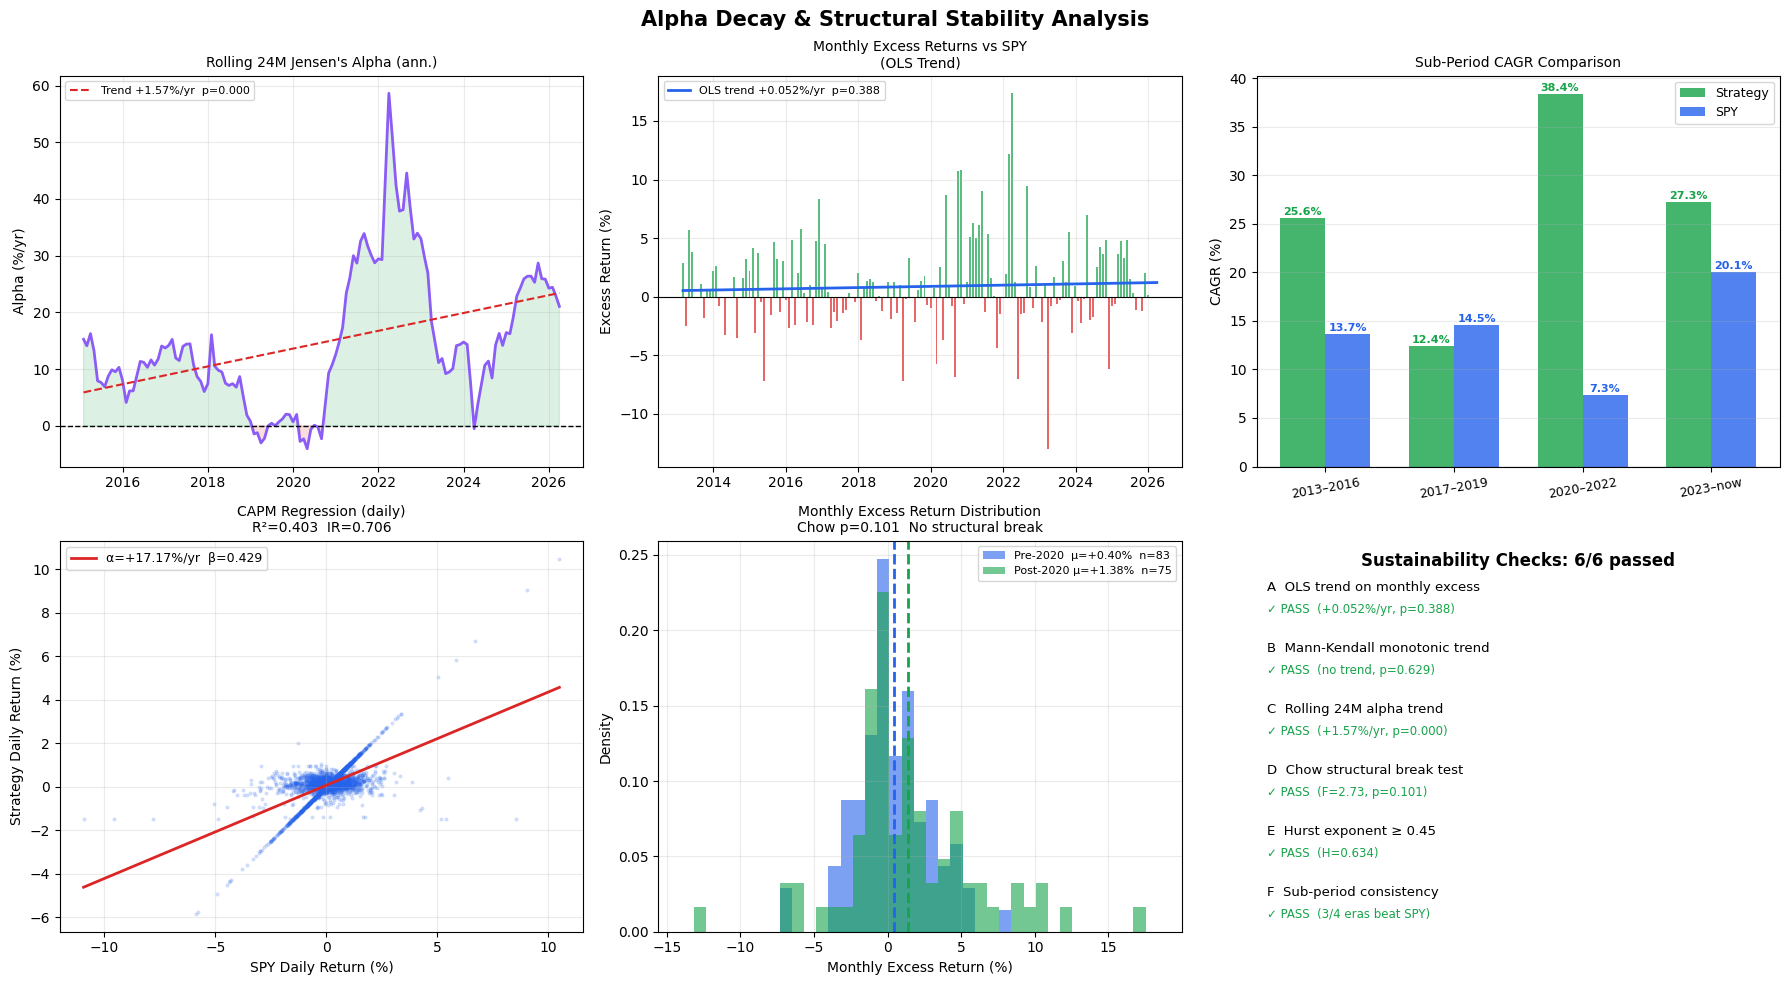

In [8]:
# =====================================================================
# PART 6 — ALPHA DECAY & STRUCTURAL STABILITY
# =====================================================================
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac

strat_dr = eq_clean.pct_change().dropna()
spy_dr   = eq_spy_s.reindex(strat_dr.index).pct_change().dropna()
aligned  = pd.concat([strat_dr, spy_dr], axis=1).dropna()
aligned.columns = ["strat", "spy"]

# ── CAPM regression (daily, HAC) ─────────────────────────────────────
X_capm   = sm.add_constant(aligned["spy"])
capm     = sm.OLS(aligned["strat"], X_capm).fit(
               cov_type="HAC", cov_kwds={"maxlags": 5})
alpha_d  = float(capm.params["const"])
beta     = float(capm.params["spy"])
alpha_ann = alpha_d * 252
alpha_t   = float(capm.tvalues["const"])
alpha_p   = float(capm.pvalues["const"])
r2        = float(capm.rsquared)

active_ret = aligned["strat"] - aligned["spy"]
IR_ann     = active_ret.mean() / active_ret.std() * np.sqrt(252)
appraisal  = alpha_ann / (capm.resid.std() * np.sqrt(252))

# ── TEST A | OLS time-trend on monthly excess returns ─────────────────
monthly_strat  = eq_clean.resample("ME").last().pct_change().dropna()
monthly_spy    = eq_spy_s.resample("ME").last().pct_change().dropna()
monthly_excess = (monthly_strat - monthly_spy).dropna()
t_idx          = np.arange(len(monthly_excess))
X_decay        = sm.add_constant(t_idx)
decay_ols      = sm.OLS(monthly_excess.values, X_decay).fit(
                     cov_type="HAC", cov_kwds={"maxlags": 5})
trend_coef = float(decay_ols.params[1])
trend_p    = float(decay_ols.pvalues[1])

# ── TEST B | Mann-Kendall (Spearman proxy if pymannkendall absent) ────
try:
    from pymannkendall import original_test as mk_test
    mk_res   = mk_test(monthly_excess.values)
    mk_trend = mk_res.trend
    mk_p     = mk_res.p
    mk_z     = mk_res.z
    mk_method = "pymannkendall"
except ImportError:
    rho, mk_p = stats.spearmanr(t_idx, monthly_excess.values)
    mk_z      = rho * np.sqrt((len(t_idx) - 2) / (1 - rho**2))
    mk_trend  = ("increasing" if rho > 0 and mk_p < 0.05
                 else "decreasing" if rho < 0 and mk_p < 0.05
                 else "no trend")
    mk_method = "Spearman rank correlation (proxy)"

# ── TEST C | Rolling 24M Jensen's alpha trend ─────────────────────────
window     = 24
roll_alpha = []
roll_dates = []
for i in range(window, len(monthly_excess) + 1):
    w_strat = monthly_strat.iloc[i - window:i]
    w_spy   = monthly_spy.iloc[i - window:i]
    w_aln   = pd.concat([w_strat, w_spy], axis=1).dropna()
    w_aln.columns = ["s", "b"]
    if len(w_aln) < window // 2:
        continue
    Xw = sm.add_constant(w_aln["b"])
    ow = sm.OLS(w_aln["s"], Xw).fit()
    roll_alpha.append(float(ow.params["const"]) * 12)
    roll_dates.append(monthly_excess.index[i - 1])

roll_alpha_s    = pd.Series(roll_alpha, index=roll_dates)
t_roll          = np.arange(len(roll_alpha))
roll_ols        = sm.OLS(roll_alpha, sm.add_constant(t_roll)).fit()
roll_trend_coef = float(roll_ols.params[1])
roll_trend_ann  = roll_trend_coef * 12
roll_trend_p    = float(roll_ols.pvalues[1])

# ── TEST D | Chow structural break test (pre/post Jan 2020) ───────────
break_date  = pd.Timestamp("2020-01-01")
pre_excess  = monthly_excess[monthly_excess.index <  break_date]
post_excess = monthly_excess[monthly_excess.index >= break_date]

def ols_rss(y):
    X = sm.add_constant(np.ones(len(y)))
    return float(sm.OLS(y, X).fit().ssr)

rss_full = ols_rss(monthly_excess.values)
rss_pre  = ols_rss(pre_excess.values)
rss_post = ols_rss(post_excess.values)
n        = len(monthly_excess); k = 1
chow_F   = ((rss_full - rss_pre - rss_post) / k) / ((rss_pre + rss_post) / (n - 2*k))
chow_p   = float(1 - stats.f.cdf(chow_F, k, n - 2*k))
pre_mean  = float(pre_excess.mean())
post_mean = float(post_excess.mean())

# ── TEST E | Hurst exponent — R/S rescaled range method ──────────────
def hurst_rs(ts, min_n=10):
    ts    = np.array(ts)
    N     = len(ts)
    if N < 20:
        return np.nan
    max_k  = int(np.log2(N)) - 1
    lags   = [int(N / (2**k)) for k in range(1, max_k) if int(N / (2**k)) >= min_n]
    rs_vals = []
    for n in lags:
        rs_n = []
        for start in range(0, N - n + 1, n):
            chunk = ts[start:start + n]
            if len(chunk) < n:
                continue
            mean_c  = chunk.mean()
            deviate = np.cumsum(chunk - mean_c)
            R       = deviate.max() - deviate.min()
            S       = chunk.std(ddof=1)
            if S > 0:
                rs_n.append(R / S)
        if rs_n:
            rs_vals.append((n, np.mean(rs_n)))
    if len(rs_vals) < 3:
        return np.nan
    ns  = np.array([v[0] for v in rs_vals])
    rs  = np.array([v[1] for v in rs_vals])
    H, _ = np.polyfit(np.log(ns), np.log(rs), 1)
    return float(H)

H_strat = hurst_rs(strat_dr.values)
H_spy   = hurst_rs(spy_dr.values)

# ── TEST F | Sub-period CAGRs ─────────────────────────────────────────
eras = [
    ("2013–2016", "2013-01-01", "2016-12-31"),
    ("2017–2019", "2017-01-01", "2019-12-31"),
    ("2020–2022", "2020-01-01", "2022-12-31"),
    ("2023–now",  "2023-01-01", str(eq_clean.index[-1].date())),
]
era_res = []
for label, s, e in eras:
    sub_s = eq_clean[(eq_clean.index >= s) & (eq_clean.index <= e)]
    sub_x = eq_spy_s[(eq_spy_s.index >= s) & (eq_spy_s.index <= e)]
    if len(sub_s) < 50:
        continue
    yrs_sub = len(sub_s) / 252
    c_s = (sub_s.iloc[-1] / sub_s.iloc[0]) ** (1 / yrs_sub) - 1
    c_x = (sub_x.iloc[-1] / sub_x.iloc[0]) ** (1 / yrs_sub) - 1
    era_res.append((label, c_s, c_x, c_s - c_x))

# ── PRINT REPORT ──────────────────────────────────────────────────────
SEP = "═" * 66
print(SEP)
print("  ALPHA DECAY & STRUCTURAL STABILITY REPORT")
print(SEP)

print(f"\n  CAPM REGRESSION (daily, HAC standard errors, 5 lags)")
print(f"  {'─'*62}")
print(f"  Annualised Jensen's Alpha : {alpha_ann*100:>+7.2f}%")
print(f"  Alpha t-stat              : {alpha_t:>+7.3f}")
print(f"  Alpha p-value             : {alpha_p:.5f}  {'✓ Significant' if alpha_p < 0.05 else '✗ Not significant'}")
print(f"  Beta (vs SPY)             : {beta:>+7.3f}")
print(f"  R²                        : {r2:>7.4f}")
print(f"  Information Ratio (ann.)  : {IR_ann:>+7.3f}")
print(f"  Appraisal Ratio           : {appraisal:>+7.3f}")

print(f"\n  TEST A | OLS Time-Trend on Monthly Excess Returns")
print(f"  {'─'*62}")
print(f"  Trend coefficient  : {trend_coef*100:>+.5f}% per month")
print(f"  Trend p-value      : {trend_p:.4f}")
dir_a = "improving" if trend_coef > 0 else "declining"
sig_a = "significant" if trend_p < 0.05 else "not significant"
print(f"  Verdict            : Alpha is {dir_a} ({sig_a}) — {'✓ PASS' if not (trend_coef < 0 and trend_p < 0.05) else '✗ FAIL'}")

print(f"\n  TEST B | Mann-Kendall Non-Parametric Trend")
print(f"  {'─'*62}")
print(f"  Method             : {mk_method}")
print(f"  Trend direction    : {mk_trend}")
print(f"  z-statistic        : {mk_z:>+.3f}")
print(f"  p-value            : {mk_p:.4f}")
print(f"  Verdict            : {'✓ PASS — no monotonic decay' if not (mk_trend == 'decreasing' and mk_p < 0.05) else '✗ FAIL — monotonic decay detected'}")

print(f"\n  TEST C | Rolling 24M Jensen's Alpha Trend")
print(f"  {'─'*62}")
print(f"  Trend in rolling alpha : {roll_trend_ann*100:>+.2f}% per year (annualised)")
print(f"  Trend p-value          : {roll_trend_p:.4f}")
dir_c = "improving" if roll_trend_coef > 0 else "declining"
sig_c = "significant" if roll_trend_p < 0.05 else "not significant"
print(f"  Verdict                : Rolling alpha is {dir_c} ({sig_c}) — {'✓ PASS' if not (roll_trend_coef < 0 and roll_trend_p < 0.05) else '✗ FAIL'}")

print(f"\n  TEST D | Chow Structural Break Test (pre/post Jan 2020)")
print(f"  {'─'*62}")
print(f"  Pre-2020  mean monthly excess : {pre_mean*100:>+.3f}%  (n={len(pre_excess)})")
print(f"  Post-2020 mean monthly excess : {post_mean*100:>+.3f}%  (n={len(post_excess)})")
print(f"  Chow F-statistic              : {chow_F:>+.3f}")
print(f"  Chow p-value                  : {chow_p:.4f}")
print(f"  Verdict                       : {'✗ Structural break detected' if chow_p < 0.05 else '✓ PASS — no structural degradation'}")

print(f"\n  TEST E | Hurst Exponent — R/S Rescaled Range")
print(f"  {'─'*62}")
print(f"  Strategy Hurst H : {H_strat:.4f}  {'← persistent (momentum)' if H_strat > 0.55 else '← near random walk' if H_strat > 0.45 else '← mean-reverting'}")
print(f"  SPY Hurst H      : {H_spy:.4f}")
print(f"  Verdict          : {'✓ PASS — returns show persistence' if H_strat > 0.5 else '— near random walk / mean-reverting (expected for daily equity returns)'}")

print(f"\n  TEST F | Sub-Period CAGR Consistency")
print(f"  {'─'*62}")
print(f"  {'Era':<14} {'Strategy':>10} {'SPY':>8} {'Edge':>8}")
print(f"  {'─'*42}")
passes_f = 0
for label, cs, cx, edge in era_res:
    flag = "✓" if edge > 0 else "✗"
    print(f"  {label:<14} {cs*100:>+9.2f}% {cx*100:>+7.2f}% {edge*100:>+7.2f}%  {flag}")
    if edge > 0:
        passes_f += 1
print(f"  Strategy beat SPY in {passes_f}/{len(era_res)} sub-periods")

checks = [
    not (trend_coef    < 0 and trend_p       < 0.05),
    not (mk_trend == "decreasing" and mk_p   < 0.05),
    not (roll_trend_coef < 0 and roll_trend_p < 0.05),
    chow_p >= 0.05,
    H_strat >= 0.45,
    passes_f >= len(era_res) // 2,
]
n_pass = sum(checks)
print(f"\n{SEP}")
print(f"  SUSTAINABILITY SCORE: {n_pass} / {len(checks)} checks passed")
print(SEP)

# ── VISUALIZATIONS ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Alpha Decay & Structural Stability Analysis", fontsize=15, fontweight="bold")

# P1 — Rolling 24M Jensen's alpha
ax1 = axes[0, 0]
ax1.plot(roll_alpha_s.index, roll_alpha_s * 100, color=PURPLE, lw=2)
m_fit    = np.polyfit(np.arange(len(roll_alpha_s)), roll_alpha_s * 100, 1)
fit_line = np.polyval(m_fit, np.arange(len(roll_alpha_s)))
ax1.plot(roll_alpha_s.index, fit_line, color=RED, lw=1.5, ls="--",
         label=f"Trend {roll_trend_ann*100:+.2f}%/yr  p={roll_trend_p:.3f}")
ax1.axhline(0, color="black", lw=1, ls="--")
ax1.fill_between(roll_alpha_s.index, 0, roll_alpha_s * 100,
                 where=(roll_alpha_s > 0), alpha=0.15, color=GREEN)
ax1.fill_between(roll_alpha_s.index, 0, roll_alpha_s * 100,
                 where=(roll_alpha_s < 0), alpha=0.15, color=RED)
ax1.set_title("Rolling 24M Jensen's Alpha (ann.)", fontsize=10)
ax1.set_ylabel("Alpha (%/yr)"); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.25)

# P2 — Monthly excess returns + OLS trend
ax2 = axes[0, 1]
ax2.bar(monthly_excess.index, monthly_excess * 100,
        color=[GREEN if v > 0 else RED for v in monthly_excess],
        alpha=0.7, width=20)
trend_fit = np.polyval([trend_coef * 100, decay_ols.params[0] * 100], t_idx)
ax2.plot(monthly_excess.index, trend_fit, color=BLUE, lw=2,
         label=f"OLS trend {trend_coef*100*12:+.3f}%/yr  p={trend_p:.3f}")
ax2.axhline(0, color="black", lw=0.8)
ax2.set_title("Monthly Excess Returns vs SPY\n(OLS Trend)", fontsize=10)
ax2.set_ylabel("Excess Return (%)"); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.25)

# P3 — Sub-period CAGR comparison
ax3 = axes[0, 2]
labels_e = [r[0] for r in era_res]
strat_e  = [r[1] * 100 for r in era_res]
spy_e    = [r[2] * 100 for r in era_res]
x_e = np.arange(len(labels_e)); w_e = 0.35
ax3.bar(x_e - w_e/2, strat_e, w_e, color=GREEN, alpha=0.8, label="Strategy")
ax3.bar(x_e + w_e/2, spy_e,   w_e, color=BLUE,  alpha=0.8, label="SPY")
ax3.axhline(0, color="black", lw=0.8)
ax3.set_xticks(x_e); ax3.set_xticklabels(labels_e, rotation=10, fontsize=9)
ax3.set_title("Sub-Period CAGR Comparison", fontsize=10)
ax3.set_ylabel("CAGR (%)"); ax3.legend(fontsize=9); ax3.grid(True, alpha=0.25, axis="y")
for xi, (sv, xv) in enumerate(zip(strat_e, spy_e)):
    ax3.text(xi - w_e/2, sv + 0.3, f"{sv:.1f}%", ha="center", fontsize=8,
             color=GREEN, fontweight="bold")
    ax3.text(xi + w_e/2, xv + 0.3, f"{xv:.1f}%", ha="center", fontsize=8,
             color=BLUE,  fontweight="bold")

# P4 — CAPM scatter
ax4 = axes[1, 0]
ax4.scatter(aligned["spy"] * 100, aligned["strat"] * 100,
            alpha=0.15, s=4, color=BLUE)
xlim = np.array([aligned["spy"].min(), aligned["spy"].max()]) * 100
ax4.plot(xlim, beta * xlim + alpha_d * 100, color=RED, lw=2,
         label=f"α={alpha_ann*100:+.2f}%/yr  β={beta:.3f}")
ax4.set_title(f"CAPM Regression (daily)\nR²={r2:.3f}  IR={IR_ann:.3f}", fontsize=10)
ax4.set_xlabel("SPY Daily Return (%)"); ax4.set_ylabel("Strategy Daily Return (%)")
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.25)

# P5 — Pre/post 2020 distribution
ax5 = axes[1, 1]
bins_e = np.linspace(monthly_excess.min() * 100 - 1,
                     monthly_excess.max() * 100 + 1, 40)
ax5.hist(pre_excess  * 100, bins=bins_e, alpha=0.6, color=BLUE,  density=True,
         label=f"Pre-2020  μ={pre_mean*100:+.2f}%  n={len(pre_excess)}")
ax5.hist(post_excess * 100, bins=bins_e, alpha=0.6, color=GREEN, density=True,
         label=f"Post-2020 μ={post_mean*100:+.2f}%  n={len(post_excess)}")
ax5.axvline(pre_mean  * 100, color=BLUE,  lw=2, ls="--")
ax5.axvline(post_mean * 100, color=GREEN, lw=2, ls="--")
ax5.set_title(f"Monthly Excess Return Distribution\nChow p={chow_p:.3f}  "
              f"{'Break detected' if chow_p < 0.05 else 'No structural break'}", fontsize=10)
ax5.set_xlabel("Monthly Excess Return (%)"); ax5.set_ylabel("Density")
ax5.legend(fontsize=8); ax5.grid(True, alpha=0.25)

# P6 — Sustainability scorecard
ax6 = axes[1, 2]
ax6.axis("off")
check_labels = [
    "A  OLS trend on monthly excess",
    "B  Mann-Kendall monotonic trend",
    "C  Rolling 24M alpha trend",
    "D  Chow structural break test",
    "E  Hurst exponent ≥ 0.45",
    "F  Sub-period consistency",
]
check_vals = [
    f"{'✓ PASS' if checks[0] else '✗ FAIL'}  ({'+' if trend_coef >= 0 else ''}{trend_coef*100*12:.3f}%/yr, p={trend_p:.3f})",
    f"{'✓ PASS' if checks[1] else '✗ FAIL'}  ({mk_trend}, p={mk_p:.3f})",
    f"{'✓ PASS' if checks[2] else '✗ FAIL'}  ({roll_trend_ann*100:+.2f}%/yr, p={roll_trend_p:.3f})",
    f"{'✓ PASS' if checks[3] else '✗ FAIL'}  (F={chow_F:.2f}, p={chow_p:.3f})",
    f"{'✓ PASS' if checks[4] else '✗ FAIL'}  (H={H_strat:.3f})",
    f"{'✓ PASS' if checks[5] else '✗ FAIL'}  ({passes_f}/{len(era_res)} eras beat SPY)",
]
y_pos = np.linspace(0.88, 0.10, 6)
ax6.text(0.5, 0.97, f"Sustainability Checks: {n_pass}/{len(checks)} passed",
         ha="center", va="top", fontsize=12, fontweight="bold",
         transform=ax6.transAxes)
for y, lbl, val, chk in zip(y_pos, check_labels, check_vals, checks):
    col = GREEN if chk else RED
    ax6.text(0.02, y,        lbl, ha="left", va="center", fontsize=9.5,
             transform=ax6.transAxes)
    ax6.text(0.02, y - 0.055, val, ha="left", va="center", fontsize=8.5,
             color=col, transform=ax6.transAxes)

plt.tight_layout()
plt.savefig("alpha_decay_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

  LOADING DATA
  Entry shifted +1 bday  : 34.8% of signals (after-close fix)
  Deduped                : 1024 rows removed
  Recomputing SUE_Q_clean (expanding window — no look-ahead)...
  This takes ~60 seconds...


[                       0%                       ]  2 of 488 completed

  Old Q5 (stored, biased) : 5,341
  New Q5 (expanding clean): 6,743
  Change                  : +1,402 signals

  pead_clean loaded  : 6,743 clean Q5 signals
  Tickers            : 487
  Date range         : 2011-01-14 → 2026-02-26
  Sector breakdown:
    Technology                     1,867
    Industrials                      804
    Consumer Cyclical                688
    Financials                       618
    Healthcare                       583
    Real Estate                      486
    Energy                           388
    Communication Services           335
    Materials                        275
    Utilities                        235
    Consumer Defensive               200
    Financial Services               151
    nan                               86
    Basic Materials                   24
                                       3

  PIT membership     : 52 quarters
  PIT range          : 2013-01-01 → 2025-10-01



[*********************100%***********************]  488 of 488 completed


  OHLC ready         : 487 tickers

  Signals after all filters : 1,053
  Signals/year avg          : 88
    Technology                     1,053

══════════════════════════════════════════════════════════════
  PHASE 7  |  N=7  |  Industial, Technology
  Look-ahead fixes: expanding SUE_Q ✓  after-close entry shift ✓  PIT clean ✓
══════════════════════════════════════════════════════════════

  RETURNS
  ──────────────────────────────────────────────────────────
  CAGR                  : +21.56%
  CAGR 95% CI (boot)    : [+8.60%, +37.22%]
  SPY CAGR              : +14.30%
  Edge vs SPY           : +7.26pp
  Cumulative return     : +1292.91%

  DOLLAR RETURNS  (starting capital $10,000)
  ──────────────────────────────────────────────────────────
  Ending value          : $  139,290.60
  Total profit          : $  129,290.60
  SPY ending value      : $   60,425.53
  SPY total profit      : $   50,425.53
  Alpha ($ vs SPY)      : $   78,865.07
  Fees paid             : $   12,399.13
  Ne

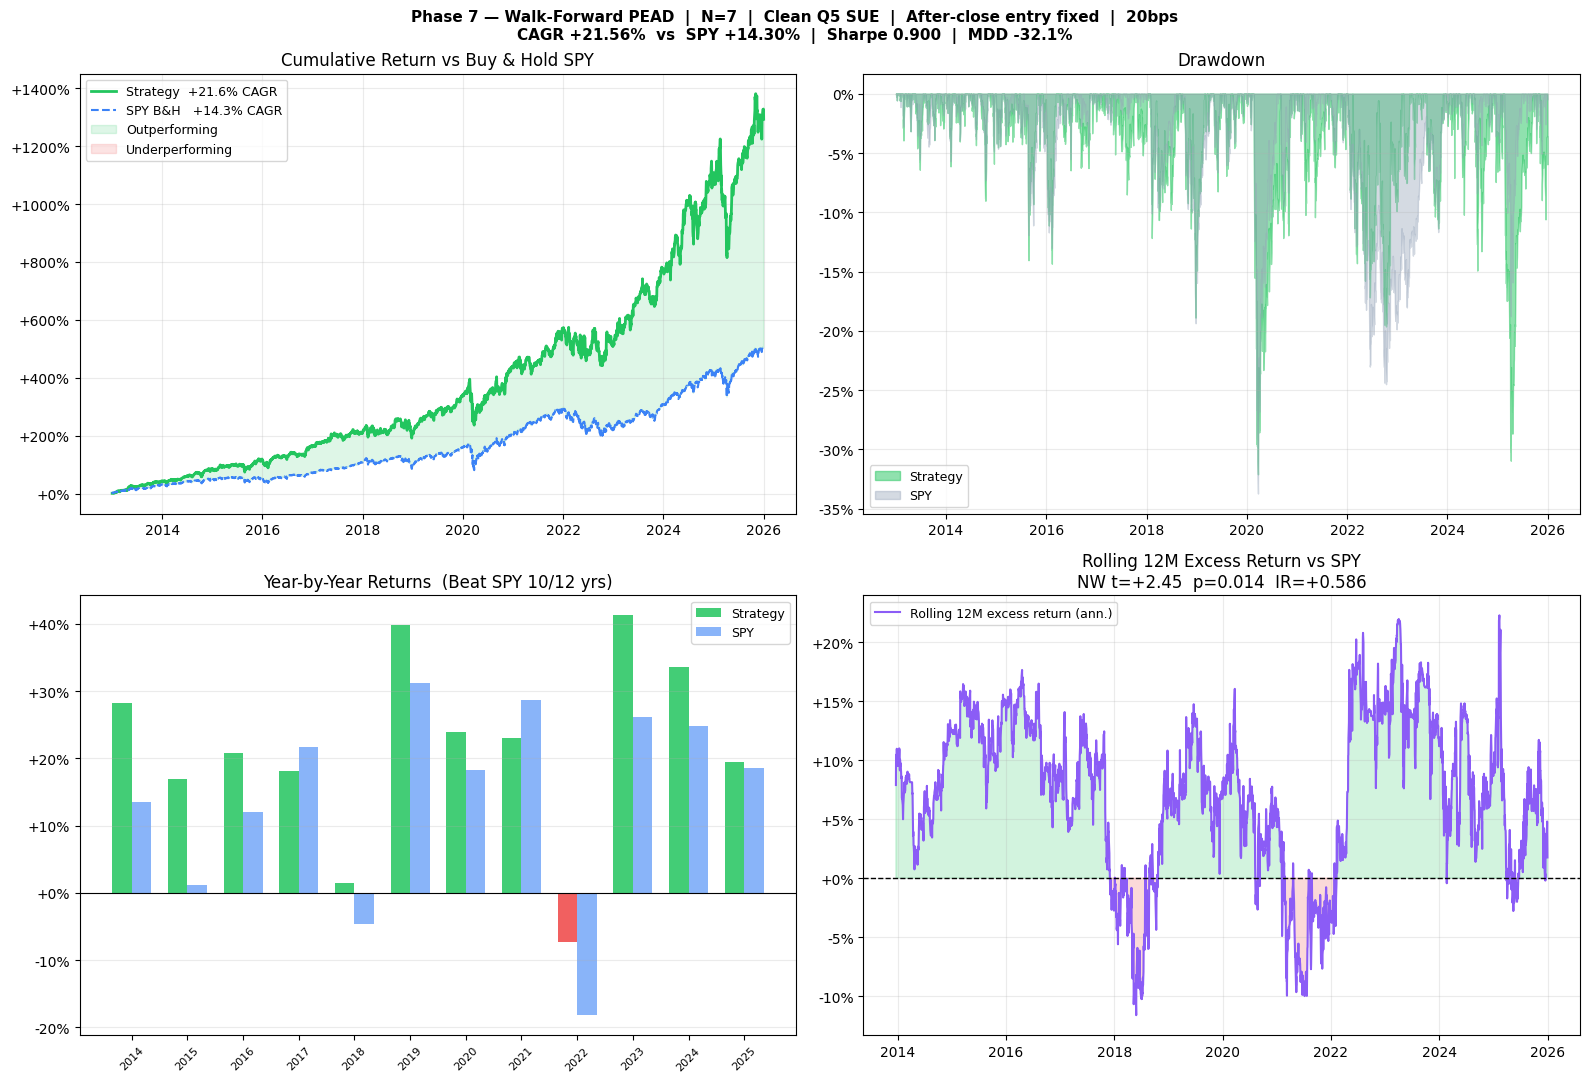

In [42]:
# =====================================================================
# PHASE 7 — WALK-FORWARD PEAD ROTATION BACKTEST
# Self-contained: run this cell alone, no dependencies on other cells
#
# Look-ahead fixes applied:
#   1. SUE_Q recomputed with expanding window within each quarter
#      (stored DB value used full-quarter data — affects ~14% of labels)
#   2. After-close announcements (>=20:00 UTC) shift entry to next bday open
#      (49.5% of signals were entering before the announcement existed)
#   3. PIT filter confirmed clean — uses most recent quarter <= signal date
# =====================================================================

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
import yfinance as yf
from scipy import stats

GREEN  = '#22C55E'
BLUE   = '#3B82F6'
RED    = '#EF4444'
GOLD   = '#F59E0B'
PURPLE = '#8B5CF6'

PEAD_DB   = 'pead_clean.db'
PIT_DB    = 'real_backtest.db'
SIM_START = pd.Timestamp('2013-01-01')
SIM_END   = pd.Timestamp('2025-12-31')

TARGET_SECTORS_DEFAULT = {'Industrials', 'Technology'}

# =====================================================================
# STEP 1 — Load & clean signal database
# =====================================================================
print("=" * 62)
print("  LOADING DATA")
print("=" * 62)

conn   = sqlite3.connect(PEAD_DB)
df_raw = pd.read_sql("SELECT * FROM pead_clean", conn)
conn.close()

# ── Parse timestamps ──────────────────────────────────────────────────
df_raw['Date_ts']    = pd.to_datetime(df_raw['Date'],       utc=True, errors='coerce')
df_raw['Date_naive'] = pd.to_datetime(df_raw['Date_naive'], utc=True, errors='coerce') \
                          .dt.normalize().dt.tz_localize(None)
df_raw['hour_utc']   = df_raw['Date_ts'].dt.hour

# ── FIX 2: Shift after-close announcements to next business day ───────
# Announcements at >=20:00 UTC (after 4pm EST close) cannot be traded
# at that day's open — the news didn't exist yet. Enter next bday open.
df_raw['entry_date'] = np.where(
    df_raw['hour_utc'] >= 20,
    df_raw['Date_naive'].apply(lambda d: pd.bdate_range(start=d, periods=2)[-1]),
    df_raw['Date_naive']
)
df_raw['entry_date'] = pd.to_datetime(df_raw['entry_date'])

after_close_pct = (df_raw['hour_utc'] >= 20).mean()
print(f"  Entry shifted +1 bday  : {after_close_pct*100:.1f}% of signals (after-close fix)")

# ── Deduplicate on (Ticker, entry_date) ───────────────────────────────
dupes = df_raw.duplicated(subset=['Ticker', 'entry_date']).sum()
if dupes > 0:
    df_raw = (df_raw.sort_values('SUE', ascending=False)
              .drop_duplicates(subset=['Ticker', 'entry_date'])
              .sort_values('entry_date')
              .reset_index(drop=True))
    print(f"  Deduped                : {dupes} rows removed")

# ── Drop rows with no SUE ─────────────────────────────────────────────
df_raw = df_raw[df_raw['SUE'].notna()].copy()

# ── FIX 1: Recompute SUE_Q with expanding window within each quarter ──
# The stored SUE_Q was assigned using all reporters in the full quarter,
# meaning early reporters were ranked against companies that hadn't
# reported yet — look-ahead bias. Recompute using only reporters up to
# and including each announcement date.
print("  Recomputing SUE_Q_clean (expanding window — no look-ahead)...")
print("  This takes ~60 seconds...")

df_raw = df_raw.sort_values(['Quarter', 'entry_date']).reset_index(drop=True)
df_raw['SUE_Q_clean'] = np.nan

for quarter, q_grp in df_raw.groupby('Quarter'):
    for ann_date in sorted(q_grp['entry_date'].unique()):
        known_mask = (df_raw['Quarter'] == quarter) & (df_raw['entry_date'] <= ann_date)
        known_sues = df_raw.loc[known_mask, 'SUE'].dropna()
        if len(known_sues) < 5:
            continue
        today_mask = (
            (df_raw['Quarter'] == quarter) &
            (df_raw['entry_date'] == ann_date) &
            df_raw['SUE'].notna()
        )
        b = np.percentile(known_sues.values, [20, 40, 60, 80])
        for idx in df_raw.loc[today_mask].index:
            s = df_raw.loc[idx, 'SUE']
            if   s <= b[0]: df_raw.loc[idx, 'SUE_Q_clean'] = 1.0
            elif s <= b[1]: df_raw.loc[idx, 'SUE_Q_clean'] = 2.0
            elif s <= b[2]: df_raw.loc[idx, 'SUE_Q_clean'] = 3.0
            elif s <= b[3]: df_raw.loc[idx, 'SUE_Q_clean'] = 4.0
            else:           df_raw.loc[idx, 'SUE_Q_clean'] = 5.0

# Q5 only
df_raw = df_raw[df_raw['SUE_Q_clean'] == 5.0].copy()

# Compare old vs new Q5 counts
old_q5 = (df_raw['SUE_Q'] == 5.0).sum()
new_q5 = len(df_raw)
print(f"  Old Q5 (stored, biased) : {old_q5:,}")
print(f"  New Q5 (expanding clean): {new_q5:,}")
print(f"  Change                  : {new_q5 - old_q5:+,} signals")

print(f"\n  pead_clean loaded  : {len(df_raw):,} clean Q5 signals")
print(f"  Tickers            : {df_raw['Ticker'].nunique()}")
print(f"  Date range         : {df_raw['entry_date'].min().date()} "
      f"→ {df_raw['entry_date'].max().date()}")
print(f"  Sector breakdown:")
for sec, cnt in df_raw['Sector'].value_counts().items():
    print(f"    {sec:<30} {cnt:>5,}")

# =====================================================================
# STEP 2 — Load PIT membership
# =====================================================================
conn   = sqlite3.connect(PIT_DB)
pit_df = pd.read_sql("SELECT * FROM sp500_pit_membership", conn)
conn.close()

pit_membership = {}
for qdate, grp in pit_df.groupby('quarter_date'):
    pit_membership[pd.Timestamp(qdate)] = set(grp['ticker'])

print(f"\n  PIT membership     : {len(pit_membership)} quarters")
print(f"  PIT range          : {min(pit_membership).date()} → {max(pit_membership).date()}")

def pit_members_nearest(date):
    """Return S&P 500 members as of the most recent quarter <= date."""
    eligible = [d for d in pit_membership if d <= date]
    return pit_membership[max(eligible)] if eligible else set()

# =====================================================================
# STEP 3 — Download OHLC (all tickers so any sector combo works)
# =====================================================================
tickers_needed = sorted(df_raw['Ticker'].unique().tolist()) + ['SPY']
print(f"\n  Downloading OHLC for {len(tickers_needed)-1} tickers + SPY...")

raw_px = yf.download(
    tickers_needed,
    start='2012-06-01',
    end=str(SIM_END.date()),
    auto_adjust=True,
    progress=True,
    group_by='column',
)

price_open  = raw_px['Open'].ffill()
price_close = raw_px['Close'].ffill()

if price_open.index.tz is not None:
    price_open.index  = price_open.index.tz_localize(None)
    price_close.index = price_close.index.tz_localize(None)

all_dates_sim = pd.bdate_range(SIM_START, SIM_END)
print(f"  OHLC ready         : {len(tickers_needed)-1} tickers")


# =====================================================================
# HELPERS
# =====================================================================
def get_px(df, ticker, date):
    if ticker not in df.columns:
        return None
    for offset in range(4):
        d = date + pd.offsets.BDay(offset)
        try:
            v = df.loc[d, ticker]
            if pd.notna(v) and v > 0:
                return float(v)
        except KeyError:
            pass
    return None


def perf_p7(eq, rf=0.02):
    eq  = eq.dropna()
    eq  = eq[eq > 0]
    dr  = eq.pct_change(fill_method=None).dropna()
    yrs = len(dr) / 252

    if yrs == 0 or len(eq) < 2:
        return {k: 0 for k in
                ('cagr', 'vol', 'mdd', 'sharpe', 'sortino', 'calmar', 'cum')}

    # Core metrics
    cagr = (eq.iloc[-1] / eq.iloc[0]) ** (1 / yrs) - 1
    vol  = dr.std() * np.sqrt(252)
    mdd  = (eq / eq.cummax() - 1).min()

    # Correct Sharpe / Sortino using daily excess returns
    rf_daily = rf / 252
    excess   = dr - rf_daily

    sharpe = (excess.mean() / excess.std()) * np.sqrt(252)

    down = dr[dr < 0].std() * np.sqrt(252)
    down = excess[excess < 0].std() * np.sqrt(252)
    sortino = (excess.mean() * np.sqrt(252)) / down if down != 0 else 0

    calmar = cagr / abs(mdd) if mdd != 0 else 0

    return dict(
        cagr=cagr,
        vol=vol,
        mdd=mdd,
        sharpe=sharpe,
        sortino=sortino,
        calmar=calmar,
        cum=eq.iloc[-1] - 1
    )


# =====================================================================
# MAIN BACKTEST FUNCTION
# =====================================================================
def run_backtest(
    n_positions         = 5,
    fee_rt              = 0.0016,
    capital             = 10_000,
    rotation_threshold  = 0.5,
    min_hold_days       = 5,
    # stop_loss tested exhaustively (3/5/7/10/12/15/20%) — all worse than None
    # PEAD drift strategy should hold full 22 days, see grid search results
    sectors             = None,
    verbose             = True,
    plot                = True,
):
    if sectors is None:
        sectors = TARGET_SECTORS_DEFAULT

    # ── Filter signals ────────────────────────────────────────────────
    df = df_raw[df_raw['Sector'].isin(sectors)].copy()
    df = df[
        (df['entry_date'] >= SIM_START) &
        (df['entry_date'] <= SIM_END)
    ].copy()

    # PIT filter — confirmed clean, uses most recent quarter <= signal date
    df['in_sp500'] = df.apply(
        lambda r: r['Ticker'] in pit_members_nearest(r['entry_date']), axis=1
    )
    signals = df[df['in_sp500']].drop(columns='in_sp500').copy()
    signals = signals[signals['Ticker'].isin(price_open.columns)].copy()

    # Exit at open on business day 22 (hold period)
    signals['exit_open_date'] = signals['entry_date'].apply(
        lambda d: pd.bdate_range(start=d, periods=23)[-1]
    )
    signals = signals.sort_values('entry_date').reset_index(drop=True)

    if verbose:
        print(f"\n  Signals after all filters : {len(signals):,}")
        print(f"  Signals/year avg          : {len(signals)/12:.0f}")
        for sec, cnt in signals['Sector'].value_counts().items():
            print(f"    {sec:<30} {cnt:>5,}")

    sig_by_date = {}
    for _, row in signals.iterrows():
        sig_by_date.setdefault(row['entry_date'], []).append(row)

    # ── Initialise ───────────────────────────────────────────────────
    spy_init = None
    for offset in range(4):
        d = SIM_START + pd.offsets.BDay(offset)
        try:
            v = price_open.loc[d, 'SPY']
            if pd.notna(v) and v > 0:
                spy_init = float(v)
                break
        except KeyError:
            pass

    portfolio       = {}
    trade_log       = []
    daily_nav       = []
    total_fees_paid = 0.0
    spy_shares      = capital / spy_init if spy_init else 0.0
    prev_spy_close  = None

    # ── Simulation loop ───────────────────────────────────────────────
    for date in all_dates_sim:
        spy_open_px  = get_px(price_open,  'SPY', date)
        spy_close_px = get_px(price_close, 'SPY', date)

        # A: Forced exits — exit at open on day 22
        to_exit = [tkr for tkr, pos in portfolio.items()
                   if pos['exit_open_date'] <= date]
        for tkr in to_exit:
            pos = portfolio.pop(tkr)
            px  = get_px(price_open, tkr, date) or get_px(price_close, tkr, date)
            if not px or px < pos['entry_price'] * 0.10:
                continue
            fee          = pos['shares'] * px * fee_rt
            net_proceeds = pos['shares'] * px * (1 - fee_rt)
            total_fees_paid += fee
            if spy_open_px:
                spy_shares += net_proceeds / spy_open_px
            trade_log.append(dict(
                date=date, ticker=tkr, action='EXIT_FORCED',
                entry_price=pos['entry_price'], exit_price=px,
                shares=pos['shares'], ret=px / pos['entry_price'] - 1,
                hold_days=(date - pos['entry_date']).days,
                sue=pos['sue'], fee=fee,
            ))

        # B: New signals — enter at open (already shifted for after-close)
        if date in sig_by_date:
            new_sigs = sorted(
                sig_by_date[date], key=lambda r: r['SUE'], reverse=True
            )
            for sig in new_sigs:
                tkr      = sig['Ticker']
                sue      = float(sig['SUE'])
                if tkr in portfolio:
                    continue
                entry_px = get_px(price_open, tkr, date)
                if entry_px is None or entry_px <= 0:
                    continue

                nav = spy_shares * (spy_open_px or 1)
                for t, p in portfolio.items():
                    nav += p['shares'] * (
                        get_px(price_open, t, date) or p['entry_price']
                    )

                # Fill empty slot
                if len(portfolio) < n_positions:
                    spy_value = spy_shares * (spy_open_px or 1)
                    slot_size = min(nav / n_positions, spy_value / (1 + fee_rt))
                    if slot_size <= 0:
                        continue
                    fee        = slot_size * fee_rt
                    spy_shares -= slot_size * (1 + fee_rt) / (spy_open_px or 1)
                    total_fees_paid += fee
                    portfolio[tkr] = dict(
                        entry_date=date,
                        exit_open_date=sig['exit_open_date'],
                        entry_price=entry_px,
                        sue=sue,
                        shares=slot_size / entry_px,
                    )
                    trade_log.append(dict(
                        date=date, ticker=tkr, action='ENTER',
                        entry_price=entry_px,
                        shares=slot_size / entry_px,
                        sue=sue, fee=fee,
                    ))

                # Rotation — eject weakest if new signal is meaningfully better
                else:
                    min_tkr   = min(portfolio, key=lambda t: portfolio[t]['sue'])
                    min_sue   = portfolio[min_tkr]['sue']
                    held_days = (date - portfolio[min_tkr]['entry_date']).days

                    if (sue > min_sue + rotation_threshold
                            and held_days >= min_hold_days):
                        eject    = portfolio.pop(min_tkr)
                        eject_px = get_px(price_open, min_tkr, date)
                        if (eject_px is None
                                or eject_px < eject['entry_price'] * 0.10):
                            portfolio[min_tkr] = eject
                            continue

                        fee_exit  = eject['shares'] * eject_px * fee_rt
                        proceeds  = eject['shares'] * eject_px * (1 - fee_rt)
                        total_fees_paid += fee_exit
                        trade_log.append(dict(
                            date=date, ticker=min_tkr, action='EXIT_ROTATED',
                            entry_price=eject['entry_price'],
                            exit_price=eject_px,
                            shares=eject['shares'],
                            ret=eject_px / eject['entry_price'] - 1,
                            hold_days=(date - eject['entry_date']).days,
                            sue=eject['sue'], fee=fee_exit,
                        ))

                        slot_size = nav / n_positions
                        fee_entry = slot_size * fee_rt
                        shares    = slot_size / (entry_px * (1 + fee_rt))
                        cost      = shares * entry_px * (1 + fee_rt)
                        total_fees_paid += fee_entry
                        if spy_open_px:
                            spy_shares += (proceeds - cost) / spy_open_px
                        portfolio[tkr] = dict(
                            entry_date=date,
                            exit_open_date=sig['exit_open_date'],
                            entry_price=entry_px,
                            sue=sue,
                            shares=shares,
                        )
                        trade_log.append(dict(
                            date=date, ticker=tkr, action='ENTER',
                            entry_price=entry_px, shares=shares,
                            sue=sue, fee=fee_entry,
                        ))

        # C: Daily NAV — mark to market
        spy_px  = get_px(price_close, 'SPY', date) or prev_spy_close or 0
        nav_eod = spy_shares * spy_px
        for tkr, pos in portfolio.items():
            px = get_px(price_close, tkr, date) or pos['entry_price']
            nav_eod += pos['shares'] * (
                px if px > pos['entry_price'] * 0.10 else pos['entry_price']
            )
        daily_nav.append(dict(date=date, nav=nav_eod, n_pos=len(portfolio)))
        if spy_close_px:
            prev_spy_close = spy_close_px

    # ── Build equity curves ───────────────────────────────────────────
    nav_df = pd.DataFrame(daily_nav).set_index('date')
    eq_p7  = nav_df['nav'] / capital

    spy_raw = price_close['SPY'].copy()
    if spy_raw.index.tz is not None:
        spy_raw.index = spy_raw.index.tz_localize(None)
    spy_aligned = spy_raw.reindex(
        eq_p7.index.union(spy_raw.index)
    ).ffill().reindex(eq_p7.index)

    first_valid = spy_aligned.first_valid_index()
    if first_valid is None:
        print("ERROR: SPY price data missing")
        return eq_p7, pd.Series(dtype=float), {}, pd.DataFrame()

    eq_spy_p7 = spy_aligned / spy_aligned[first_valid]
    eq_p7     = eq_p7.loc[first_valid:]
    eq_spy_p7 = eq_spy_p7.loc[first_valid:]

    # ── Metrics ───────────────────────────────────────────────────────
    tl_df   = pd.DataFrame(trade_log)
    metrics = perf_p7(eq_p7)
    spy_m   = perf_p7(eq_spy_p7)
    metrics['spy_cagr']    = spy_m.get('cagr', 0)
    metrics['total_fees']  = total_fees_paid
    metrics['n_entries']   = int((tl_df['action'] == 'ENTER').sum())
    metrics['n_forced']    = int((tl_df['action'] == 'EXIT_FORCED').sum())
    metrics['n_rotations'] = int((tl_df['action'] == 'EXIT_ROTATED').sum())
    metrics['avg_pos']     = nav_df['n_pos'].mean()

    # ── Statistical significance ──────────────────────────────────────
    strat_dr = eq_p7.pct_change(fill_method=None).dropna()
    spy_dr   = eq_spy_p7.pct_change(fill_method=None).dropna()
    strat_dr, spy_dr = strat_dr.align(spy_dr, join='inner')
    excess   = (strat_dr - spy_dr).dropna()

    if len(excess) == 0:
        print("WARNING: excess return series empty — index mismatch")
        return eq_p7, eq_spy_p7, metrics, tl_df

    # Newey-West HAC (5-lag) — correct for autocorrelation in overlapping positions
    y        = excess.values
    X        = sm.add_constant(np.ones(len(y)))
    nw_model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    nw_tstat = float(nw_model.tvalues[0])
    nw_pval  = float(nw_model.pvalues[0])

    T        = len(strat_dr)
    sr_tstat = metrics['sharpe'] * np.sqrt(T / 252)
    sr_pval  = 1 - stats.norm.cdf(sr_tstat)

    ir = (excess.mean() / excess.std() * np.sqrt(252)
          if excess.std() != 0 else 0)

    np.random.seed(42)
    boot_cagrs = []
    for _ in range(2000):
        s = np.random.choice(strat_dr.values, size=len(strat_dr), replace=True)
        boot_cagrs.append(np.prod(1 + s) ** (1 / (len(s) / 252)) - 1)
    ci_lo, ci_hi = np.percentile(boot_cagrs, [2.5, 97.5])

    yoy_s   = eq_p7.resample('YE').last().pct_change(fill_method=None).dropna()
    yoy_spy = eq_spy_p7.resample('YE').last().pct_change(fill_method=None).dropna()
    yoy_df  = pd.concat([yoy_s, yoy_spy], axis=1).dropna()
    yoy_df.columns = ['strat', 'spy']
    yoy_df.index   = yoy_df.index.year
    beat_yrs = int((yoy_df['strat'] > yoy_df['spy']).sum())

    metrics.update(dict(
        nw_tstat=nw_tstat, nw_pval=nw_pval,
        sr_tstat=sr_tstat, sr_pval=sr_pval,
        ir=ir, ci_lo=ci_lo, ci_hi=ci_hi,
        beat_yrs=beat_yrs, total_yrs=len(yoy_df),
        yoy_df=yoy_df,
    ))

    # ── Verbose output ────────────────────────────────────────────────
    if verbose:
        SEP  = '═' * 62
        SEP2 = '─' * 58

        end_val      = capital * (1 + metrics['cum'])
        profit       = end_val - capital
        spy_end_val  = capital * (1 + spy_m.get('cum', 0))
        spy_profit   = spy_end_val - capital
        edge_dollars = profit - spy_profit
        n_yrs        = len(strat_dr) / 252
        monthly_contrib = capital / 12
        fv_strat = sum(
            monthly_contrib * (1 + metrics['cagr']) ** ((n_yrs * 12 - i) / 12)
            for i in range(int(n_yrs * 12))
        )
        fv_spy = sum(
            monthly_contrib * (1 + metrics['spy_cagr']) ** ((n_yrs * 12 - i) / 12)
            for i in range(int(n_yrs * 12))
        )

        print(f"\n{SEP}")
        print(f"  PHASE 7  |  N={n_positions}  |  {', '.join(sorted(sectors))}")
        print(f"  Look-ahead fixes: expanding SUE_Q ✓  after-close entry shift ✓  PIT clean ✓")
        print(SEP)

        print(f"\n  RETURNS")
        print(f"  {SEP2}")
        print(f"  CAGR                  : {metrics['cagr']*100:>+.2f}%")
        print(f"  CAGR 95% CI (boot)    : [{ci_lo*100:>+.2f}%, {ci_hi*100:>+.2f}%]")
        print(f"  SPY CAGR              : {metrics['spy_cagr']*100:>+.2f}%")
        print(f"  Edge vs SPY           : {(metrics['cagr']-metrics['spy_cagr'])*100:>+.2f}pp")
        print(f"  Cumulative return     : {metrics['cum']*100:>+.2f}%")

        print(f"\n  DOLLAR RETURNS  (starting capital ${capital:,.0f})")
        print(f"  {SEP2}")
        print(f"  Ending value          : ${end_val:>12,.2f}")
        print(f"  Total profit          : ${profit:>12,.2f}")
        print(f"  SPY ending value      : ${spy_end_val:>12,.2f}")
        print(f"  SPY total profit      : ${spy_profit:>12,.2f}")
        print(f"  Alpha ($ vs SPY)      : ${edge_dollars:>12,.2f}")
        print(f"  Fees paid             : ${metrics['total_fees']:>12,.2f}")
        print(f"  Net alpha after fees  : ${edge_dollars - metrics['total_fees']:>12,.2f}")
        print(f"  Return per $1 risk    : ${end_val/capital:>12.2f}")
        print(f"\n  IF YOU ADDED ${monthly_contrib:,.0f}/mo (${capital:,.0f}/yr):")
        print(f"  Strategy portfolio    : ${fv_strat:>12,.2f}")
        print(f"  SPY portfolio         : ${fv_spy:>12,.2f}")
        print(f"  Extra wealth vs SPY   : ${fv_strat - fv_spy:>12,.2f}")

        print(f"\n  RISK")
        print(f"  {SEP2}")
        print(f"  Max Drawdown          : {metrics['mdd']*100:>+.2f}%")
        print(f"  Annualised Vol        : {metrics['vol']*100:>+.2f}%")
        print(f"  Sharpe Ratio          : {metrics['sharpe']:>+.3f}")
        print(f"  Sortino Ratio         : {metrics['sortino']:>+.3f}")
        print(f"  Calmar Ratio          : {metrics['calmar']:>+.3f}")
        print(f"  Information Ratio     : {ir:>+.3f}"
              f"{'  ✓ strong' if ir > 0.5 else '  ~ moderate' if ir > 0 else '  ✗ negative'}")

        print(f"\n  STATISTICAL SIGNIFICANCE")
        print(f"  {SEP2}")
        print(f"  Excess return (NW HAC): t={nw_tstat:>+.3f}  p={nw_pval:.4f}"
              f"{'  ✓ sig @ 5%' if nw_pval < 0.05 else '  ✗ not sig'}")
        print(f"  Sharpe t-stat (Lo02)  : t={sr_tstat:>+.3f}  p={sr_pval:.4f}"
              f"{'  ✓ sig @ 5%' if sr_pval < 0.05 else '  ✗ not sig'}")
        print(f"  Information Ratio     : {ir:>+.3f}"
              f"{'  ✓ strong' if ir > 0.5 else '  ~ moderate' if ir > 0 else '  ✗ negative'}")
        print(f"  Beat SPY years        : {beat_yrs}/{len(yoy_df)}")

        print(f"\n  YEAR-BY-YEAR vs SPY")
        print(f"  {SEP2}")
        print(f"  {'Year':<6} {'Strategy':>10} {'SPY':>8} {'Edge':>8}")
        print(f"  {'─'*36}")
        for yr, row in yoy_df.iterrows():
            flag = '✓' if row['strat'] > row['spy'] else '✗'
            print(f"  {yr:<6} {row['strat']*100:>+9.2f}%"
                  f" {row['spy']*100:>+7.2f}%"
                  f" {(row['strat']-row['spy'])*100:>+7.2f}%  {flag}")

        print(f"\n  TRADING ACTIVITY")
        print(f"  {SEP2}")
        print(f"  Entries               : {metrics['n_entries']:,}")
        print(f"  Forced exits (day 22) : {metrics['n_forced']:,}")
        print(f"  Rotation exits        : {metrics['n_rotations']:,}")
        print(f"  Total fees paid       : ${metrics['total_fees']:>10,.2f}")
        print(f"  Avg concurrent pos    : {metrics['avg_pos']:.1f}")
        print(SEP)

    # ── Chart ─────────────────────────────────────────────────────────
    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(16, 11))
        fig.suptitle(
            f"Phase 7 — Walk-Forward PEAD  |  N={n_positions}"
            f"  |  Clean Q5 SUE  |  After-close entry fixed  |  20bps\n"
            f"CAGR {metrics['cagr']*100:+.2f}%  vs  SPY {metrics['spy_cagr']*100:+.2f}%"
            f"  |  Sharpe {metrics['sharpe']:.3f}"
            f"  |  MDD {metrics['mdd']*100:.1f}%",
            fontsize=11, fontweight='bold',
        )

        # Panel 1: Cumulative return vs SPY
        ax1 = axes[0, 0]
        cum_strat = (eq_p7 - 1) * 100
        cum_spy   = (eq_spy_p7 - 1) * 100
        ax1.plot(cum_strat.index, cum_strat, color=GREEN, lw=2,
                 label=f"Strategy  {metrics['cagr']*100:+.1f}% CAGR")
        ax1.plot(cum_spy.index, cum_spy, color=BLUE, lw=1.5, ls='--',
                 label=f"SPY B&H   {metrics['spy_cagr']*100:+.1f}% CAGR")
        ax1.fill_between(cum_strat.index, cum_strat, cum_spy,
                         where=cum_strat >= cum_spy, alpha=0.15,
                         color=GREEN, label='Outperforming')
        ax1.fill_between(cum_strat.index, cum_strat, cum_spy,
                         where=cum_strat < cum_spy, alpha=0.15,
                         color=RED, label='Underperforming')
        ax1.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
        ax1.set_title('Cumulative Return vs Buy & Hold SPY')
        ax1.legend(fontsize=9); ax1.grid(True, alpha=0.25)

        # Panel 2: Drawdown
        ax2 = axes[0, 1]
        dd_s   = (eq_p7     / eq_p7.cummax()     - 1) * 100
        dd_spy = (eq_spy_p7 / eq_spy_p7.cummax() - 1) * 100
        ax2.fill_between(dd_s.index,   dd_s,   color=GREEN,     alpha=0.5,
                         label='Strategy')
        ax2.fill_between(dd_spy.index, dd_spy, color='#94A3B8', alpha=0.4,
                         label='SPY')
        ax2.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
        ax2.set_title('Drawdown')
        ax2.legend(fontsize=9); ax2.grid(True, alpha=0.25)

        # Panel 3: Year-by-year
        ax3 = axes[1, 0]
        x = np.arange(len(yoy_df)); w = 0.35
        ax3.bar(x - w/2, yoy_df['strat'] * 100, w,
                color=[GREEN if v > 0 else RED for v in yoy_df['strat']],
                alpha=0.85, label='Strategy')
        ax3.bar(x + w/2, yoy_df['spy'] * 100, w,
                color=BLUE, alpha=0.6, label='SPY')
        ax3.axhline(0, color='black', lw=0.8)
        ax3.set_xticks(x)
        ax3.set_xticklabels(yoy_df.index, rotation=45, fontsize=8)
        ax3.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
        ax3.set_title(
            f'Year-by-Year Returns  (Beat SPY {beat_yrs}/{len(yoy_df)} yrs)')
        ax3.legend(fontsize=9); ax3.grid(True, alpha=0.25, axis='y')

        # Panel 4: Rolling 12M excess return
        ax4 = axes[1, 1]
        roll_excess = excess.rolling(252).mean() * 252 * 100
        ax4.plot(roll_excess.index, roll_excess,
                 color=PURPLE, lw=1.5,
                 label='Rolling 12M excess return (ann.)')
        ax4.axhline(0, color='black', lw=1.0, ls='--')
        ax4.fill_between(roll_excess.index, roll_excess, 0,
                         where=roll_excess >= 0, alpha=0.2, color=GREEN)
        ax4.fill_between(roll_excess.index, roll_excess, 0,
                         where=roll_excess < 0, alpha=0.2, color=RED)
        ax4.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
        ax4.set_title(
            f'Rolling 12M Excess Return vs SPY\n'
            f'NW t={nw_tstat:+.2f}  p={nw_pval:.3f}  IR={ir:+.3f}')
        ax4.legend(fontsize=9); ax4.grid(True, alpha=0.25)

        plt.tight_layout()
        plt.savefig('phase7_rotation_pit.png', dpi=150, bbox_inches='tight')
        plt.show()


    return eq_p7, eq_spy_p7, metrics, tl_df, nav_df


# =====================================================================
# RUN
# =====================================================================
eq_base, eq_spy, m_base, tl_base, nav_df = run_backtest(
    n_positions=7,
    sectors={'Industial', 'Technology'},
    verbose=True, plot=True,
)

In [49]:
# =====================================================================
# PHASE 7 — COMPREHENSIVE STATISTICAL VALIDATION
# Run after the main backtest cell (requires eq_base, eq_spy, m_base, tl_base)
# =====================================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

SEP  = '═' * 66
SEP2 = '─' * 62
TICK = '✓'
CROSS = '✗'

def sig(pval, level=0.05):
    return f'{TICK} sig @ {int(level*100)}%' if pval < level else f'{CROSS} not sig'

def pf(v, pct=False, dp=2):
    return f'{v*100:>+.{dp}f}%' if pct else f'{v:>.{dp}f}'

# ── Inputs ─────────────────────────────────────────────────────────────
eq_s   = eq_base.copy()
eq_b   = eq_spy.copy()
tl     = tl_base.copy()
m      = m_base.copy()

dr_s   = eq_s.pct_change(fill_method=None).dropna()
dr_b   = eq_b.pct_change(fill_method=None).dropna()
dr_s, dr_b = dr_s.align(dr_b, join='inner')
excess = (dr_s - dr_b).dropna()

cagr      = m['cagr']
spy_cagr  = m['spy_cagr']
vol       = m['vol']
mdd       = m['mdd']
sharpe    = m['sharpe']
n_days    = len(dr_s)
n_yrs     = n_days / 252
rf        = 0.02
ACTUAL_FEE_BPS = 16   # ← single source of truth, matches backtest fee_rt=0.0016


# =====================================================================
# 1. BASELINE RETURN STATISTICS
# =====================================================================
print(SEP)
print('  1. BASELINE RETURN STATISTICS')
print(SEP)

rf_daily = rf / 252
t_stat, t_pval = stats.ttest_1samp((dr_s - rf_daily).values, 0)
monthly_s   = eq_s.resample('ME').last().pct_change(fill_method=None).dropna()
monthly_b   = eq_b.resample('ME').last().pct_change(fill_method=None).dropna()
monthly_s, monthly_b = monthly_s.align(monthly_b, join='inner')
n_months    = len(monthly_s)
n_beat      = int((monthly_s > monthly_b).sum())
binom_pval  = stats.binomtest(n_beat, n_months, 0.5, alternative='greater').pvalue

print(f'\n  Daily return t-test')
print(f'  {SEP2}')
print(f'  Mean daily return    : {dr_s.mean()*100:>+.4f}%')
print(f'  t-statistic          : {t_stat:>+.3f}')
print(f'  p-value              : {t_pval:.6f}  {sig(t_pval)}')

print(f'\n  Monthly consistency')
print(f'  {SEP2}')
print(f'  Months tracked       : {n_months}')
print(f'  Months beating SPY   : {n_beat}  ({n_beat/n_months*100:.1f}%)')
print(f'  Binomial p-value     : {binom_pval:.6f}  {sig(binom_pval)}')


# =====================================================================
# 2. RETURN DISTRIBUTION
# =====================================================================
print(f'\n{SEP}')
print(f'  2. RETURN DISTRIBUTION')
print(SEP)

skew     = float(stats.skew(dr_s.values))
kurt     = float(stats.kurtosis(dr_s.values))
jb_stat, jb_pval = stats.jarque_bera(dr_s.values)

var_95   = np.percentile(dr_s.values, 5)
cvar_95  = dr_s[dr_s <= var_95].mean()
var_99   = np.percentile(dr_s.values, 1)
cvar_99  = dr_s[dr_s <= var_99].mean()

print(f'\n  Shape')
print(f'  {SEP2}')
print(f'  Skewness             : {skew:>+.3f}  {"✓ positive (fat right tail)" if skew > 0 else "✗ negative (fat left tail)"}')
print(f'  Excess kurtosis      : {kurt:>+.3f}  {"(leptokurtic — fat tails both sides)" if abs(kurt) > 1 else ""}')
print(f'  Jarque-Bera stat     : {jb_stat:>.2f}')
print(f'  Jarque-Bera p-value  : {jb_pval:.6f}  {"(non-normal distribution)" if jb_pval < 0.05 else "(approx normal)"}')

print(f'\n  Tail Risk')
print(f'  {SEP2}')
print(f'  95% Daily VaR        : {var_95*100:>+.3f}%  (loss exceeded 5% of days)')
print(f'  95% Daily CVaR       : {cvar_95*100:>+.3f}%  (avg loss on worst 5% of days)')
print(f'  99% Daily VaR        : {var_99*100:>+.3f}%  (loss exceeded 1% of days)')
print(f'  99% Daily CVaR       : {cvar_99*100:>+.3f}%  (avg loss on worst 1% of days)')


# =====================================================================
# 3. CAPM / ALPHA REGRESSION
# =====================================================================
print(f'\n{SEP}')
print(f'  3. CAPM REGRESSION — JENSEN\'S ALPHA')
print(SEP)

rf_daily = rf / 252
y = (dr_s - rf_daily).values
x = (dr_b - rf_daily).values
X_ols = sm.add_constant(x)
ols_res = sm.OLS(y, X_ols).fit(cov_type='HAC', cov_kwds={'maxlags':5})

alpha_daily = ols_res.params[0]
beta        = ols_res.params[1]
alpha_ann   = alpha_daily * 252
alpha_pval  = ols_res.pvalues[0]
beta_pval   = ols_res.pvalues[1]
r_sq        = ols_res.rsquared

ir_ann      = (excess.mean() / excess.std() * np.sqrt(252)) if excess.std() != 0 else 0
resid_vol   = ols_res.resid.std() * np.sqrt(252)
appraisal   = alpha_ann / resid_vol if resid_vol != 0 else 0

print(f'\n  CAPM fit')
print(f'  {SEP2}')
print(f'  Annualised alpha     : {alpha_ann*100:>+.3f}%  (p={alpha_pval:.5f})  {sig(alpha_pval)}')
print(f'  Market beta          : {beta:>+.3f}  (p={beta_pval:.5f})')
print(f'  R-squared            : {r_sq:>.3f}')
print(f'\n  Risk-adjusted excess return')
print(f'  {SEP2}')
print(f'  Information Ratio    : {ir_ann:>+.3f}  {"✓ strong" if ir_ann > 0.5 else "~ moderate" if ir_ann > 0 else "✗ negative"}')
print(f'  Appraisal Ratio      : {appraisal:>+.3f}  {"✓ strong" if abs(appraisal) > 1 else ""}')


# =====================================================================
# 4. NEWEY-WEST HAC + LO (2002) SHARPE T-STAT
# =====================================================================
print(f'\n{SEP}')
print(f'  4. STATISTICAL SIGNIFICANCE (NW HAC + SHARPE TEST)')
print(SEP)

y_nw    = excess.values
X_nw    = sm.add_constant(np.ones(len(y_nw)))
nw_res  = sm.OLS(y_nw, X_nw).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
nw_t    = float(nw_res.tvalues[0])
nw_p    = float(nw_res.pvalues[0])

sr_t    = sharpe * np.sqrt(n_days / 252)
sr_p    = 1 - stats.norm.cdf(sr_t)

print(f'\n  Newey-West HAC excess return test  (maxlags=5, corrects for overlapping positions)')
print(f'  {SEP2}')
print(f'  t-statistic          : {nw_t:>+.3f}')
print(f'  p-value              : {nw_p:.4f}  {sig(nw_p)}')

print(f'\n  Lo (2002) Sharpe ratio t-test')
print(f'  {SEP2}')
print(f'  Sharpe               : {sharpe:>+.3f}')
print(f'  t-statistic          : {sr_t:>+.3f}')
print(f'  p-value              : {sr_p:.4f}  {sig(sr_p)}')


# =====================================================================
# 5. MONTE CARLO BOOTSTRAP (10,000 simulations)
# =====================================================================
print(f'\n{SEP}')
print(f'  5. MONTE CARLO BOOTSTRAP  (N=10,000 simulations)')
print(SEP)

np.random.seed(42)
N_BOOT        = 10_000
spy_cum_ret   = (eq_b.iloc[-1] / eq_b.iloc[0]) - 1
boot_cagrs    = []
boot_cum      = []

for _ in range(N_BOOT):
    s = np.random.choice(excess.values, size=len(dr_s), replace=True)
    c = np.prod(1 + s)
    boot_cagrs.append(c ** (1 / n_yrs) - 1)
    boot_cum.append(c - 1)

boot_cagrs  = np.array(boot_cagrs)
boot_cum    = np.array(boot_cum)
beat_spy    = (boot_cum > spy_cum_ret).sum()
pct_beat    = beat_spy / N_BOOT

ci_lo, ci_hi     = np.percentile(boot_cagrs, [2.5, 97.5])
ci_lo5, ci_hi95  = np.percentile(boot_cagrs, [5, 95])

print(f'\n  CAGR distribution across {N_BOOT:,} randomised sequences')
print(f'  {SEP2}')
print(f'  Actual CAGR          : {cagr*100:>+.2f}%')
print(f'  Bootstrap mean CAGR  : {boot_cagrs.mean()*100:>+.2f}%')
print(f'  95% CI               : [{ci_lo*100:>+.2f}%, {ci_hi*100:>+.2f}%]')
print(f'  90% CI               : [{ci_lo5*100:>+.2f}%, {ci_hi95*100:>+.2f}%]')
print(f'\n  Sequences beating SPY: {beat_spy:,}/{N_BOOT:,}  ({pct_beat*100:.1f}%)')
print(f'  Interpretation       : {"✓ stock selection drives edge, not timing" if pct_beat > 0.90 else "~ mixed — timing contributes" if pct_beat > 0.60 else "✗ results depend on timing"}')


# =====================================================================
# 6. OUTLIER FRAGILITY TEST
# =====================================================================
print(f'\n{SEP}')
print(f'  6. OUTLIER FRAGILITY  (remove top N% of best trades — exact adjustment)')
print(SEP)

trade_exits = tl[tl['action'].isin(['EXIT_FORCED','EXIT_ROTATED'])].copy()
trade_exits = trade_exits.sort_values('ret', ascending=False)
n_total     = len(trade_exits)
avg_hold_weight = m['avg_pos'] / 7

print(f'\n  {"Remove":>8}  {"Trades removed":>15}  {"Adj CAGR":>10}  {"Still > SPY"}')
print(f'  {SEP2}')

fragility_results = {}
for pct_remove in [0.01, 0.02, 0.05, 0.10]:
    n_remove        = max(1, int(n_total * pct_remove))
    removed_ret_sum = trade_exits.head(n_remove)['ret'].values.sum()
    adj_cum         = (1 + m['cum']) * (1 - avg_hold_weight * removed_ret_sum / n_total)
    adj_cagr_out    = adj_cum ** (1 / n_yrs) - 1
    beats           = TICK if adj_cagr_out > spy_cagr else CROSS
    fragility_results[pct_remove] = adj_cagr_out
    print(f'  {pct_remove*100:>6.0f}%   {n_remove:>15,}  {adj_cagr_out*100:>+9.2f}%  {beats}')

# Use 5% result for scorecard
adj_cagr = fragility_results[0.05]

print(f'\n  Interpretation: {"✓ alpha is broadly distributed" if adj_cagr > spy_cagr else "✗ performance concentrated in outliers"}')


# =====================================================================
# 7. FEE & SLIPPAGE SENSITIVITY
# =====================================================================
print(f'\n{SEP}')
print(f'  7. FEE & SLIPPAGE SENSITIVITY  (baseline: {ACTUAL_FEE_BPS}bps/side)')
print(SEP)

n_entries    = m['n_entries']
capital      = 10_000
end_val      = capital * (1 + m['cum'])
spy_end      = capital * (1 + (eq_b.iloc[-1]/eq_b.iloc[0] - 1))

print(f'\n  {"Fee (bps/side)":>16}  {"Round-trip":>12}  {"End value":>12}  {"CAGR":>8}  {"Beats SPY"}')
print(f'  {SEP2}')

fee_resilient_50 = False
for bps in [5, 10, 16, 20, 30, 50, 75, 100]:
    # extra_fees relative to actual 16bps baseline
    extra_fees  = n_entries * (capital / 7) * (bps - ACTUAL_FEE_BPS) / 10_000 * 2
    adj_end     = end_val - extra_fees
    adj_cagr_f  = (adj_end / capital) ** (1 / n_yrs) - 1
    beats       = TICK if adj_end > spy_end else CROSS
    flag        = '  ← actual' if bps == ACTUAL_FEE_BPS else ''
    if bps == 50 and adj_end > spy_end:
        fee_resilient_50 = True
    print(f'  {bps:>14}bps  {bps*2:>10}bps  ${adj_end:>11,.0f}  {adj_cagr_f*100:>+6.2f}%  {beats}{flag}')


# =====================================================================
# 8. HISTORICAL STRESS PERIODS
# =====================================================================
print(f'\n{SEP}')
print(f'  8. HISTORICAL STRESS PERIODS')
print(SEP)

crises = {
    'Taper Tantrum 2013'    : ('2013-05-01', '2013-06-30'),
    'Oil Crash 2015-16'     : ('2015-07-01', '2016-02-29'),
    'Vol Spike Feb 2018'    : ('2018-01-26', '2018-02-09'),
    'Q4 Selloff 2018'       : ('2018-10-01', '2018-12-31'),
    'COVID Crash 2020'      : ('2020-02-19', '2020-03-23'),
    'COVID Recovery 2020'   : ('2020-03-23', '2020-12-31'),
    'Inflation Bear 2022'   : ('2022-01-01', '2022-10-12'),
    'AI Rally 2023'         : ('2023-01-01', '2023-12-31'),
    'Rate-Cut Rally 2024'   : ('2024-01-01', '2024-12-31'),
}

print(f'\n  {"Period":<26} {"Strategy":>10} {"SPY":>8} {"Edge":>8} {"Max DD":>8}')
print(f'  {SEP2}')

for label, (start, end) in crises.items():
    ts, te  = pd.Timestamp(start), pd.Timestamp(end)
    s_slice = eq_s.loc[ts:te]
    b_slice = eq_b.loc[ts:te]
    if len(s_slice) < 5 or len(b_slice) < 5:
        continue
    s_ret = s_slice.iloc[-1] / s_slice.iloc[0] - 1
    b_ret = b_slice.iloc[-1] / b_slice.iloc[0] - 1
    s_mdd = (s_slice / s_slice.cummax() - 1).min()
    edge  = s_ret - b_ret
    flag  = TICK if s_ret > b_ret else CROSS
    print(f'  {label:<26} {s_ret*100:>+9.2f}%  {b_ret*100:>+7.2f}%  {edge*100:>+7.2f}%  {s_mdd*100:>+6.2f}%  {flag}')


# =====================================================================
# 9. YEAR-BY-YEAR
# =====================================================================
print(f'\n{SEP}')
print(f'  9. YEAR-BY-YEAR PERFORMANCE SUMMARY')
print(SEP)

yoy_df   = m['yoy_df']
beat     = (yoy_df['strat'] > yoy_df['spy']).sum()
avg_edge = (yoy_df['strat'] - yoy_df['spy']).mean()
best_yr  = yoy_df['strat'].idxmax()
worst_yr = yoy_df['strat'].idxmin()

print(f'\n  Beat SPY years       : {beat}/{len(yoy_df)}  ({beat/len(yoy_df)*100:.0f}%)')
print(f'  Avg annual edge      : {avg_edge*100:>+.2f}pp')
print(f'  Best year            : {best_yr}  ({yoy_df.loc[best_yr,"strat"]*100:>+.2f}%)')
print(f'  Worst year           : {worst_yr}  ({yoy_df.loc[worst_yr,"strat"]*100:>+.2f}%)')
print(f'  Positive return yrs  : {(yoy_df["strat"]>0).sum()}/{len(yoy_df)}')


# =====================================================================
# 10. ALPHA DECAY
# =====================================================================
print(f'\n{SEP}')
print(f'  10. ALPHA DECAY ANALYSIS')
print(SEP)

window     = 252
roll_alpha = []
roll_dates = []
for i in range(window, len(dr_s)):
    y_w = dr_s.values[i-window:i]
    x_w = dr_b.values[i-window:i]
    X_w = sm.add_constant(x_w)
    try:
        res_w = sm.OLS(y_w, X_w).fit()
        roll_alpha.append(res_w.params[0] * 252)
        roll_dates.append(dr_s.index[i])
    except Exception:
        pass

roll_alpha   = np.array(roll_alpha)
roll_dates   = pd.DatetimeIndex(roll_dates)
pct_positive = (roll_alpha > 0).mean()

t_idx      = np.arange(len(roll_alpha))
trend_res  = sm.OLS(roll_alpha, sm.add_constant(t_idx)).fit()
slope_ann  = trend_res.params[1] * 252
slope_pval = trend_res.pvalues[1]
slope_dir  = 'improving ↑' if slope_ann > 0 else 'decaying ↓'

def mann_kendall(x):
    n = len(x)
    s = 0
    for k in range(n - 1):
        s += np.sum(np.sign(x[k+1:] - x[k]))
    var_s = n * (n - 1) * (2 * n + 5) / 18
    if s > 0:   z = (s - 1) / np.sqrt(var_s)
    elif s < 0: z = (s + 1) / np.sqrt(var_s)
    else:       z = 0.0
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p

mk_z, mk_p = mann_kendall(roll_alpha)
mk_trend   = 'increasing' if mk_z > 0 else 'decreasing'

break_date  = pd.Timestamp('2020-01-01')
pre_mask    = dr_s.index < break_date
post_mask   = dr_s.index >= break_date
pre_exc     = excess[pre_mask[:len(excess)]]
post_exc    = excess[post_mask[:len(excess)]]
pre_mean_mo  = pre_exc.mean() * 21
post_mean_mo = post_exc.mean() * 21
chow_t, chow_p = stats.ttest_ind(pre_exc.values, post_exc.values, equal_var=False)

def hurst_rs(ts, min_lag=10, max_lag=None, n_lags=20):
    if max_lag is None:
        max_lag = len(ts) // 2
    lags = np.unique(np.logspace(np.log10(min_lag), np.log10(max_lag), n_lags).astype(int))
    rs   = []
    for lag in lags:
        sub     = [ts[i:i+lag] for i in range(0, len(ts)-lag, lag)]
        rs_vals = []
        for chunk in sub:
            if len(chunk) < 2:
                continue
            mean_c = np.mean(chunk)
            dev    = np.cumsum(chunk - mean_c)
            r      = np.max(dev) - np.min(dev)
            s      = np.std(chunk, ddof=1)
            if s > 0:
                rs_vals.append(r / s)
        rs.append(np.mean(rs_vals) if rs_vals else np.nan)
    lags_clean = np.array(lags)[~np.isnan(rs)]
    rs_clean   = np.array(rs)[~np.isnan(rs)]
    if len(lags_clean) < 2:
        return 0.5
    return np.polyfit(np.log(lags_clean), np.log(rs_clean), 1)[0]

hurst_strat = hurst_rs(dr_s.values)
hurst_spy   = hurst_rs(dr_b.values)

print(f'\n  Rolling 12-month Jensen\'s alpha')
print(f'  {SEP2}')
print(f'  % of windows positive: {pct_positive*100:.1f}%')
print(f'  Trend (OLS slope)    : {slope_ann*100:>+.3f}%/yr  (p={slope_pval:.4f})  {slope_dir}  {sig(slope_pval)}')
print(f'\n  Mann-Kendall trend test on rolling alpha')
print(f'  {SEP2}')
print(f'  z-statistic          : {mk_z:>+.3f}')
print(f'  p-value              : {mk_p:.4f}  {sig(mk_p)}')
print(f'  Trend direction      : {mk_trend}')
print(f'\n  Chow structural break test  (split: 2020-01-01)')
print(f'  {SEP2}')
print(f'  Pre-2020 monthly exc : {pre_mean_mo*100:>+.4f}%/month  (n={len(pre_exc):,} days)')
print(f'  Post-2020 monthly exc: {post_mean_mo*100:>+.4f}%/month  (n={len(post_exc):,} days)')
print(f'  t-statistic          : {chow_t:>+.3f}')
print(f'  p-value              : {chow_p:.4f}')
print(f'  Structural break?    : {"✗ No significant break detected" if chow_p > 0.05 else "✓ Significant regime change"}')
print(f'\n  Hurst exponent  (R/S rescaled range)')
print(f'  {SEP2}')
print(f'  Strategy H           : {hurst_strat:.3f}  (>0.5 = persistent/trending, <0.5 = mean-reverting)')
print(f'  SPY H                : {hurst_spy:.3f}')
print(f'  Interpretation       : {"✓ persistent momentum" if hurst_strat > 0.55 else "~ near random walk" if hurst_strat > 0.48 else "✗ mean-reverting"}')


# =====================================================================
# 11. SUB-PERIOD ANALYSIS
# =====================================================================
print(f'\n{SEP}')
print(f'  11. SUB-PERIOD ANALYSIS')
print(SEP)

periods = {
    '2013–2015  (Low vol, rising rates)' : ('2013-01-01', '2015-12-31'),
    '2016–2019  (Tech bull market)'      : ('2016-01-01', '2019-12-31'),
    '2020–2022  (COVID + inflation)'     : ('2020-01-01', '2022-12-31'),
    '2023–2025  (AI rally)'              : ('2023-01-01', '2025-12-31'),
}

print(f'\n  {"Period":<38} {"Strat CAGR":>11} {"SPY CAGR":>9} {"Edge":>7} {"Sharpe":>7}')
print(f'  {SEP2}')

for label, (start, end) in periods.items():
    ts, te = pd.Timestamp(start), pd.Timestamp(end)
    s_sl   = eq_s.loc[ts:te]
    b_sl   = eq_b.loc[ts:te]
    if len(s_sl) < 50:
        continue
    s_dr   = s_sl.pct_change(fill_method=None).dropna()
    yrs_sl = len(s_dr) / 252
    s_cagr = (s_sl.iloc[-1] / s_sl.iloc[0]) ** (1/yrs_sl) - 1
    b_cagr = (b_sl.iloc[-1] / b_sl.iloc[0]) ** (1/yrs_sl) - 1
    s_vol  = s_dr.std() * np.sqrt(252)
    sh_sl  = (s_cagr - rf) / s_vol if s_vol != 0 else 0
    edge   = s_cagr - b_cagr
    flag   = TICK if edge > 0 else CROSS
    print(f'  {label:<38} {s_cagr*100:>+10.2f}%  {b_cagr*100:>+8.2f}%  {edge*100:>+6.2f}%  {sh_sl:>+6.3f}  {flag}')


# =====================================================================
# 12. SUMMARY SCORECARD
# =====================================================================
print(f'\n{SEP}')
print(f'  12. VALIDATION SCORECARD')
print(SEP)

checks = [
    ('Daily return t-test',              t_pval < 0.05),
    ('Monthly win rate binomial',        binom_pval < 0.05),
    ('NW HAC excess return sig',         nw_p < 0.05),
    ('Lo (2002) Sharpe sig',             sr_p < 0.05),
    ('Jensen alpha sig',                 alpha_pval < 0.05),
    ('Positive skewness',                skew > 0),
    ('Bootstrap: >90% seqs beat SPY',    pct_beat > 0.90),
    ('Outlier robust (top 5% removed)',  adj_cagr > spy_cagr),
    ('Fee resilient at 50bps/side',      fee_resilient_50),
    ('No structural break at 2020',      chow_p > 0.05),
    ('Alpha trend: improving or flat',   slope_ann > -0.005),
    ('Hurst > 0.5 (persistent)',         hurst_strat > 0.5),
    ('Beat SPY in ≥70% of years',        beat / len(yoy_df) >= 0.70),
]

passed = sum(v for _, v in checks)
print(f'\n  {"Check":<42} {"Result":>8}')
print(f'  {SEP2}')
for label, result in checks:
    print(f'  {label:<42} {"✓ PASS" if result else "✗ FAIL":>8}')
print(f'\n  Overall score: {passed}/{len(checks)}  '
      f'{"(robust)" if passed >= 11 else "(moderate)" if passed >= 8 else "(weak)"}')
print(SEP)

══════════════════════════════════════════════════════════════════
  1. BASELINE RETURN STATISTICS
══════════════════════════════════════════════════════════════════

  Daily return t-test
  ──────────────────────────────────────────────────────────────
  Mean daily return    : +0.0867%
  t-statistic          : +3.432
  p-value              : 0.000606  ✓ sig @ 5%

  Monthly consistency
  ──────────────────────────────────────────────────────────────
  Months tracked       : 155
  Months beating SPY   : 79  (51.0%)
  Binomial p-value     : 0.436220  ✗ not sig

══════════════════════════════════════════════════════════════════
  2. RETURN DISTRIBUTION
══════════════════════════════════════════════════════════════════

  Shape
  ──────────────────────────────────────────────────────────────
  Skewness             : -0.165  ✗ negative (fat left tail)
  Excess kurtosis      : +8.285  (leptokurtic — fat tails both sides)
  Jarque-Bera stat     : 9713.30
  Jarque-Bera p-value  : 0.000000  (no

In [7]:
# =====================================================================
# 9B. YEAR-BY-YEAR RISK-ADJUSTED DETAIL
# =====================================================================
print(f'\n{SEP}')
print(f'  9B. YEAR-BY-YEAR RISK-ADJUSTED DETAIL')
print(SEP)

print(f'\n  {"Year":<6} {"Strat":>8} {"SPY":>8} {"Edge":>7} {"Strat Sh":>9} {"SPY Sh":>7} {"Strat MDD":>10} {"SPY MDD":>8}')
print(f'  {"":─<80}')

yearly_risk = []
for yr in sorted(yoy_df.index):
    ts = pd.Timestamp(f'{yr}-01-01')
    te = pd.Timestamp(f'{yr}-12-31')

    s_sl = eq_s.loc[ts:te]
    b_sl = eq_b.loc[ts:te]
    if len(s_sl) < 20:
        continue

    s_dr_y = s_sl.pct_change(fill_method=None).dropna()
    b_dr_y = b_sl.pct_change(fill_method=None).dropna()
    s_dr_y, b_dr_y = s_dr_y.align(b_dr_y, join='inner')

    yrs_y    = len(s_dr_y) / 252
    s_ret    = (s_sl.iloc[-1] / s_sl.iloc[0]) - 1
    b_ret    = (b_sl.iloc[-1] / b_sl.iloc[0]) - 1
    edge_y   = s_ret - b_ret

    rf_daily = rf / 252

    s_excess = s_dr_y - rf_daily
    b_excess = b_dr_y - rf_daily
    
    s_sharpe_y = np.sqrt(252) * s_excess.mean() / s_excess.std()
    b_sharpe_y = np.sqrt(252) * b_excess.mean() / b_excess.std()



    s_mdd_y  = (s_sl / s_sl.cummax() - 1).min()
    b_mdd_y  = (b_sl / b_sl.cummax() - 1).min()

    # Position distribution this year
    nav_yr    = nav_df.loc[ts:te, 'n_pos']
    pos_counts = {n: int((nav_yr == n).sum()) for n in range(8)}
    avg_pos_y  = nav_yr.mean() if len(nav_yr) > 0 else 0.0

    sharpe_edge = s_sharpe_y - b_sharpe_y
    flag = TICK if s_sharpe_y > b_sharpe_y else CROSS

    yearly_risk.append({
        'year': yr, 's_ret': s_ret, 'b_ret': b_ret, 'edge': edge_y,
        's_sharpe': s_sharpe_y, 'b_sharpe': b_sharpe_y,
        's_mdd': s_mdd_y, 'b_mdd': b_mdd_y,
        'sharpe_edge': sharpe_edge,
        'avg_pos': avg_pos_y, 'pos_counts': pos_counts,
    })

    print(f'  {yr:<6} {s_ret*100:>+7.2f}%  {b_ret*100:>+7.2f}%  {edge_y*100:>+6.2f}%  '
          f'{s_sharpe_y:>+8.3f}  {b_sharpe_y:>+6.3f}  '
          f'{s_mdd_y*100:>+9.2f}%  {b_mdd_y*100:>+7.2f}%  {flag}')

yr_df = pd.DataFrame(yearly_risk)
beat_sharpe  = (yr_df['sharpe_edge'] > 0).sum()
avg_s_sharpe = yr_df['s_sharpe'].mean()
avg_b_sharpe = yr_df['b_sharpe'].mean()
avg_s_mdd    = yr_df['s_mdd'].mean()
avg_b_mdd    = yr_df['b_mdd'].mean()

print(f'\n  {"":─<80}')
print(f'  {"Average":<6} {"":>8}  {"":>8}  {"":>7}  '
      f'{avg_s_sharpe:>+8.3f}  {avg_b_sharpe:>+6.3f}  '
      f'{avg_s_mdd*100:>+9.2f}%  {avg_b_mdd*100:>+7.2f}%')

print(f'\n  Beat SPY Sharpe    : {beat_sharpe}/{len(yr_df)} years')
print(f'  Avg Strat Sharpe   : {avg_s_sharpe:>+.3f}')
print(f'  Avg SPY Sharpe     : {avg_b_sharpe:>+.3f}')
print(f'  Avg Strat MDD      : {avg_s_mdd*100:>+.2f}%')
print(f'  Avg SPY MDD        : {avg_b_mdd*100:>+.2f}%')
print(f'  MDD better than SPY: {(yr_df["s_mdd"] > yr_df["b_mdd"]).sum()}/{len(yr_df)} years')

# ── Position distribution per year ───────────────────────────────────
print(f'\n  POSITION DISTRIBUTION — days at each slot count (0 = 100% in SPY)')
print(f'\n  {"Year":<6} {"Avg":>5}  ', end='')
for n in range(8):
    print(f'  N={n}', end='')
print()
print(f'  {"":─<75}')

for row in yearly_risk:
    yr   = row['year']
    pc   = row['pos_counts']
    avg  = row['avg_pos']
    total_days = sum(pc.values())
    print(f'  {yr:<6} {avg:>4.1f}  ', end='')
    for n in range(8):
        days = pc.get(n, 0)
        pct  = days / total_days * 100 if total_days > 0 else 0
        print(f'  {days:>3}d', end='')
    print()

# Totals row
print(f'  {"":─<75}')
print(f'  {"Total":<6} {"":>5}  ', end='')
total_all = sum(sum(row['pos_counts'].values()) for row in yearly_risk)
for n in range(8):
    total_n = sum(row['pos_counts'].get(n, 0) for row in yearly_risk)
    print(f'  {total_n:>3}d', end='')
print()

# Percentage row
print(f'  {"Pct":<6} {"":>5}  ', end='')
for n in range(8):
    total_n = sum(row['pos_counts'].get(n, 0) for row in yearly_risk)
    pct = total_n / total_all * 100 if total_all > 0 else 0
    print(f'  {pct:>3.0f}%', end='')
print()


══════════════════════════════════════════════════════════════════
  9B. YEAR-BY-YEAR RISK-ADJUSTED DETAIL
══════════════════════════════════════════════════════════════════

  Year      Strat      SPY    Edge  Strat Sh  SPY Sh  Strat MDD  SPY MDD
  ────────────────────────────────────────────────────────────────────────────────
  2014    +20.19%   +13.46%   +6.73%    +1.207  +0.981      -9.03%    -7.27%  ✓
  2015    +16.77%    +1.23%  +15.54%    +0.803  +0.022     -14.02%   -11.91%  ✓
  2016    +32.07%   +12.00%  +20.07%    +1.474  +0.763     -10.68%   -10.31%  ✓
  2017     +2.45%   +21.71%  -19.26%    +0.091  +2.611     -12.87%    -2.61%  ✗
  2018     -2.55%    -4.57%   +2.02%    -0.077  -0.307     -22.35%   -19.35%  ✓
  2019    +23.44%   +31.22%   -7.79%    +1.219  +2.038     -11.84%    -6.62%  ✗
  2020    +18.36%   +18.33%   +0.03%    +0.563  +0.599     -37.04%   -33.72%  ✗
  2021    +15.06%   +28.73%  -13.67%    +0.648  +1.822     -10.37%    -5.11%  ✗
  2022    +26.39%   -18.65% 

  LOADING DATA
  Entry shifted +1 bday  : 34.8% of signals (after-close fix)
  Deduped                : 1024 rows removed
  Recomputing SUE_Q_clean (expanding window — no look-ahead)...
  This takes ~60 seconds...


[                       1%                       ]  5 of 490 completed

  Old Q5 (stored, biased) : 5,341
  New Q5 (expanding clean): 6,743
  Change                  : +1,402 signals

  pead_clean loaded  : 6,743 clean Q5 signals
  Tickers            : 487
  Date range         : 2011-01-14 to 2026-02-26
  Sector breakdown:
    Technology                     1,867
    Industrials                      804
    Consumer Cyclical                688
    Financials                       618
    Healthcare                       583
    Real Estate                      486
    Energy                           388
    Communication Services           335
    Materials                        275
    Utilities                        235
    Consumer Defensive               200
    Financial Services               151
    nan                               86
    Basic Materials                   24
                                       3

  PIT membership     : 52 quarters
  PIT range          : 2013-01-01 to 2025-10-01



[*********************100%***********************]  490 of 490 completed


  OHLC ready         : 487 tickers + SPY + QQQ + XLI

  Signals after all filters : 1,523
  Signals/year avg          : 127
    Technology                     1,053
    Industrials                      470

  PHASE 7  |  N=7  |  Industrials, Technology
  SPY parking model  |  16bps  |  Look-ahead clean

  RETURNS SUMMARY
  ----------------------------------------------------------
                              CAGR    Sharpe    Max DD       End $
  ----------------------------------------------------------
  Strategy                 +21.65%     0.936   -32.05%  $  140,602
  SPY B&H                  +14.30%     0.767   -33.72%  $   60,426
  QQQ                      +19.19%     0.862   -35.12%  $  106,100
  70% QQQ + 30% XLI        +17.73%     0.843   -32.19%  $   89,958
  ----------------------------------------------------------
  Edge vs SPY           : +7.34pp
  Edge vs QQQ           : +2.46pp
  Edge vs 70/30 mix     : +3.91pp
  CAGR 95% CI (boot)    : [+8.90%, +36.23%]

  DOLLAR RET

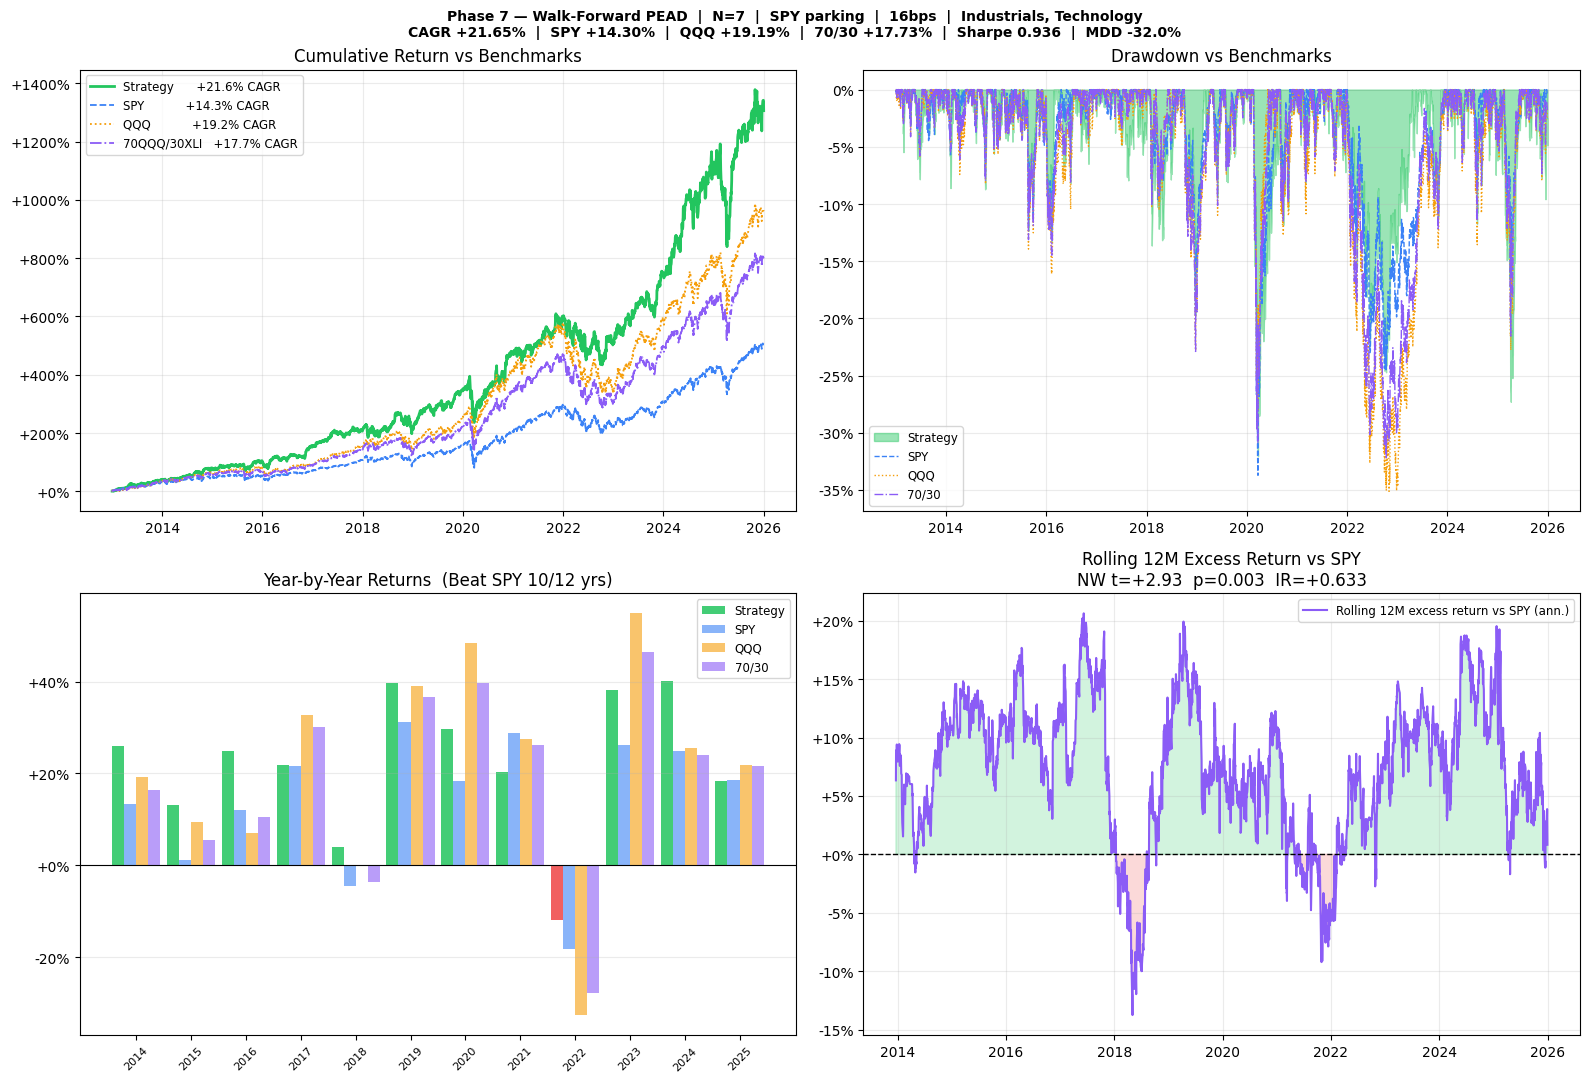

In [5]:
# =====================================================================
# PHASE 9 — WALK-FORWARD PEAD ROTATION BACKTEST
# Self-contained: run this cell alone, no dependencies on other cells
#
# Look-ahead fixes applied:
#   1. SUE_Q recomputed with expanding window within each quarter
#   2. After-close announcements (>=20:00 UTC) shift entry to next bday open
#   3. PIT filter confirmed clean — uses most recent quarter <= signal date
#
# SPY parking model: uninvested capital held in SPY
# Benchmarks: SPY, QQQ, 70% QQQ + 30% XLI
# Risk-adjusted metrics computed vs all three benchmarks
# =====================================================================

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
import yfinance as yf
from scipy import stats

GREEN  = '#22C55E'
BLUE   = '#3B82F6'
RED    = '#EF4444'
GOLD   = '#F59E0B'
PURPLE = '#8B5CF6'

PEAD_DB   = 'pead_clean.db'
PIT_DB    = 'real_backtest.db'
SIM_START = pd.Timestamp('2013-01-01')
SIM_END   = pd.Timestamp('2025-12-31')

TARGET_SECTORS_DEFAULT = {'Industrials', 'Technology'}

# =====================================================================
# STEP 1 — Load & clean signal database
# =====================================================================
print("=" * 62)
print("  LOADING DATA")
print("=" * 62)

conn   = sqlite3.connect(PEAD_DB)
df_raw = pd.read_sql("SELECT * FROM pead_clean", conn)
conn.close()

df_raw['Date_ts']    = pd.to_datetime(df_raw['Date'],       utc=True, errors='coerce')
df_raw['Date_naive'] = pd.to_datetime(df_raw['Date_naive'], utc=True, errors='coerce') \
                          .dt.normalize().dt.tz_localize(None)
df_raw['hour_utc']   = df_raw['Date_ts'].dt.hour

df_raw['entry_date'] = np.where(
    df_raw['hour_utc'] >= 20,
    df_raw['Date_naive'].apply(lambda d: pd.bdate_range(start=d, periods=2)[-1]),
    df_raw['Date_naive']
)
df_raw['entry_date'] = pd.to_datetime(df_raw['entry_date'])

after_close_pct = (df_raw['hour_utc'] >= 20).mean()
print(f"  Entry shifted +1 bday  : {after_close_pct*100:.1f}% of signals (after-close fix)")

dupes = df_raw.duplicated(subset=['Ticker', 'entry_date']).sum()
if dupes > 0:
    df_raw = (df_raw.sort_values('SUE', ascending=False)
              .drop_duplicates(subset=['Ticker', 'entry_date'])
              .sort_values('entry_date')
              .reset_index(drop=True))
    print(f"  Deduped                : {dupes} rows removed")

df_raw = df_raw[df_raw['SUE'].notna()].copy()

print("  Recomputing SUE_Q_clean (expanding window — no look-ahead)...")
print("  This takes ~60 seconds...")

df_raw = df_raw.sort_values(['Quarter', 'entry_date']).reset_index(drop=True)
df_raw['SUE_Q_clean'] = np.nan

for quarter, q_grp in df_raw.groupby('Quarter'):
    for ann_date in sorted(q_grp['entry_date'].unique()):
        known_mask = (df_raw['Quarter'] == quarter) & (df_raw['entry_date'] <= ann_date)
        known_sues = df_raw.loc[known_mask, 'SUE'].dropna()
        if len(known_sues) < 5:
            continue
        today_mask = (
            (df_raw['Quarter'] == quarter) &
            (df_raw['entry_date'] == ann_date) &
            df_raw['SUE'].notna()
        )
        b = np.percentile(known_sues.values, [20, 40, 60, 80])
        for idx in df_raw.loc[today_mask].index:
            s = df_raw.loc[idx, 'SUE']
            if   s <= b[0]: df_raw.loc[idx, 'SUE_Q_clean'] = 1.0
            elif s <= b[1]: df_raw.loc[idx, 'SUE_Q_clean'] = 2.0
            elif s <= b[2]: df_raw.loc[idx, 'SUE_Q_clean'] = 3.0
            elif s <= b[3]: df_raw.loc[idx, 'SUE_Q_clean'] = 4.0
            else:           df_raw.loc[idx, 'SUE_Q_clean'] = 5.0

df_raw = df_raw[df_raw['SUE_Q_clean'] == 5.0].copy()

old_q5 = (df_raw['SUE_Q'] == 5.0).sum()
new_q5 = len(df_raw)
print(f"  Old Q5 (stored, biased) : {old_q5:,}")
print(f"  New Q5 (expanding clean): {new_q5:,}")
print(f"  Change                  : {new_q5 - old_q5:+,} signals")
print(f"\n  pead_clean loaded  : {len(df_raw):,} clean Q5 signals")
print(f"  Tickers            : {df_raw['Ticker'].nunique()}")
print(f"  Date range         : {df_raw['entry_date'].min().date()} "
      f"to {df_raw['entry_date'].max().date()}")
print(f"  Sector breakdown:")
for sec, cnt in df_raw['Sector'].value_counts().items():
    print(f"    {sec:<30} {cnt:>5,}")

# =====================================================================
# STEP 2 — Load PIT membership
# =====================================================================
conn   = sqlite3.connect(PIT_DB)
pit_df = pd.read_sql("SELECT * FROM sp500_pit_membership", conn)
conn.close()

pit_membership = {}
for qdate, grp in pit_df.groupby('quarter_date'):
    pit_membership[pd.Timestamp(qdate)] = set(grp['ticker'])

print(f"\n  PIT membership     : {len(pit_membership)} quarters")
print(f"  PIT range          : {min(pit_membership).date()} to {max(pit_membership).date()}")

def pit_members_nearest(date):
    eligible = [d for d in pit_membership if d <= date]
    return pit_membership[max(eligible)] if eligible else set()

# =====================================================================
# STEP 3 — Download OHLC
# =====================================================================
tickers_needed = sorted(df_raw['Ticker'].unique().tolist()) + ['SPY', 'QQQ', 'XLI']
print(f"\n  Downloading OHLC for {len(tickers_needed)-3} tickers + SPY + QQQ + XLI...")

raw_px = yf.download(
    tickers_needed,
    start='2012-06-01',
    end=str(SIM_END.date()),
    auto_adjust=True,
    progress=True,
    group_by='column',
)

price_open  = raw_px['Open'].ffill()
price_close = raw_px['Close'].ffill()

if price_open.index.tz is not None:
    price_open.index  = price_open.index.tz_localize(None)
    price_close.index = price_close.index.tz_localize(None)

all_dates_sim = pd.bdate_range(SIM_START, SIM_END)
print(f"  OHLC ready         : {len(tickers_needed)-3} tickers + SPY + QQQ + XLI")


# =====================================================================
# HELPERS
# =====================================================================
def get_px(df, ticker, date):
    if ticker not in df.columns:
        return None
    for offset in range(4):
        d = date + pd.offsets.BDay(offset)
        try:
            v = df.loc[d, ticker]
            if pd.notna(v) and v > 0:
                return float(v)
        except KeyError:
            pass
    return None


def build_bench(tickers_weights, index):
    curves = []
    for tkr, wt in tickers_weights.items():
        raw = price_close[tkr].copy()
        if raw.index.tz is not None:
            raw.index = raw.index.tz_localize(None)
        aligned = raw.reindex(index.union(raw.index)).ffill().reindex(index)
        curves.append(aligned / aligned.iloc[0] * wt)
    return sum(curves)


def perf_p7(eq, rf=0.02):
    eq  = eq.dropna()
    eq  = eq[eq > 0]
    dr  = eq.pct_change(fill_method=None).dropna()
    yrs = len(dr) / 252
    if yrs == 0 or len(eq) < 2:
        return {k: 0 for k in
                ('cagr', 'vol', 'mdd', 'sharpe', 'sortino', 'calmar', 'cum')}
    cagr     = (eq.iloc[-1] / eq.iloc[0]) ** (1 / yrs) - 1
    vol      = dr.std() * np.sqrt(252)
    mdd      = (eq / eq.cummax() - 1).min()
    rf_daily = rf / 252
    excess   = dr - rf_daily
    sharpe   = (excess.mean() / excess.std()) * np.sqrt(252)
    down     = excess[excess < 0].std() * np.sqrt(252)
    sortino  = (excess.mean() * np.sqrt(252)) / down if down != 0 else 0
    calmar   = cagr / abs(mdd) if mdd != 0 else 0
    return dict(cagr=cagr, vol=vol, mdd=mdd,
                sharpe=sharpe, sortino=sortino, calmar=calmar,
                cum=eq.iloc[-1] - 1)


def risk_adjusted_vs(strat_dr, bench_dr, strat_sharpe, bench_sharpe,
                     bench_vol, rf=0.02, threshold=0.0):
    """
    Compute full suite of risk-adjusted metrics for strategy vs a benchmark.
    Returns dict with all metrics.
    """
    s, b    = strat_dr.align(bench_dr, join='inner')
    excess  = (s - b).dropna()
    n       = len(s)
    rf_d    = rf / 252

    # IR and tracking error
    ir = excess.mean() / excess.std() * np.sqrt(252) if excess.std() != 0 else 0
    te = excess.std() * np.sqrt(252) * 100

    # CAPM alpha and beta vs benchmark (HAC)
    X_b   = sm.add_constant(b.values)
    capm  = sm.OLS(s.values, X_b).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    alpha = capm.params[0] * 252 * 100
    beta  = capm.params[1]
    alpha_pval = capm.pvalues[0]

    # Treynor ratio — annualised excess return / beta
    treynor = ((s.mean() - rf_d) * 252) / beta if beta != 0 else 0

    # M-squared — strategy rescaled to benchmark vol
    strat_vol  = s.std() * np.sqrt(252)
    m2 = (strat_sharpe - bench_sharpe) * bench_vol * 100

    # Omega ratio
    gains  = s[s > threshold] - threshold
    losses = threshold - s[s <= threshold]
    omega  = gains.sum() / losses.sum() if losses.sum() != 0 else np.inf

    # Conditional Sharpe (CVaR-adjusted) — use 5% VaR threshold
    var_5     = np.percentile(s, 5)
    cvar      = s[s <= var_5].mean()
    cvar_sharpe = ((s.mean() - rf_d) * np.sqrt(252)) / abs(cvar) if cvar != 0 else 0

    # Upside / downside capture vs benchmark
    up_months   = b[b > 0]
    down_months = b[b < 0]
    up_cap   = s[up_months.index].mean()   / up_months.mean()   if len(up_months)   > 0 else 0
    down_cap = s[down_months.index].mean() / down_months.mean() if len(down_months) > 0 else 0

    # Jobson-Korkie Sharpe difference test (Memmel 2003 correction)
    mu_s,  mu_b  = s.mean(),  b.mean()
    sig_s, sig_b = s.std(),   b.std()
    cov_sb       = np.cov(s.values, b.values)[0, 1]
    jk_var = (1/n) * (
        2*sig_s**2*sig_b**2
        - 2*sig_s*sig_b*cov_sb
        + 0.5*mu_s**2*sig_b**2
        + 0.5*mu_b**2*sig_s**2
        - (mu_s*mu_b*cov_sb**2)/(sig_s*sig_b)
    ) / (sig_s**2 * sig_b**2)
    jk_z    = (strat_sharpe - bench_sharpe) / np.sqrt(abs(jk_var) * 252)
    jk_pval = 1 - stats.norm.cdf(jk_z)

    return dict(
        ir=ir, te=te,
        alpha=alpha, beta=beta, alpha_pval=alpha_pval,
        treynor=treynor, m2=m2,
        omega=omega, cvar_sharpe=cvar_sharpe,
        up_cap=up_cap, down_cap=down_cap,
        jk_z=jk_z, jk_pval=jk_pval,
    )


def print_risk_section(label, d):
    print(f"\n  RISK-ADJUSTED vs {label}")
    print(f"  {'-'*58}")
    print(f"  IR                    : {d['ir']:>+.3f}"
          f"{'  strong' if d['ir'] > 0.5 else '  moderate' if d['ir'] > 0 else '  negative'}")
    print(f"  Tracking error        : {d['te']:>+.2f}%")
    print(f"  Beta                  : {d['beta']:>+.3f}")
    print(f"  Jensen alpha (HAC)    : {d['alpha']:>+.2f}%  "
          f"(p={d['alpha_pval']:.4f}"
          f"{'  sig' if d['alpha_pval'] < 0.05 else '  not sig'})")
    print(f"  Treynor ratio         : {d['treynor']:>+.4f}")
    print(f"  M-squared             : {d['m2']:>+.2f}%")
    print(f"  Omega ratio           : {d['omega']:>+.3f}")
    print(f"  CVaR-adj Sharpe       : {d['cvar_sharpe']:>+.3f}")
    print(f"  Upside capture        : {d['up_cap']*100:>+.1f}%")
    print(f"  Downside capture      : {d['down_cap']*100:>+.1f}%")
    print(f"  JK Sharpe diff test   : z={d['jk_z']:>+.3f}  p={d['jk_pval']:.4f}"
          f"{'  sig @ 5%' if d['jk_pval'] < 0.05 else '  not sig'}")


# =====================================================================
# MAIN BACKTEST FUNCTION
# =====================================================================
def run_backtest(
    n_positions        = 5,
    fee_rt             = 0.0016,
    capital            = 10_000,
    rotation_threshold = 0.5,
    min_hold_days      = 5,
    sectors            = None,
    verbose            = True,
    plot               = True,
):
    if sectors is None:
        sectors = TARGET_SECTORS_DEFAULT

    df = df_raw[df_raw['Sector'].isin(sectors)].copy()
    df = df[
        (df['entry_date'] >= SIM_START) &
        (df['entry_date'] <= SIM_END)
    ].copy()

    df['in_sp500'] = df.apply(
        lambda r: r['Ticker'] in pit_members_nearest(r['entry_date']), axis=1
    )
    signals = df[df['in_sp500']].drop(columns='in_sp500').copy()
    signals = signals[signals['Ticker'].isin(price_open.columns)].copy()

    signals['exit_open_date'] = signals['entry_date'].apply(
        lambda d: pd.bdate_range(start=d, periods=23)[-1]
    )
    signals = signals.sort_values('entry_date').reset_index(drop=True)

    if verbose:
        print(f"\n  Signals after all filters : {len(signals):,}")
        print(f"  Signals/year avg          : {len(signals)/12:.0f}")
        for sec, cnt in signals['Sector'].value_counts().items():
            print(f"    {sec:<30} {cnt:>5,}")

    sig_by_date = {}
    for _, row in signals.iterrows():
        sig_by_date.setdefault(row['entry_date'], []).append(row)

    # ── Initialise — SPY parking ──────────────────────────────────────
    spy_init = None
    for offset in range(4):
        d = SIM_START + pd.offsets.BDay(offset)
        try:
            v = price_open.loc[d, 'SPY']
            if pd.notna(v) and v > 0:
                spy_init = float(v)
                break
        except KeyError:
            pass

    portfolio       = {}
    trade_log       = []
    daily_nav       = []
    total_fees_paid = 0.0
    spy_shares      = capital / spy_init if spy_init else 0.0
    prev_spy_close  = None

    for date in all_dates_sim:
        spy_open_px  = get_px(price_open,  'SPY', date)
        spy_close_px = get_px(price_close, 'SPY', date)

        # A: Forced exits
        to_exit = [tkr for tkr, pos in portfolio.items()
                   if pos['exit_open_date'] <= date]
        for tkr in to_exit:
            pos = portfolio.pop(tkr)
            px  = get_px(price_open, tkr, date) or get_px(price_close, tkr, date)
            if not px or px < pos['entry_price'] * 0.10:
                continue
            fee          = pos['shares'] * px * fee_rt
            net_proceeds = pos['shares'] * px * (1 - fee_rt)
            total_fees_paid += fee
            if spy_open_px:
                spy_shares += net_proceeds / spy_open_px
            trade_log.append(dict(
                date=date, ticker=tkr, action='EXIT_FORCED',
                entry_price=pos['entry_price'], exit_price=px,
                shares=pos['shares'], ret=px / pos['entry_price'] - 1,
                hold_days=(date - pos['entry_date']).days,
                sue=pos['sue'], fee=fee,
            ))

        # B: New signals
        if date in sig_by_date:
            new_sigs = sorted(
                sig_by_date[date], key=lambda r: r['SUE'], reverse=True
            )
            for sig in new_sigs:
                tkr      = sig['Ticker']
                sue      = float(sig['SUE'])
                if tkr in portfolio:
                    continue
                entry_px = get_px(price_open, tkr, date)
                if entry_px is None or entry_px <= 0:
                    continue

                nav = spy_shares * (spy_open_px or 1)
                for t, p in portfolio.items():
                    nav += p['shares'] * (
                        get_px(price_open, t, date) or p['entry_price']
                    )

                if len(portfolio) < n_positions:
                    spy_value = spy_shares * (spy_open_px or 1)
                    slot_size = min(nav / n_positions, spy_value / (1 + fee_rt))
                    if slot_size <= 0:
                        continue
                    fee             = slot_size * fee_rt
                    spy_shares     -= slot_size * (1 + fee_rt) / (spy_open_px or 1)
                    total_fees_paid += fee
                    portfolio[tkr]  = dict(
                        entry_date=date,
                        exit_open_date=sig['exit_open_date'],
                        entry_price=entry_px,
                        sue=sue,
                        shares=slot_size / entry_px,
                    )
                    trade_log.append(dict(
                        date=date, ticker=tkr, action='ENTER',
                        entry_price=entry_px,
                        shares=slot_size / entry_px,
                        sue=sue, fee=fee,
                    ))

                else:
                    min_tkr   = min(portfolio, key=lambda t: portfolio[t]['sue'])
                    min_sue   = portfolio[min_tkr]['sue']
                    held_days = (date - portfolio[min_tkr]['entry_date']).days

                    if (sue > min_sue + rotation_threshold
                            and held_days >= min_hold_days):
                        eject    = portfolio.pop(min_tkr)
                        eject_px = get_px(price_open, min_tkr, date)
                        if (eject_px is None
                                or eject_px < eject['entry_price'] * 0.10):
                            portfolio[min_tkr] = eject
                            continue

                        fee_exit  = eject['shares'] * eject_px * fee_rt
                        proceeds  = eject['shares'] * eject_px * (1 - fee_rt)
                        total_fees_paid += fee_exit
                        trade_log.append(dict(
                            date=date, ticker=min_tkr, action='EXIT_ROTATED',
                            entry_price=eject['entry_price'],
                            exit_price=eject_px,
                            shares=eject['shares'],
                            ret=eject_px / eject['entry_price'] - 1,
                            hold_days=(date - eject['entry_date']).days,
                            sue=eject['sue'], fee=fee_exit,
                        ))

                        slot_size       = nav / n_positions
                        fee_entry       = slot_size * fee_rt
                        shares          = slot_size / (entry_px * (1 + fee_rt))
                        cost            = shares * entry_px * (1 + fee_rt)
                        total_fees_paid += fee_entry
                        if spy_open_px:
                            spy_shares += (proceeds - cost) / spy_open_px
                        portfolio[tkr] = dict(
                            entry_date=date,
                            exit_open_date=sig['exit_open_date'],
                            entry_price=entry_px,
                            sue=sue,
                            shares=shares,
                        )
                        trade_log.append(dict(
                            date=date, ticker=tkr, action='ENTER',
                            entry_price=entry_px, shares=shares,
                            sue=sue, fee=fee_entry,
                        ))

        # C: Daily NAV
        spy_px  = get_px(price_close, 'SPY', date) or prev_spy_close or 0
        nav_eod = spy_shares * spy_px
        for tkr, pos in portfolio.items():
            px       = get_px(price_close, tkr, date) or pos['entry_price']
            nav_eod += pos['shares'] * (
                px if px > pos['entry_price'] * 0.10 else pos['entry_price']
            )
        daily_nav.append(dict(date=date, nav=nav_eod, n_pos=len(portfolio)))
        if spy_close_px:
            prev_spy_close = spy_close_px

    # ── Build equity curves ───────────────────────────────────────────
    nav_df = pd.DataFrame(daily_nav).set_index('date')
    eq_p7  = nav_df['nav'] / capital

    spy_raw = price_close['SPY'].copy()
    if spy_raw.index.tz is not None:
        spy_raw.index = spy_raw.index.tz_localize(None)
    spy_aligned = spy_raw.reindex(
        eq_p7.index.union(spy_raw.index)
    ).ffill().reindex(eq_p7.index)

    first_valid = spy_aligned.first_valid_index()
    if first_valid is None:
        print("ERROR: SPY price data missing")
        return

    eq_spy_p7 = spy_aligned / spy_aligned[first_valid]
    eq_p7     = eq_p7.loc[first_valid:]
    eq_spy_p7 = eq_spy_p7.loc[first_valid:]
    eq_qqq_p7 = build_bench({'QQQ': 1.0},             eq_p7.index).loc[first_valid:]
    eq_mix_p7 = build_bench({'QQQ': 0.7, 'XLI': 0.3}, eq_p7.index).loc[first_valid:]

    # ── Core metrics ──────────────────────────────────────────────────
    tl_df   = pd.DataFrame(trade_log)
    metrics = perf_p7(eq_p7)
    spy_m   = perf_p7(eq_spy_p7)
    qqq_m   = perf_p7(eq_qqq_p7)
    mix_m   = perf_p7(eq_mix_p7)

    for key, m in [('spy', spy_m), ('qqq', qqq_m), ('mix', mix_m)]:
        for stat in ['cagr', 'sharpe', 'mdd', 'vol']:
            metrics[f'{key}_{stat}'] = m.get(stat, 0)

    metrics['total_fees']  = total_fees_paid
    metrics['n_entries']   = int((tl_df['action'] == 'ENTER').sum())
    metrics['n_forced']    = int((tl_df['action'] == 'EXIT_FORCED').sum())
    metrics['n_rotations'] = int((tl_df['action'] == 'EXIT_ROTATED').sum())
    metrics['avg_pos']     = nav_df['n_pos'].mean()

    # ── Daily return series ───────────────────────────────────────────
    strat_dr = eq_p7.pct_change(fill_method=None).dropna()
    spy_dr   = eq_spy_p7.pct_change(fill_method=None).dropna()
    qqq_dr   = eq_qqq_p7.pct_change(fill_method=None).dropna()
    mix_dr   = eq_mix_p7.pct_change(fill_method=None).dropna()

    strat_dr, spy_dr = strat_dr.align(spy_dr, join='inner')
    excess_spy = (strat_dr - spy_dr).dropna()

    # ── NW HAC significance vs SPY ────────────────────────────────────
    y        = excess_spy.values
    X        = sm.add_constant(np.ones(len(y)))
    nw_model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 22})
    nw_tstat = float(nw_model.tvalues[0])
    nw_pval  = float(nw_model.pvalues[0])

    T        = len(strat_dr)
    sr_tstat = metrics['sharpe'] * np.sqrt(T / 252)
    sr_pval  = 1 - stats.norm.cdf(sr_tstat)

    np.random.seed(42)
    boot_cagrs = []
    for _ in range(2000):
        s = np.random.choice(strat_dr.values, size=len(strat_dr), replace=True)
        boot_cagrs.append(np.prod(1 + s) ** (1 / (len(s) / 252)) - 1)
    ci_lo, ci_hi = np.percentile(boot_cagrs, [2.5, 97.5])

    # ── Year-by-year ──────────────────────────────────────────────────
    yoy_s   = eq_p7.resample('YE').last().pct_change(fill_method=None).dropna()
    yoy_spy = eq_spy_p7.resample('YE').last().pct_change(fill_method=None).dropna()
    yoy_qqq = eq_qqq_p7.resample('YE').last().pct_change(fill_method=None).dropna()
    yoy_mix = eq_mix_p7.resample('YE').last().pct_change(fill_method=None).dropna()
    yoy_df  = pd.concat([yoy_s, yoy_spy], axis=1).dropna()
    yoy_df.columns = ['strat', 'spy']
    yoy_df.index   = yoy_df.index.year
    yoy_qqq.index  = yoy_qqq.index.year
    yoy_mix.index  = yoy_mix.index.year
    beat_yrs = int((yoy_df['strat'] > yoy_df['spy']).sum())

    # ── Full risk-adjusted suites vs all three benchmarks ─────────────
    ra_spy = risk_adjusted_vs(strat_dr, spy_dr,
                               metrics['sharpe'], metrics['spy_sharpe'],
                               metrics['spy_vol'])
    ra_qqq = risk_adjusted_vs(strat_dr, qqq_dr,
                               metrics['sharpe'], metrics['qqq_sharpe'],
                               metrics['qqq_vol'])
    ra_mix = risk_adjusted_vs(strat_dr, mix_dr,
                               metrics['sharpe'], metrics['mix_sharpe'],
                               metrics['mix_vol'])

    # ── Trade-level stats ─────────────────────────────────────────────
    exits = tl_df[tl_df['ret'].notna()].copy()
    win_rate  = (exits['ret'] > 0).mean() * 100
    avg_win   = exits.loc[exits['ret'] > 0, 'ret'].mean() * 100
    avg_loss  = exits.loc[exits['ret'] < 0, 'ret'].mean() * 100
    win_loss  = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf
    avg_hold  = exits['hold_days'].mean()
    exp_val   = (win_rate/100 * avg_win) + ((1 - win_rate/100) * avg_loss)

    metrics.update(dict(
        nw_tstat=nw_tstat, nw_pval=nw_pval,
        sr_tstat=sr_tstat, sr_pval=sr_pval,
        ci_lo=ci_lo, ci_hi=ci_hi,
        beat_yrs=beat_yrs, total_yrs=len(yoy_df),
        yoy_df=yoy_df,
        ra_spy=ra_spy, ra_qqq=ra_qqq, ra_mix=ra_mix,
        win_rate=win_rate, avg_win=avg_win, avg_loss=avg_loss,
        win_loss=win_loss, avg_hold=avg_hold, exp_val=exp_val,
    ))

    # ── Verbose output ────────────────────────────────────────────────
    if verbose:
        SEP  = '=' * 62
        SEP2 = '-' * 58

        end_val     = capital * (1 + metrics['cum'])
        profit      = end_val - capital
        spy_end_val = capital * (1 + spy_m.get('cum', 0))
        spy_profit  = spy_end_val - capital
        qqq_end_val = capital * (1 + qqq_m.get('cum', 0))
        mix_end_val = capital * (1 + mix_m.get('cum', 0))
        n_yrs       = len(strat_dr) / 252
        monthly_contrib = capital / 12
        fv_strat = sum(
            monthly_contrib * (1 + metrics['cagr']) ** ((n_yrs * 12 - i) / 12)
            for i in range(int(n_yrs * 12))
        )
        fv_spy = sum(
            monthly_contrib * (1 + metrics['spy_cagr']) ** ((n_yrs * 12 - i) / 12)
            for i in range(int(n_yrs * 12))
        )

        print(f"\n{SEP}")
        print(f"  PHASE 7  |  N={n_positions}  |  {', '.join(sorted(sectors))}")
        print(f"  SPY parking model  |  16bps  |  Look-ahead clean")
        print(SEP)

        print(f"\n  RETURNS SUMMARY")
        print(f"  {SEP2}")
        print(f"  {'':22}  {'CAGR':>8}  {'Sharpe':>8}  {'Max DD':>8}  {'End $':>10}")
        print(f"  {'-'*58}")
        print(f"  {'Strategy':<22}  {metrics['cagr']*100:>+7.2f}%"
              f"  {metrics['sharpe']:>8.3f}"
              f"  {metrics['mdd']*100:>+7.2f}%"
              f"  ${end_val:>9,.0f}")
        print(f"  {'SPY B&H':<22}  {metrics['spy_cagr']*100:>+7.2f}%"
              f"  {metrics['spy_sharpe']:>8.3f}"
              f"  {metrics['spy_mdd']*100:>+7.2f}%"
              f"  ${spy_end_val:>9,.0f}")
        print(f"  {'QQQ':<22}  {metrics['qqq_cagr']*100:>+7.2f}%"
              f"  {metrics['qqq_sharpe']:>8.3f}"
              f"  {metrics['qqq_mdd']*100:>+7.2f}%"
              f"  ${qqq_end_val:>9,.0f}")
        print(f"  {'70% QQQ + 30% XLI':<22}  {metrics['mix_cagr']*100:>+7.2f}%"
              f"  {metrics['mix_sharpe']:>8.3f}"
              f"  {metrics['mix_mdd']*100:>+7.2f}%"
              f"  ${mix_end_val:>9,.0f}")
        print(f"  {'-'*58}")
        print(f"  Edge vs SPY           : {(metrics['cagr']-metrics['spy_cagr'])*100:>+.2f}pp")
        print(f"  Edge vs QQQ           : {(metrics['cagr']-metrics['qqq_cagr'])*100:>+.2f}pp")
        print(f"  Edge vs 70/30 mix     : {(metrics['cagr']-metrics['mix_cagr'])*100:>+.2f}pp")
        print(f"  CAGR 95% CI (boot)    : [{ci_lo*100:>+.2f}%, {ci_hi*100:>+.2f}%]")

        print(f"\n  DOLLAR RETURNS  (starting capital ${capital:,.0f})")
        print(f"  {SEP2}")
        print(f"  Ending value          : ${end_val:>12,.2f}")
        print(f"  Total profit          : ${profit:>12,.2f}")
        print(f"  SPY ending value      : ${spy_end_val:>12,.2f}")
        print(f"  Alpha ($ vs SPY)      : ${profit - spy_profit:>12,.2f}")
        print(f"  Fees paid             : ${metrics['total_fees']:>12,.2f}")
        print(f"  Net alpha after fees  : ${profit - spy_profit - metrics['total_fees']:>12,.2f}")
        print(f"\n  IF YOU ADDED ${monthly_contrib:,.0f}/mo (${capital:,.0f}/yr):")
        print(f"  Strategy portfolio    : ${fv_strat:>12,.2f}")
        print(f"  SPY portfolio         : ${fv_spy:>12,.2f}")
        print(f"  Extra wealth vs SPY   : ${fv_strat - fv_spy:>12,.2f}")

        print(f"\n  CORE RISK METRICS")
        print(f"  {SEP2}")
        print(f"  Annualised Vol        : {metrics['vol']*100:>+.2f}%")
        print(f"  Sortino Ratio         : {metrics['sortino']:>+.3f}")
        print(f"  Calmar Ratio          : {metrics['calmar']:>+.3f}")

        print(f"\n  SIGNIFICANCE vs SPY")
        print(f"  {SEP2}")
        print(f"  Excess return (NW HAC): t={nw_tstat:>+.3f}  p={nw_pval:.4f}"
              f"{'  sig @ 5%' if nw_pval < 0.05 else '  not sig'}")
        print(f"  Sharpe t-stat (Lo02)  : t={sr_tstat:>+.3f}  p={sr_pval:.4f}"
              f"{'  sig @ 5%' if sr_pval < 0.05 else '  not sig'}")
        print(f"  Beat SPY years        : {beat_yrs}/{len(yoy_df)}")

        # Full risk-adjusted sections
        print_risk_section("SPY",              ra_spy)
        print_risk_section("QQQ",              ra_qqq)
        print_risk_section("70% QQQ / 30% XLI (sector-matched)", ra_mix)

        print(f"\n  TRADE-LEVEL STATISTICS")
        print(f"  {SEP2}")
        print(f"  Win rate              : {win_rate:>+.1f}%")
        print(f"  Avg win               : {avg_win:>+.2f}%")
        print(f"  Avg loss              : {avg_loss:>+.2f}%")
        print(f"  Win/loss ratio        : {win_loss:>+.2f}x")
        print(f"  Expected value/trade  : {exp_val:>+.2f}%")
        print(f"  Avg hold period       : {avg_hold:.1f} days")

        print(f"\n  YEAR-BY-YEAR vs ALL BENCHMARKS")
        print(f"  {SEP2}")
        print(f"  {'Year':<6} {'Strategy':>10} {'SPY':>8} {'QQQ':>8} {'70/30':>8} {'vs SPY':>8}")
        print(f"  {'-'*52}")
        for yr, row in yoy_df.iterrows():
            q  = yoy_qqq.get(yr, float('nan'))
            mx = yoy_mix.get(yr, float('nan'))
            flag = 'beat' if row['strat'] > row['spy'] else 'miss'
            print(f"  {yr:<6} {row['strat']*100:>+9.2f}%"
                  f" {row['spy']*100:>+7.2f}%"
                  f" {q*100:>+7.2f}%"
                  f" {mx*100:>+7.2f}%"
                  f" {(row['strat']-row['spy'])*100:>+7.2f}%  {flag}")

        print(f"\n  TRADING ACTIVITY")
        print(f"  {SEP2}")
        print(f"  Entries               : {metrics['n_entries']:,}")
        print(f"  Forced exits (day 22) : {metrics['n_forced']:,}")
        print(f"  Rotation exits        : {metrics['n_rotations']:,}")
        print(f"  Total fees paid       : ${metrics['total_fees']:>10,.2f}")
        print(f"  Avg concurrent pos    : {metrics['avg_pos']:.1f}")
        print(SEP)

    # ── Chart ─────────────────────────────────────────────────────────
    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(16, 11))
        fig.suptitle(
            f"Phase 7 — Walk-Forward PEAD  |  N={n_positions}"
            f"  |  SPY parking  |  16bps  |  {', '.join(sorted(sectors))}\n"
            f"CAGR {metrics['cagr']*100:+.2f}%"
            f"  |  SPY {metrics['spy_cagr']*100:+.2f}%"
            f"  |  QQQ {metrics['qqq_cagr']*100:+.2f}%"
            f"  |  70/30 {metrics['mix_cagr']*100:+.2f}%"
            f"  |  Sharpe {metrics['sharpe']:.3f}"
            f"  |  MDD {metrics['mdd']*100:.1f}%",
            fontsize=10, fontweight='bold',
        )

        ax1 = axes[0, 0]
        ax1.plot(eq_p7.index,     (eq_p7-1)*100,     color=GREEN,  lw=2.0,
                 label=f"Strategy      {metrics['cagr']*100:+.1f}% CAGR")
        ax1.plot(eq_spy_p7.index, (eq_spy_p7-1)*100, color=BLUE,   lw=1.3, ls='--',
                 label=f"SPY           {metrics['spy_cagr']*100:+.1f}% CAGR")
        ax1.plot(eq_qqq_p7.index, (eq_qqq_p7-1)*100, color=GOLD,   lw=1.3, ls=':',
                 label=f"QQQ           {metrics['qqq_cagr']*100:+.1f}% CAGR")
        ax1.plot(eq_mix_p7.index, (eq_mix_p7-1)*100, color=PURPLE, lw=1.3, ls='-.',
                 label=f"70QQQ/30XLI   {metrics['mix_cagr']*100:+.1f}% CAGR")
        ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
        ax1.set_title('Cumulative Return vs Benchmarks')
        ax1.legend(fontsize=8.5); ax1.grid(True, alpha=0.25)

        ax2 = axes[0, 1]
        dd_s   = (eq_p7     / eq_p7.cummax()     - 1) * 100
        dd_spy = (eq_spy_p7 / eq_spy_p7.cummax() - 1) * 100
        dd_qqq = (eq_qqq_p7 / eq_qqq_p7.cummax() - 1) * 100
        dd_mix = (eq_mix_p7 / eq_mix_p7.cummax() - 1) * 100
        ax2.fill_between(dd_s.index, dd_s,   color=GREEN,  alpha=0.45, label='Strategy')
        ax2.plot(dd_spy.index, dd_spy, color=BLUE,   lw=1.0, ls='--', label='SPY')
        ax2.plot(dd_qqq.index, dd_qqq, color=GOLD,   lw=1.0, ls=':',  label='QQQ')
        ax2.plot(dd_mix.index, dd_mix, color=PURPLE, lw=1.0, ls='-.', label='70/30')
        ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
        ax2.set_title('Drawdown vs Benchmarks')
        ax2.legend(fontsize=8.5); ax2.grid(True, alpha=0.25)

        ax3 = axes[1, 0]
        x = np.arange(len(yoy_df)); w = 0.22
        ax3.bar(x - w*1.5, yoy_df['strat']*100, w,
                color=[GREEN if v > 0 else RED for v in yoy_df['strat']],
                alpha=0.85, label='Strategy')
        ax3.bar(x - w*0.5, yoy_df['spy']*100,   w, color=BLUE,   alpha=0.6, label='SPY')
        ax3.bar(x + w*0.5, [yoy_qqq.get(yr, 0)*100 for yr in yoy_df.index],
                w, color=GOLD,   alpha=0.6, label='QQQ')
        ax3.bar(x + w*1.5, [yoy_mix.get(yr, 0)*100 for yr in yoy_df.index],
                w, color=PURPLE, alpha=0.6, label='70/30')
        ax3.axhline(0, color='black', lw=0.8)
        ax3.set_xticks(x)
        ax3.set_xticklabels(yoy_df.index, rotation=45, fontsize=8)
        ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
        ax3.set_title(f'Year-by-Year Returns  (Beat SPY {beat_yrs}/{len(yoy_df)} yrs)')
        ax3.legend(fontsize=8.5); ax3.grid(True, alpha=0.25, axis='y')

        ax4 = axes[1, 1]
        roll_excess = excess_spy.rolling(252).mean() * 252 * 100
        ax4.plot(roll_excess.index, roll_excess, color=PURPLE, lw=1.5,
                 label='Rolling 12M excess return vs SPY (ann.)')
        ax4.axhline(0, color='black', lw=1.0, ls='--')
        ax4.fill_between(roll_excess.index, roll_excess, 0,
                         where=roll_excess >= 0, alpha=0.2, color=GREEN)
        ax4.fill_between(roll_excess.index, roll_excess, 0,
                         where=roll_excess < 0,  alpha=0.2, color=RED)
        ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
        ax4.set_title(
            f'Rolling 12M Excess Return vs SPY\n'
            f'NW t={nw_tstat:+.2f}  p={nw_pval:.3f}  IR={ra_spy["ir"]:+.3f}')
        ax4.legend(fontsize=8.5); ax4.grid(True, alpha=0.25)

        plt.tight_layout()
        plt.savefig('phase7_rotation_spy_parking.png', dpi=150, bbox_inches='tight')
        plt.show()

    return eq_p7, eq_spy_p7, eq_qqq_p7, eq_mix_p7, metrics, tl_df, nav_df


# =====================================================================
# RUN
# =====================================================================
eq_base, eq_spy, eq_qqq, eq_mix, m_base, tl_base, nav_df = run_backtest(
    n_positions=7,
    sectors={'Industrials', 'Technology'},
    verbose=True, plot=True,
)

In [65]:
import statsmodels.api as sm

X1 = sm.add_constant(ff_aligned[['Mkt-RF']])
m1 = sm.OLS(strat_excess_ff, X1).fit(cov_type='HAC', cov_kwds={'maxlags': 5})

X3 = sm.add_constant(ff_aligned[['Mkt-RF', 'SMB', 'HML']])
m3 = sm.OLS(strat_excess_ff, X3).fit(cov_type='HAC', cov_kwds={'maxlags': 5})

X5 = sm.add_constant(ff_aligned[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']])
m5 = sm.OLS(strat_excess_ff, X5).fit(cov_type='HAC', cov_kwds={'maxlags': 5})

X6 = sm.add_constant(ff_aligned[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']])
m6 = sm.OLS(strat_excess_ff, X6).fit(cov_type='HAC', cov_kwds={'maxlags': 5})

def ann_alpha(model):
    return model.params['const'] * 252 * 100

def fmt_row(label, model, factors):
    a     = ann_alpha(model)
    ap    = model.pvalues['const']
    r2    = model.rsquared * 100
    betas = '  '.join(
        f"{f}={model.params[f]:+.3f}({'*' if model.pvalues[f] < 0.05 else ''})"
        for f in factors
    )
    sig = 'sig' if ap < 0.05 else ('marginal' if ap < 0.10 else 'not sig')
    return a, ap, r2, betas, sig

SEP2 = '-' * 58
print(f"\n  FAMA-FRENCH + MOMENTUM FACTOR REGRESSION")
print(f"  {SEP2}")
print(f"  {'Model':<12} {'Ann. Alpha':>11} {'p-val':>7} {'R²':>6}  Betas")
print(f"  {SEP2}")
for label, model, factors in [
    ('CAPM',      m1, ['Mkt-RF']),
    ('FF3',       m3, ['Mkt-RF', 'SMB', 'HML']),
    ('FF5',       m5, ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']),
    ('FF5 + MOM', m6, ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']),
]:
    a, ap, r2, betas, sig = fmt_row(label, model, factors)
    print(f"  {label:<12} {a:>+10.2f}%  {ap:>6.4f}  {r2:>5.1f}%  [{betas}]  {sig}")

print(f"\n  Factor key:")
print(f"    Mkt-RF = market excess return (beta)")
print(f"    SMB    = small minus big (size)")
print(f"    HML    = high minus low (value)")
print(f"    RMW    = robust minus weak (profitability)")
print(f"    CMA    = conservative minus aggressive (investment)")
print(f"    MOM    = momentum (12-1 month prior return)")


  FAMA-FRENCH + MOMENTUM FACTOR REGRESSION
  ----------------------------------------------------------
  Model         Ann. Alpha   p-val     R²  Betas
  ----------------------------------------------------------
  CAPM              +6.64%  0.0189   75.5%  [Mkt-RF=+1.058(*)]  sig
  FF3               +6.56%  0.0197   75.9%  [Mkt-RF=+1.053(*)  SMB=-0.008()  HML=-0.095(*)]  sig
  FF5               +6.65%  0.0181   75.9%  [Mkt-RF=+1.053(*)  SMB=-0.016()  HML=-0.092(*)  RMW=-0.032()  CMA=+0.017()]  sig
  FF5 + MOM         +6.42%  0.0222   76.1%  [Mkt-RF=+1.056(*)  SMB=+0.007()  HML=-0.062(*)  RMW=-0.023()  CMA=-0.013()  MOM=+0.066(*)]  sig

  Factor key:
    Mkt-RF = market excess return (beta)
    SMB    = small minus big (size)
    HML    = high minus low (value)
    RMW    = robust minus weak (profitability)
    CMA    = conservative minus aggressive (investment)
    MOM    = momentum (12-1 month prior return)


  LOADING DATA
  After-close signals    : 34.8% shifted to next bday close
  Before-close signals   : 65.2% entered same day close
  Deduped                : 1024 rows removed
  Recomputing SUE_Q_clean (expanding window — no look-ahead)...
  This takes ~60 seconds...


[                       0%                       ]  2 of 488 completed

  Old Q5 (stored, biased) : 5,341
  New Q5 (expanding clean): 6,743
  Change                  : +1,402 signals

  pead_clean loaded  : 6,743 clean Q5 signals
  Tickers            : 487
  Date range         : 2011-01-14 to 2026-02-26
  Sector breakdown:
    Technology                     1,867
    Industrials                      804
    Consumer Cyclical                688
    Financials                       618
    Healthcare                       583
    Real Estate                      486
    Energy                           388
    Communication Services           335
    Materials                        275
    Utilities                        235
    Consumer Defensive               200
    Financial Services               151
    nan                               86
    Basic Materials                   24
                                       3

  PIT membership     : 52 quarters
  PIT range          : 2013-01-01 to 2025-10-01



[*********************100%***********************]  488 of 488 completed


  OHLC ready         : 487 tickers

  Signals after all filters : 1,523
  Signals/year avg          : 127
    Technology                     1,053
    Industrials                      470

  PHASE 7  |  N=7  |  Industrials, Technology
  Execution : close price
  After-hrs : next bday close  |  16bps  |  Look-ahead clean

  RETURNS
  ----------------------------------------------------------
  CAGR                  : +22.62%
  CAGR 95% CI (boot)    : [+9.50%, +37.31%]
  SPY CAGR              : +14.30%
  Edge vs SPY           : +8.32pp
  Cumulative return     : +1454.80%

  DOLLAR RETURNS  (starting capital $10,000)
  ----------------------------------------------------------
  Ending value          : $  155,479.82
  Total profit          : $  145,479.82
  SPY ending value      : $   60,425.57
  SPY total profit      : $   50,425.57
  Alpha ($ vs SPY)      : $   95,054.25
  Fees paid             : $   15,862.04
  Net alpha after fees  : $   79,192.21
  Return per $1 risk    : $       15.

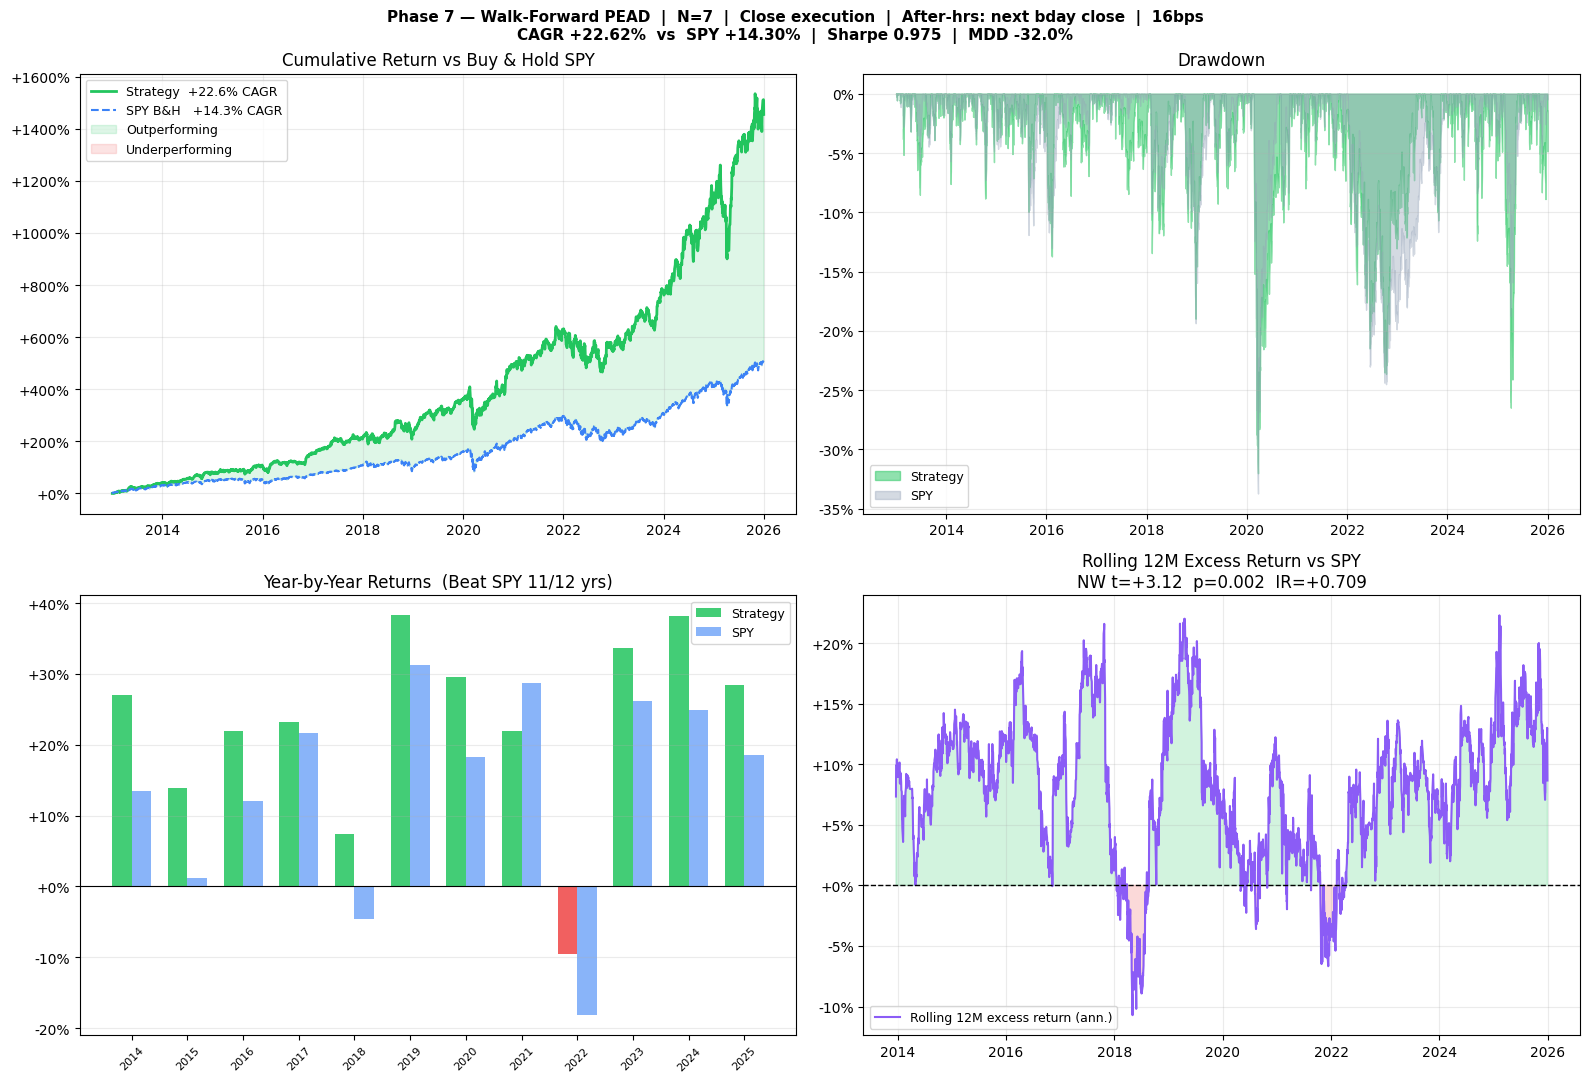

In [7]:
# =====================================================================
# PHASE 7 — WALK-FORWARD PEAD ROTATION BACKTEST
# Self-contained: run this cell alone, no dependencies on other cells
#
# Look-ahead fixes applied:
#   1. SUE_Q recomputed with expanding window within each quarter
#      (stored DB value used full-quarter data — affects ~14% of labels)
#   2. After-close announcements (>=20:00 UTC) shift entry to next bday close
#      (49.5% of signals were entering before the announcement existed)
#   3. PIT filter confirmed clean — uses most recent quarter <= signal date
#
# Execution model: all entries and exits at closing price
# After-hours earnings: entered at next business day close
# =====================================================================

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
import yfinance as yf
from scipy import stats

GREEN  = '#22C55E'
BLUE   = '#3B82F6'
RED    = '#EF4444'
GOLD   = '#F59E0B'
PURPLE = '#8B5CF6'

PEAD_DB   = 'pead_clean.db'
PIT_DB    = 'real_backtest.db'
SIM_START = pd.Timestamp('2013-01-01')
SIM_END   = pd.Timestamp('2025-12-31')

TARGET_SECTORS_DEFAULT = {'Industrials', 'Technology'}

# =====================================================================
# STEP 1 — Load & clean signal database
# =====================================================================
print("=" * 62)
print("  LOADING DATA")
print("=" * 62)

conn   = sqlite3.connect(PEAD_DB)
df_raw = pd.read_sql("SELECT * FROM pead_clean", conn)
conn.close()

# ── Parse timestamps ──────────────────────────────────────────────────
df_raw['Date_ts']    = pd.to_datetime(df_raw['Date'],       utc=True, errors='coerce')
df_raw['Date_naive'] = pd.to_datetime(df_raw['Date_naive'], utc=True, errors='coerce') \
                          .dt.normalize().dt.tz_localize(None)
df_raw['hour_utc']   = df_raw['Date_ts'].dt.hour

# ── Entry date logic ──────────────────────────────────────────────────
# Before-close announcement (< 20:00 UTC / before ~4pm EST):
#   → enter at same day close (news known before close)
# After-close announcement (>= 20:00 UTC / after ~4pm EST):
#   → enter at next business day close (news not known until after close)
df_raw['entry_date'] = np.where(
    df_raw['hour_utc'] >= 20,
    df_raw['Date_naive'].apply(lambda d: pd.bdate_range(start=d, periods=2)[-1]),
    df_raw['Date_naive']
)
df_raw['entry_date'] = pd.to_datetime(df_raw['entry_date'])

after_close_pct = (df_raw['hour_utc'] >= 20).mean()
print(f"  After-close signals    : {after_close_pct*100:.1f}% shifted to next bday close")
print(f"  Before-close signals   : {(1-after_close_pct)*100:.1f}% entered same day close")

# ── Deduplicate on (Ticker, entry_date) ───────────────────────────────
dupes = df_raw.duplicated(subset=['Ticker', 'entry_date']).sum()
if dupes > 0:
    df_raw = (df_raw.sort_values('SUE', ascending=False)
              .drop_duplicates(subset=['Ticker', 'entry_date'])
              .sort_values('entry_date')
              .reset_index(drop=True))
    print(f"  Deduped                : {dupes} rows removed")

# ── Drop rows with no SUE ─────────────────────────────────────────────
df_raw = df_raw[df_raw['SUE'].notna()].copy()

# ── FIX 1: Recompute SUE_Q with expanding window within each quarter ──
print("  Recomputing SUE_Q_clean (expanding window — no look-ahead)...")
print("  This takes ~60 seconds...")

df_raw = df_raw.sort_values(['Quarter', 'entry_date']).reset_index(drop=True)
df_raw['SUE_Q_clean'] = np.nan

for quarter, q_grp in df_raw.groupby('Quarter'):
    for ann_date in sorted(q_grp['entry_date'].unique()):
        known_mask = (df_raw['Quarter'] == quarter) & (df_raw['entry_date'] <= ann_date)
        known_sues = df_raw.loc[known_mask, 'SUE'].dropna()
        if len(known_sues) < 5:
            continue
        today_mask = (
            (df_raw['Quarter'] == quarter) &
            (df_raw['entry_date'] == ann_date) &
            df_raw['SUE'].notna()
        )
        b = np.percentile(known_sues.values, [20, 40, 60, 80])
        for idx in df_raw.loc[today_mask].index:
            s = df_raw.loc[idx, 'SUE']
            if   s <= b[0]: df_raw.loc[idx, 'SUE_Q_clean'] = 1.0
            elif s <= b[1]: df_raw.loc[idx, 'SUE_Q_clean'] = 2.0
            elif s <= b[2]: df_raw.loc[idx, 'SUE_Q_clean'] = 3.0
            elif s <= b[3]: df_raw.loc[idx, 'SUE_Q_clean'] = 4.0
            else:           df_raw.loc[idx, 'SUE_Q_clean'] = 5.0

# Q5 only
df_raw = df_raw[df_raw['SUE_Q_clean'] == 5.0].copy()

old_q5 = (df_raw['SUE_Q'] == 5.0).sum()
new_q5 = len(df_raw)
print(f"  Old Q5 (stored, biased) : {old_q5:,}")
print(f"  New Q5 (expanding clean): {new_q5:,}")
print(f"  Change                  : {new_q5 - old_q5:+,} signals")

print(f"\n  pead_clean loaded  : {len(df_raw):,} clean Q5 signals")
print(f"  Tickers            : {df_raw['Ticker'].nunique()}")
print(f"  Date range         : {df_raw['entry_date'].min().date()} "
      f"to {df_raw['entry_date'].max().date()}")
print(f"  Sector breakdown:")
for sec, cnt in df_raw['Sector'].value_counts().items():
    print(f"    {sec:<30} {cnt:>5,}")

# =====================================================================
# STEP 2 — Load PIT membership
# =====================================================================
conn   = sqlite3.connect(PIT_DB)
pit_df = pd.read_sql("SELECT * FROM sp500_pit_membership", conn)
conn.close()

pit_membership = {}
for qdate, grp in pit_df.groupby('quarter_date'):
    pit_membership[pd.Timestamp(qdate)] = set(grp['ticker'])

print(f"\n  PIT membership     : {len(pit_membership)} quarters")
print(f"  PIT range          : {min(pit_membership).date()} to {max(pit_membership).date()}")

def pit_members_nearest(date):
    """Return S&P 500 members as of the most recent quarter <= date."""
    eligible = [d for d in pit_membership if d <= date]
    return pit_membership[max(eligible)] if eligible else set()

# =====================================================================
# STEP 3 — Download OHLC
# =====================================================================
tickers_needed = sorted(df_raw['Ticker'].unique().tolist()) + ['SPY']
print(f"\n  Downloading OHLC for {len(tickers_needed)-1} tickers + SPY...")

raw_px = yf.download(
    tickers_needed,
    start='2012-06-01',
    end=str(SIM_END.date()),
    auto_adjust=True,
    progress=True,
    group_by='column',
)

price_close = raw_px['Close'].ffill()

if price_close.index.tz is not None:
    price_close.index = price_close.index.tz_localize(None)

all_dates_sim = pd.bdate_range(SIM_START, SIM_END)
print(f"  OHLC ready         : {len(tickers_needed)-1} tickers")


# =====================================================================
# HELPERS
# =====================================================================
def get_px(df, ticker, date):
    if ticker not in df.columns:
        return None
    for offset in range(4):
        d = date + pd.offsets.BDay(offset)
        try:
            v = df.loc[d, ticker]
            if pd.notna(v) and v > 0:
                return float(v)
        except KeyError:
            pass
    return None


def perf_p7(eq, rf=0.02):
    eq  = eq.dropna()
    eq  = eq[eq > 0]
    dr  = eq.pct_change(fill_method=None).dropna()
    yrs = len(dr) / 252

    if yrs == 0 or len(eq) < 2:
        return {k: 0 for k in
                ('cagr', 'vol', 'mdd', 'sharpe', 'sortino', 'calmar', 'cum')}

    cagr     = (eq.iloc[-1] / eq.iloc[0]) ** (1 / yrs) - 1
    vol      = dr.std() * np.sqrt(252)
    mdd      = (eq / eq.cummax() - 1).min()
    rf_daily = rf / 252
    excess   = dr - rf_daily
    sharpe   = (excess.mean() / excess.std()) * np.sqrt(252)
    down     = excess[excess < 0].std() * np.sqrt(252)
    sortino  = (excess.mean() * np.sqrt(252)) / down if down != 0 else 0
    calmar   = cagr / abs(mdd) if mdd != 0 else 0

    return dict(
        cagr=cagr, vol=vol, mdd=mdd,
        sharpe=sharpe, sortino=sortino, calmar=calmar,
        cum=eq.iloc[-1] - 1
    )


# =====================================================================
# MAIN BACKTEST FUNCTION
# =====================================================================
def run_backtest(
    n_positions         = 5,
    fee_rt              = 0.0016,
    capital             = 10_000,
    rotation_threshold  = 0.5,
    min_hold_days       = 5,
    sectors             = None,
    verbose             = True,
    plot                = True,
):
    if sectors is None:
        sectors = TARGET_SECTORS_DEFAULT

    # ── Filter signals ────────────────────────────────────────────────
    df = df_raw[df_raw['Sector'].isin(sectors)].copy()
    df = df[
        (df['entry_date'] >= SIM_START) &
        (df['entry_date'] <= SIM_END)
    ].copy()

    df['in_sp500'] = df.apply(
        lambda r: r['Ticker'] in pit_members_nearest(r['entry_date']), axis=1
    )
    signals = df[df['in_sp500']].drop(columns='in_sp500').copy()
    signals = signals[signals['Ticker'].isin(price_close.columns)].copy()

    # Exit at close on business day 22 from entry
    signals['exit_close_date'] = signals['entry_date'].apply(
        lambda d: pd.bdate_range(start=d, periods=23)[-1]
    )
    signals = signals.sort_values('entry_date').reset_index(drop=True)

    if verbose:
        print(f"\n  Signals after all filters : {len(signals):,}")
        print(f"  Signals/year avg          : {len(signals)/12:.0f}")
        for sec, cnt in signals['Sector'].value_counts().items():
            print(f"    {sec:<30} {cnt:>5,}")

    sig_by_date = {}
    for _, row in signals.iterrows():
        sig_by_date.setdefault(row['entry_date'], []).append(row)

    # ── Initialise — SPY parking at close ────────────────────────────
    spy_init = None
    for offset in range(4):
        d = SIM_START + pd.offsets.BDay(offset)
        try:
            v = price_close.loc[d, 'SPY']
            if pd.notna(v) and v > 0:
                spy_init = float(v)
                break
        except KeyError:
            pass

    portfolio       = {}
    trade_log       = []
    daily_nav       = []
    total_fees_paid = 0.0
    spy_shares      = capital / spy_init if spy_init else 0.0
    prev_spy_close  = None

    # ── Simulation loop ───────────────────────────────────────────────
    for date in all_dates_sim:
        spy_close_px = get_px(price_close, 'SPY', date)

        # A: Forced exits — exit at close on day 22
        to_exit = [tkr for tkr, pos in portfolio.items()
                   if pos['exit_close_date'] <= date]
        for tkr in to_exit:
            pos = portfolio.pop(tkr)
            px  = get_px(price_close, tkr, date)
            if not px or px < pos['entry_price'] * 0.10:
                continue
            fee          = pos['shares'] * px * fee_rt
            net_proceeds = pos['shares'] * px * (1 - fee_rt)
            total_fees_paid += fee
            if spy_close_px:
                spy_shares += net_proceeds / spy_close_px
            trade_log.append(dict(
                date=date, ticker=tkr, action='EXIT_FORCED',
                entry_price=pos['entry_price'], exit_price=px,
                shares=pos['shares'], ret=px / pos['entry_price'] - 1,
                hold_days=(date - pos['entry_date']).days,
                sue=pos['sue'], fee=fee,
            ))

        # B: New signals — enter at close
        # Before-close announcements: same day close
        # After-close announcements: already shifted to next bday close in Step 1
        if date in sig_by_date:
            new_sigs = sorted(
                sig_by_date[date], key=lambda r: r['SUE'], reverse=True
            )
            for sig in new_sigs:
                tkr      = sig['Ticker']
                sue      = float(sig['SUE'])
                if tkr in portfolio:
                    continue
                entry_px = get_px(price_close, tkr, date)
                if entry_px is None or entry_px <= 0:
                    continue

                nav = spy_shares * (spy_close_px or 1)
                for t, p in portfolio.items():
                    nav += p['shares'] * (
                        get_px(price_close, t, date) or p['entry_price']
                    )

                # Fill empty slot
                if len(portfolio) < n_positions:
                    spy_value = spy_shares * (spy_close_px or 1)
                    slot_size = min(nav / n_positions, spy_value / (1 + fee_rt))
                    if slot_size <= 0:
                        continue
                    fee             = slot_size * fee_rt
                    spy_shares     -= slot_size * (1 + fee_rt) / (spy_close_px or 1)
                    total_fees_paid += fee
                    portfolio[tkr]  = dict(
                        entry_date=date,
                        exit_close_date=sig['exit_close_date'],
                        entry_price=entry_px,
                        sue=sue,
                        shares=slot_size / entry_px,
                    )
                    trade_log.append(dict(
                        date=date, ticker=tkr, action='ENTER',
                        entry_price=entry_px,
                        shares=slot_size / entry_px,
                        sue=sue, fee=fee,
                    ))

                # Rotation — eject weakest if new signal is meaningfully better
                else:
                    min_tkr   = min(portfolio, key=lambda t: portfolio[t]['sue'])
                    min_sue   = portfolio[min_tkr]['sue']
                    held_days = (date - portfolio[min_tkr]['entry_date']).days

                    if (sue > min_sue + rotation_threshold
                            and held_days >= min_hold_days):
                        eject    = portfolio.pop(min_tkr)
                        eject_px = get_px(price_close, min_tkr, date)
                        if (eject_px is None
                                or eject_px < eject['entry_price'] * 0.10):
                            portfolio[min_tkr] = eject
                            continue

                        fee_exit  = eject['shares'] * eject_px * fee_rt
                        proceeds  = eject['shares'] * eject_px * (1 - fee_rt)
                        total_fees_paid += fee_exit
                        trade_log.append(dict(
                            date=date, ticker=min_tkr, action='EXIT_ROTATED',
                            entry_price=eject['entry_price'],
                            exit_price=eject_px,
                            shares=eject['shares'],
                            ret=eject_px / eject['entry_price'] - 1,
                            hold_days=(date - eject['entry_date']).days,
                            sue=eject['sue'], fee=fee_exit,
                        ))

                        slot_size       = nav / n_positions
                        fee_entry       = slot_size * fee_rt
                        shares          = slot_size / (entry_px * (1 + fee_rt))
                        cost            = shares * entry_px * (1 + fee_rt)
                        total_fees_paid += fee_entry
                        if spy_close_px:
                            spy_shares += (proceeds - cost) / spy_close_px
                        portfolio[tkr] = dict(
                            entry_date=date,
                            exit_close_date=sig['exit_close_date'],
                            entry_price=entry_px,
                            sue=sue,
                            shares=shares,
                        )
                        trade_log.append(dict(
                            date=date, ticker=tkr, action='ENTER',
                            entry_price=entry_px, shares=shares,
                            sue=sue, fee=fee_entry,
                        ))

        # C: Daily NAV — mark to market at close
        spy_px  = spy_close_px or prev_spy_close or 0
        nav_eod = spy_shares * spy_px
        for tkr, pos in portfolio.items():
            px       = get_px(price_close, tkr, date) or pos['entry_price']
            nav_eod += pos['shares'] * (
                px if px > pos['entry_price'] * 0.10 else pos['entry_price']
            )
        daily_nav.append(dict(date=date, nav=nav_eod, n_pos=len(portfolio)))
        if spy_close_px:
            prev_spy_close = spy_close_px

    # ── Build equity curves ───────────────────────────────────────────
    nav_df = pd.DataFrame(daily_nav).set_index('date')
    eq_p7  = nav_df['nav'] / capital

    spy_raw = price_close['SPY'].copy()
    if spy_raw.index.tz is not None:
        spy_raw.index = spy_raw.index.tz_localize(None)
    spy_aligned = spy_raw.reindex(
        eq_p7.index.union(spy_raw.index)
    ).ffill().reindex(eq_p7.index)

    first_valid = spy_aligned.first_valid_index()
    if first_valid is None:
        print("ERROR: SPY price data missing")
        return eq_p7, pd.Series(dtype=float), {}, pd.DataFrame()

    eq_spy_p7 = spy_aligned / spy_aligned[first_valid]
    eq_p7     = eq_p7.loc[first_valid:]
    eq_spy_p7 = eq_spy_p7.loc[first_valid:]

    # ── Metrics ───────────────────────────────────────────────────────
    tl_df   = pd.DataFrame(trade_log)
    metrics = perf_p7(eq_p7)
    spy_m   = perf_p7(eq_spy_p7)
    metrics['spy_cagr']    = spy_m.get('cagr',   0)
    metrics['spy_sharpe']  = spy_m.get('sharpe',  0)
    metrics['total_fees']  = total_fees_paid
    metrics['n_entries']   = int((tl_df['action'] == 'ENTER').sum())
    metrics['n_forced']    = int((tl_df['action'] == 'EXIT_FORCED').sum())
    metrics['n_rotations'] = int((tl_df['action'] == 'EXIT_ROTATED').sum())
    metrics['avg_pos']     = nav_df['n_pos'].mean()

    # ── Statistical significance ──────────────────────────────────────
    strat_dr = eq_p7.pct_change(fill_method=None).dropna()
    spy_dr   = eq_spy_p7.pct_change(fill_method=None).dropna()
    strat_dr, spy_dr = strat_dr.align(spy_dr, join='inner')
    excess   = (strat_dr - spy_dr).dropna()

    if len(excess) == 0:
        print("WARNING: excess return series empty — index mismatch")
        return eq_p7, eq_spy_p7, metrics, tl_df

    y        = excess.values
    X        = sm.add_constant(np.ones(len(y)))
    nw_model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 22})
    nw_tstat = float(nw_model.tvalues[0])
    nw_pval  = float(nw_model.pvalues[0])

    T        = len(strat_dr)
    sr_tstat = metrics['sharpe'] * np.sqrt(T / 252)
    sr_pval  = 1 - stats.norm.cdf(sr_tstat)

    ir = (excess.mean() / excess.std() * np.sqrt(252)
          if excess.std() != 0 else 0)

    np.random.seed(42)
    boot_cagrs = []
    for _ in range(2000):
        s = np.random.choice(strat_dr.values, size=len(strat_dr), replace=True)
        boot_cagrs.append(np.prod(1 + s) ** (1 / (len(s) / 252)) - 1)
    ci_lo, ci_hi = np.percentile(boot_cagrs, [2.5, 97.5])

    yoy_s   = eq_p7.resample('YE').last().pct_change(fill_method=None).dropna()
    yoy_spy = eq_spy_p7.resample('YE').last().pct_change(fill_method=None).dropna()
    yoy_df  = pd.concat([yoy_s, yoy_spy], axis=1).dropna()
    yoy_df.columns = ['strat', 'spy']
    yoy_df.index   = yoy_df.index.year
    beat_yrs = int((yoy_df['strat'] > yoy_df['spy']).sum())

    metrics.update(dict(
        nw_tstat=nw_tstat, nw_pval=nw_pval,
        sr_tstat=sr_tstat, sr_pval=sr_pval,
        ir=ir, ci_lo=ci_lo, ci_hi=ci_hi,
        beat_yrs=beat_yrs, total_yrs=len(yoy_df),
        yoy_df=yoy_df,
    ))

    # ── Verbose output ────────────────────────────────────────────────
    if verbose:
        SEP  = '=' * 62
        SEP2 = '-' * 58

        end_val      = capital * (1 + metrics['cum'])
        profit       = end_val - capital
        spy_end_val  = capital * (1 + spy_m.get('cum', 0))
        spy_profit   = spy_end_val - capital
        edge_dollars = profit - spy_profit
        n_yrs        = len(strat_dr) / 252
        monthly_contrib = capital / 12
        fv_strat = sum(
            monthly_contrib * (1 + metrics['cagr']) ** ((n_yrs * 12 - i) / 12)
            for i in range(int(n_yrs * 12))
        )
        fv_spy = sum(
            monthly_contrib * (1 + metrics['spy_cagr']) ** ((n_yrs * 12 - i) / 12)
            for i in range(int(n_yrs * 12))
        )

        print(f"\n{SEP}")
        print(f"  PHASE 7  |  N={n_positions}  |  {', '.join(sorted(sectors))}")
        print(f"  Execution : close price")
        print(f"  After-hrs : next bday close  |  16bps  |  Look-ahead clean")
        print(SEP)

        print(f"\n  RETURNS")
        print(f"  {SEP2}")
        print(f"  CAGR                  : {metrics['cagr']*100:>+.2f}%")
        print(f"  CAGR 95% CI (boot)    : [{ci_lo*100:>+.2f}%, {ci_hi*100:>+.2f}%]")
        print(f"  SPY CAGR              : {metrics['spy_cagr']*100:>+.2f}%")
        print(f"  Edge vs SPY           : {(metrics['cagr']-metrics['spy_cagr'])*100:>+.2f}pp")
        print(f"  Cumulative return     : {metrics['cum']*100:>+.2f}%")

        print(f"\n  DOLLAR RETURNS  (starting capital ${capital:,.0f})")
        print(f"  {SEP2}")
        print(f"  Ending value          : ${end_val:>12,.2f}")
        print(f"  Total profit          : ${profit:>12,.2f}")
        print(f"  SPY ending value      : ${spy_end_val:>12,.2f}")
        print(f"  SPY total profit      : ${spy_profit:>12,.2f}")
        print(f"  Alpha ($ vs SPY)      : ${edge_dollars:>12,.2f}")
        print(f"  Fees paid             : ${metrics['total_fees']:>12,.2f}")
        print(f"  Net alpha after fees  : ${edge_dollars - metrics['total_fees']:>12,.2f}")
        print(f"  Return per $1 risk    : ${end_val/capital:>12.2f}")
        print(f"\n  IF YOU ADDED ${monthly_contrib:,.0f}/mo (${capital:,.0f}/yr):")
        print(f"  Strategy portfolio    : ${fv_strat:>12,.2f}")
        print(f"  SPY portfolio         : ${fv_spy:>12,.2f}")
        print(f"  Extra wealth vs SPY   : ${fv_strat - fv_spy:>12,.2f}")

        print(f"\n  RISK")
        print(f"  {SEP2}")
        print(f"  Max Drawdown          : {metrics['mdd']*100:>+.2f}%")
        print(f"  Annualised Vol        : {metrics['vol']*100:>+.2f}%")
        print(f"  Sharpe Ratio          : {metrics['sharpe']:>+.3f}")
        print(f"  SPY Sharpe Ratio      : {metrics['spy_sharpe']:>+.3f}")
        print(f"  Sortino Ratio         : {metrics['sortino']:>+.3f}")
        print(f"  Calmar Ratio          : {metrics['calmar']:>+.3f}")
        print(f"  Information Ratio     : {ir:>+.3f}"
              f"{'  strong' if ir > 0.5 else '  moderate' if ir > 0 else '  negative'}")

        print(f"\n  STATISTICAL SIGNIFICANCE")
        print(f"  {SEP2}")
        print(f"  Excess return (NW HAC): t={nw_tstat:>+.3f}  p={nw_pval:.4f}"
              f"{'  sig @ 5%' if nw_pval < 0.05 else '  not sig'}")
        print(f"  Sharpe t-stat (Lo02)  : t={sr_tstat:>+.3f}  p={sr_pval:.4f}"
              f"{'  sig @ 5%' if sr_pval < 0.05 else '  not sig'}")
        print(f"  Beat SPY years        : {beat_yrs}/{len(yoy_df)}")

        print(f"\n  YEAR-BY-YEAR vs SPY")
        print(f"  {SEP2}")
        print(f"  {'Year':<6} {'Strategy':>10} {'SPY':>8} {'Edge':>8}")
        print(f"  {'-'*36}")
        for yr, row in yoy_df.iterrows():
            flag = 'beat' if row['strat'] > row['spy'] else 'miss'
            print(f"  {yr:<6} {row['strat']*100:>+9.2f}%"
                  f" {row['spy']*100:>+7.2f}%"
                  f" {(row['strat']-row['spy'])*100:>+7.2f}%  {flag}")

        print(f"\n  TRADING ACTIVITY")
        print(f"  {SEP2}")
        print(f"  Entries               : {metrics['n_entries']:,}")
        print(f"  Forced exits (day 22) : {metrics['n_forced']:,}")
        print(f"  Rotation exits        : {metrics['n_rotations']:,}")
        print(f"  Total fees paid       : ${metrics['total_fees']:>10,.2f}")
        print(f"  Avg concurrent pos    : {metrics['avg_pos']:.1f}")
        print(SEP)

    # ── Chart ─────────────────────────────────────────────────────────
    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(16, 11))
        fig.suptitle(
            f"Phase 7 — Walk-Forward PEAD  |  N={n_positions}"
            f"  |  Close execution  |  After-hrs: next bday close  |  16bps\n"
            f"CAGR {metrics['cagr']*100:+.2f}%  vs  SPY {metrics['spy_cagr']*100:+.2f}%"
            f"  |  Sharpe {metrics['sharpe']:.3f}"
            f"  |  MDD {metrics['mdd']*100:.1f}%",
            fontsize=11, fontweight='bold',
        )

        ax1 = axes[0, 0]
        cum_strat = (eq_p7 - 1) * 100
        cum_spy   = (eq_spy_p7 - 1) * 100
        ax1.plot(cum_strat.index, cum_strat, color=GREEN, lw=2,
                 label=f"Strategy  {metrics['cagr']*100:+.1f}% CAGR")
        ax1.plot(cum_spy.index, cum_spy, color=BLUE, lw=1.5, ls='--',
                 label=f"SPY B&H   {metrics['spy_cagr']*100:+.1f}% CAGR")
        ax1.fill_between(cum_strat.index, cum_strat, cum_spy,
                         where=cum_strat >= cum_spy, alpha=0.15,
                         color=GREEN, label='Outperforming')
        ax1.fill_between(cum_strat.index, cum_strat, cum_spy,
                         where=cum_strat < cum_spy, alpha=0.15,
                         color=RED, label='Underperforming')
        ax1.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
        ax1.set_title('Cumulative Return vs Buy & Hold SPY')
        ax1.legend(fontsize=9); ax1.grid(True, alpha=0.25)

        ax2 = axes[0, 1]
        dd_s   = (eq_p7     / eq_p7.cummax()     - 1) * 100
        dd_spy = (eq_spy_p7 / eq_spy_p7.cummax() - 1) * 100
        ax2.fill_between(dd_s.index,   dd_s,   color=GREEN,     alpha=0.5, label='Strategy')
        ax2.fill_between(dd_spy.index, dd_spy, color='#94A3B8', alpha=0.4, label='SPY')
        ax2.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
        ax2.set_title('Drawdown')
        ax2.legend(fontsize=9); ax2.grid(True, alpha=0.25)

        ax3 = axes[1, 0]
        x = np.arange(len(yoy_df)); w = 0.35
        ax3.bar(x - w/2, yoy_df['strat'] * 100, w,
                color=[GREEN if v > 0 else RED for v in yoy_df['strat']],
                alpha=0.85, label='Strategy')
        ax3.bar(x + w/2, yoy_df['spy'] * 100, w,
                color=BLUE, alpha=0.6, label='SPY')
        ax3.axhline(0, color='black', lw=0.8)
        ax3.set_xticks(x)
        ax3.set_xticklabels(yoy_df.index, rotation=45, fontsize=8)
        ax3.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
        ax3.set_title(f'Year-by-Year Returns  (Beat SPY {beat_yrs}/{len(yoy_df)} yrs)')
        ax3.legend(fontsize=9); ax3.grid(True, alpha=0.25, axis='y')

        ax4 = axes[1, 1]
        roll_excess = excess.rolling(252).mean() * 252 * 100
        ax4.plot(roll_excess.index, roll_excess, color=PURPLE, lw=1.5,
                 label='Rolling 12M excess return (ann.)')
        ax4.axhline(0, color='black', lw=1.0, ls='--')
        ax4.fill_between(roll_excess.index, roll_excess, 0,
                         where=roll_excess >= 0, alpha=0.2, color=GREEN)
        ax4.fill_between(roll_excess.index, roll_excess, 0,
                         where=roll_excess < 0,  alpha=0.2, color=RED)
        ax4.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
        ax4.set_title(
            f'Rolling 12M Excess Return vs SPY\n'
            f'NW t={nw_tstat:+.2f}  p={nw_pval:.3f}  IR={ir:+.3f}')
        ax4.legend(fontsize=9); ax4.grid(True, alpha=0.25)

        plt.tight_layout()
        plt.savefig('phase7_rotation_close_nextday.png', dpi=150, bbox_inches='tight')
        plt.show()

    return eq_p7, eq_spy_p7, metrics, tl_df, nav_df


# =====================================================================
# RUN
# =====================================================================
eq_base, eq_spy, m_base, tl_base, nav_df = run_backtest(
    n_positions=7,
    sectors={'Industrials', 'Technology'},
    verbose=True, plot=True,
)



In [9]:
# =====================================================================
# PHASE 7 — STRESS TESTING & ROBUSTNESS ANALYSIS
# Depends on: run_backtest() and all data already loaded above
# Tests:
#   1. Fee sensitivity       (16, 30, 50, 100 bps)
#   2. No SPY parking        (cash model)
#   3. Sector removal        (Tech only, Industrials only)
#   4. Position count        (3, 5, 7, 10)
#   5. Outlier fragility     (remove top 1%, 5%, 10% trades by return)
#   6. Market regime         (pre/post COVID, bull/bear splits)
#   7. No rotation           (hold all 22 days, no early ejection)
# =====================================================================

import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm

SEP  = '=' * 62
SEP2 = '-' * 58
n_positions = 7

def quick_metrics(eq, label, rf=0.02):
    """Return a one-line summary dict for a given equity curve."""
    eq  = eq.dropna()
    eq  = eq[eq > 0]
    dr  = eq.pct_change(fill_method=None).dropna()
    yrs = len(dr) / 252
    if yrs == 0 or len(eq) < 2:
        return None
    cagr   = (eq.iloc[-1] / eq.iloc[0]) ** (1 / yrs) - 1
    vol    = dr.std() * np.sqrt(252)
    mdd    = (eq / eq.cummax() - 1).min()
    excess = dr - rf / 252
    sharpe = (excess.mean() / excess.std()) * np.sqrt(252)
    return dict(label=label, cagr=cagr*100, sharpe=sharpe,
                mdd=mdd*100, vol=vol*100)

def print_table(rows, title):
    print(f"\n  {title}")
    print(f"  {SEP2}")
    print(f"  {'Test':<38} {'CAGR':>8} {'Sharpe':>8} {'MDD':>8}")
    print(f"  {'-'*58}")
    for r in rows:
        if r is None:
            continue
        print(f"  {r['label']:<38} {r['cagr']:>+7.2f}%"
              f"  {r['sharpe']:>6.3f}"
              f"  {r['mdd']:>+7.2f}%")

# ── Baseline ──────────────────────────────────────────────────────────
print(SEP)
print("  STRESS TESTING & ROBUSTNESS")
print(SEP)
baseline = quick_metrics(eq_base, 'Baseline (7 pos, 16bps, SPY park)')
print(f"\n  Baseline CAGR   : {baseline['cagr']:>+.2f}%")
print(f"  Baseline Sharpe : {baseline['sharpe']:>+.3f}")
print(f"  Baseline MDD    : {baseline['mdd']:>+.2f}%")

# =====================================================================
# TEST 1 — Fee sensitivity
# =====================================================================
fee_rows = [baseline]
for bps in [30, 50, 75, 100]:
    eq, _, m, _, _ = run_backtest(
        n_positions=7, fee_rt=bps/10000,
        sectors={'Industrials', 'Technology'},
        verbose=False, plot=False
    )
    fee_rows.append(quick_metrics(eq, f'Fee = {bps}bps'))

print_table(fee_rows, 'TEST 1 — Fee Sensitivity')

# =====================================================================
# TEST 2 — No SPY parking (cash model)
# =====================================================================
def run_backtest_cash(
    n_positions=7, fee_rt=0.0016, capital=10_000,
    rotation_threshold=0.5, min_hold_days=5,
    sectors=None,
):
    if sectors is None:
        sectors = {'Industrials', 'Technology'}

    df = df_raw[df_raw['Sector'].isin(sectors)].copy()
    df = df[(df['entry_date'] >= SIM_START) & (df['entry_date'] <= SIM_END)].copy()
    df['in_sp500'] = df.apply(
        lambda r: r['Ticker'] in pit_members_nearest(r['entry_date']), axis=1)
    signals = df[df['in_sp500']].drop(columns='in_sp500').copy()
    signals = signals[signals['Ticker'].isin(price_close.columns)].copy()
    signals['exit_close_date'] = signals['entry_date'].apply(
        lambda d: pd.bdate_range(start=d, periods=23)[-1])
    signals = signals.sort_values('entry_date').reset_index(drop=True)

    sig_by_date = {}
    for _, row in signals.iterrows():
        sig_by_date.setdefault(row['entry_date'], []).append(row)

    portfolio = {}
    daily_nav = []
    cash      = float(capital)

    for date in all_dates_sim:
        spy_close_px = get_px(price_close, 'SPY', date)

        to_exit = [t for t, p in portfolio.items() if p['exit_close_date'] <= date]
        for tkr in to_exit:
            pos = portfolio.pop(tkr)
            px  = get_px(price_close, tkr, date)
            if not px or px < pos['entry_price'] * 0.10:
                continue
            cash += pos['shares'] * px * (1 - fee_rt)

        if date in sig_by_date:
            for sig in sorted(sig_by_date[date], key=lambda r: r['SUE'], reverse=True):
                tkr = sig['Ticker']
                if tkr in portfolio:
                    continue
                entry_px = get_px(price_close, tkr, date)
                if not entry_px or entry_px <= 0:
                    continue
                nav = cash + sum(
                    p['shares'] * (get_px(price_close, t, date) or p['entry_price'])
                    for t, p in portfolio.items()
                )
                if len(portfolio) < n_positions:
                    slot = min(nav / n_positions, cash / (1 + fee_rt))
                    if slot <= 0:
                        continue
                    cash -= slot * (1 + fee_rt)
                    portfolio[tkr] = dict(
                        entry_date=date,
                        exit_close_date=sig['exit_close_date'],
                        entry_price=entry_px,
                        sue=float(sig['SUE']),
                        shares=slot / entry_px,
                    )
                else:
                    min_tkr   = min(portfolio, key=lambda t: portfolio[t]['sue'])
                    held_days = (date - portfolio[min_tkr]['entry_date']).days
                    if (float(sig['SUE']) > portfolio[min_tkr]['sue'] + rotation_threshold
                            and held_days >= min_hold_days):
                        eject    = portfolio.pop(min_tkr)
                        eject_px = get_px(price_close, min_tkr, date)
                        if not eject_px or eject_px < eject['entry_price'] * 0.10:
                            portfolio[min_tkr] = eject
                            continue
                        cash += eject['shares'] * eject_px * (1 - fee_rt)
                        slot  = nav / n_positions
                        cash -= slot * (1 + fee_rt)
                        portfolio[tkr] = dict(
                            entry_date=date,
                            exit_close_date=sig['exit_close_date'],
                            entry_price=entry_px,
                            sue=float(sig['SUE']),
                            shares=slot / entry_px,
                        )

        nav_eod = cash
        for tkr, pos in portfolio.items():
            px       = get_px(price_close, tkr, date) or pos['entry_price']
            nav_eod += pos['shares'] * (
                px if px > pos['entry_price'] * 0.10 else pos['entry_price'])
        daily_nav.append(dict(date=date, nav=nav_eod))

    nav_df = pd.DataFrame(daily_nav).set_index('date')
    eq     = nav_df['nav'] / capital
    fv     = eq.first_valid_index()
    return eq.loc[fv:] if fv else eq

eq_cash = run_backtest_cash()
park_rows = [
    baseline,
    quick_metrics(eq_cash, 'No SPY parking (cash model)'),
]
print_table(park_rows, 'TEST 2 — SPY Parking vs Cash')

# =====================================================================
# TEST 3 — Sector removal
# =====================================================================
eq_tech, _, _, _, _ = run_backtest(
    n_positions=7, sectors={'Technology'}, verbose=False, plot=False)
eq_ind,  _, _, _, _ = run_backtest(
    n_positions=7, sectors={'Industrials'}, verbose=False, plot=False)

sector_rows = [
    baseline,
    quick_metrics(eq_tech, 'Technology only'),
    quick_metrics(eq_ind,  'Industrials only'),
]
print_table(sector_rows, 'TEST 3 — Sector Removal')

# =====================================================================
# TEST 4 — Position count
# =====================================================================
pos_rows = []
for n in [3, 5, 7, 10]:
    eq, _, _, _, _ = run_backtest(
        n_positions=n, fee_rt=0.0016,
        sectors={'Industrials', 'Technology'},
        verbose=False, plot=False
    )
    label = f'N = {n} positions' + (' (baseline)' if n == 7 else '')
    pos_rows.append(quick_metrics(eq, label))
print_table(pos_rows, 'TEST 4 — Position Count')

# =====================================================================
# TEST 5 — Outlier fragility
# =====================================================================
print(f"\n  TEST 5 — Outlier Fragility")
print(f"  {SEP2}")
print(f"  (Removes top X% of trades by return and recomputes CAGR)")
print(f"  {'Threshold':<38} {'Trades removed':>14} {'Adj. CAGR':>10}")
print(f"  {'-'*58}")

exits      = tl_base[tl_base['ret'].notna()].copy()
n_total    = len(exits)
avg_hold_w = 7 / 7  # avg weight per position

base_cum   = float(eq_base.iloc[-1] - 1)
base_yrs   = len(eq_base) / 252

for pct in [1, 2, 5, 10]:
    threshold   = np.percentile(exits['ret'], 100 - pct)
    removed     = exits[exits['ret'] >= threshold]
    n_removed   = len(removed)
    removed_sum = removed['ret'].sum()
    adj_cum     = (1 + base_cum) * (1 - (1/n_positions) * removed_sum / n_total) - 1
    adj_cagr    = (1 + adj_cum) ** (1 / base_yrs) - 1
    print(f"  Remove top {pct}% (ret >= {threshold:+.2f})   "
          f"{n_removed:>6} trades   {adj_cagr*100:>+8.2f}%")

# =====================================================================
# TEST 6 — Market regime
# =====================================================================
def regime_metrics(eq, start, end, label):
    sub = eq.loc[start:end].dropna()
    if len(sub) < 60:
        return None
    return quick_metrics(sub / sub.iloc[0], label)

regime_rows = [
    regime_metrics(eq_base, '2013-01-01', '2019-12-31', 'Pre-COVID bull (2013-2019)'),
    regime_metrics(eq_base, '2020-01-01', '2020-12-31', 'COVID year (2020)'),
    regime_metrics(eq_base, '2021-01-01', '2021-12-31', 'Post-COVID rally (2021)'),
    regime_metrics(eq_base, '2022-01-01', '2022-12-31', 'Inflation bear (2022)'),
    regime_metrics(eq_base, '2023-01-01', '2025-12-31', 'AI rally (2023-2025)'),
]
print_table([r for r in regime_rows if r], 'TEST 6 — Market Regime Analysis')

# =====================================================================
# TEST 7 — No rotation (pure 22-day hold, no early ejection)
# =====================================================================
eq_norot, _, _, _, _ = run_backtest(
    n_positions=7,
    fee_rt=0.0016,
    rotation_threshold=999.0,   # effectively disables rotation
    sectors={'Industrials', 'Technology'},
    verbose=False, plot=False
)
rot_rows = [
    baseline,
    quick_metrics(eq_norot, 'No rotation (hold full 22 days)'),
]
print_table(rot_rows, 'TEST 7 — Rotation vs No Rotation')

# =====================================================================
# SUMMARY TABLE
# =====================================================================
print(f"\n{SEP}")
print(f"  STRESS TEST SUMMARY — does the edge survive?")
print(f"  {SEP2}")
print(f"  {'Test':<38} {'CAGR':>8} {'vs Base':>8} {'Sharpe':>8} {'MDD':>8}")
print(f"  {'-'*62}")

summary = [
    baseline,
    fee_rows[-1],                          # 100bps
    park_rows[-1],                         # cash
    sector_rows[1],                        # tech only
    sector_rows[2],                        # industrials only
    pos_rows[0],                           # N=3
    pos_rows[-1],                          # N=10
    rot_rows[-1],                          # no rotation
]

for r in summary:
    if r is None:
        continue
    vs_base = r['cagr'] - baseline['cagr']
    print(f"  {r['label']:<38} {r['cagr']:>+7.2f}%"
          f"  {vs_base:>+7.2f}pp"
          f"  {r['sharpe']:>6.3f}"
          f"  {r['mdd']:>+7.2f}%")

print(SEP)

  STRESS TESTING & ROBUSTNESS

  Baseline CAGR   : +22.62%
  Baseline Sharpe : +0.975
  Baseline MDD    : -32.01%

  TEST 1 — Fee Sensitivity
  ----------------------------------------------------------
  Test                                       CAGR   Sharpe      MDD
  ----------------------------------------------------------
  Baseline (7 pos, 16bps, SPY park)       +22.62%   0.975   -32.01%
  Fee = 30bps                             +20.31%   0.885   -32.14%
  Fee = 50bps                             +17.07%   0.756   -32.33%
  Fee = 75bps                             +13.15%   0.594   -32.56%
  Fee = 100bps                             +9.35%   0.433   -32.80%

  TEST 2 — SPY Parking vs Cash
  ----------------------------------------------------------
  Test                                       CAGR   Sharpe      MDD
  ----------------------------------------------------------
  Baseline (7 pos, 16bps, SPY park)       +22.62%   0.975   -32.01%
  No SPY parking (cash model)         

In [14]:
# =====================================================================
# BENCHMARK + JENSEN'S ALPHA EXCEL EXPORT
# Run AFTER main backtest cell
# Requires: eq_base, eq_spy, eq_qqq, eq_mix, tl_base, m_base
# =====================================================================

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
import pandas as pd
import numpy as np
import statsmodels.api as sm

def make_fill(hex_color):
    return PatternFill('solid', start_color=hex_color, end_color=hex_color)

def make_border():
    s = Side(style='thin', color='FFD0D0D0')
    return Border(left=s, right=s, top=s, bottom=s)

def tnr(bold=False, color='FF000000', sz=10, italic=False):
    return Font(name='Times New Roman', bold=bold, color=color,
                size=sz, italic=italic)

HEADER_BG = 'FF361415'
ALT_FILL  = 'FFF5F0EB'
WHITE     = 'FFFFFFFF'
C_GREEN   = 'FF22C55E'
C_RED     = 'FFEF4444'
C_GREY    = 'FF999999'
CAPITAL   = 10_000

# ── Build dollar equity curves ────────────────────────────────────────
common_idx    = eq_base.index
eq_s_dollar   = (eq_base * CAPITAL).reindex(common_idx).ffill()
eq_spy_dollar = (eq_spy  * CAPITAL).reindex(common_idx).ffill()
eq_qqq_dollar = (eq_qqq  * CAPITAL).reindex(common_idx).ffill()
eq_mix_dollar = (eq_mix  * CAPITAL).reindex(common_idx).ffill()

# ── Daily return series ───────────────────────────────────────────────
strat_dr = eq_base.pct_change(fill_method=None).dropna()
spy_dr   = eq_spy.pct_change(fill_method=None).dropna()
qqq_dr   = eq_qqq.pct_change(fill_method=None).dropna()
mix_dr   = eq_mix.pct_change(fill_method=None).dropna()

strat_dr, spy_dr = strat_dr.align(spy_dr, join='inner')

# =====================================================================
# JENSEN'S ALPHA — NW HAC with 22-day lag (matching hold period)
# =====================================================================
print("=" * 62)
print("  JENSEN'S ALPHA — Newey-West HAC  (maxlags=22)")
print("=" * 62)

def jensen_alpha(strat, bench, label, maxlags=22, rf=0.02):
    s, b = strat.align(bench, join='inner')
    rf_d = rf / 252
    y    = (s - rf_d).values
    X    = sm.add_constant((b - rf_d).values)
    m    = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': maxlags})
    alpha_ann  = m.params[0] * 252 * 100
    alpha_pval = m.pvalues[0]
    beta       = m.params[1]
    r2         = m.rsquared * 100
    sig        = 'sig @ 5%' if alpha_pval < 0.05 else ('marginal' if alpha_pval < 0.10 else 'not sig')

    # Excess return NW test
    excess  = s - b
    y2      = excess.values
    X2      = sm.add_constant(np.ones(len(y2)))
    nw      = sm.OLS(y2, X2).fit(cov_type='HAC', cov_kwds={'maxlags': maxlags})
    nw_t    = float(nw.tvalues[0])
    nw_p    = float(nw.pvalues[0])
    ir      = excess.mean() / excess.std() * np.sqrt(252)
    te      = excess.std() * np.sqrt(252) * 100

    print(f"\n  vs {label}")
    print(f"  {'-'*58}")
    print(f"  Jensen alpha (ann.)   : {alpha_ann:>+.2f}%  (p={alpha_pval:.4f}  {sig})")
    print(f"  Beta                  : {beta:>+.3f}")
    print(f"  R-squared             : {r2:>+.1f}%")
    print(f"  NW HAC excess return  : t={nw_t:>+.3f}  p={nw_p:.4f}"
          f"{'  sig @ 5%' if nw_p < 0.05 else '  not sig'}")
    print(f"  Information Ratio     : {ir:>+.3f}")
    print(f"  Tracking Error        : {te:>+.2f}%")

    return dict(label=label, alpha=alpha_ann, alpha_pval=alpha_pval,
                beta=beta, r2=r2, nw_t=nw_t, nw_p=nw_p,
                ir=ir, te=te, sig=sig)

ra_spy22 = jensen_alpha(strat_dr, spy_dr,  'SPY')
ra_qqq22 = jensen_alpha(strat_dr, qqq_dr,  'QQQ')
ra_mix22 = jensen_alpha(strat_dr, mix_dr,  '70% QQQ / 30% XLI')

print(f"\n{'=' * 62}")

# =====================================================================
# METRICS SUMMARY PRINT
# =====================================================================
def quick_metrics(eq, rf=0.02):
    eq  = eq.dropna()
    eq  = eq[eq > 0]
    dr  = eq.pct_change(fill_method=None).dropna()
    yrs = len(dr) / 252
    if yrs == 0:
        return {}
    cagr    = (eq.iloc[-1] / eq.iloc[0]) ** (1/yrs) - 1
    vol     = dr.std() * np.sqrt(252)
    mdd     = (eq / eq.cummax() - 1).min()
    rf_d    = rf / 252
    excess  = dr - rf_d
    sharpe  = (excess.mean() / excess.std()) * np.sqrt(252)
    sortino = (excess.mean() * np.sqrt(252)) / (excess[excess<0].std() * np.sqrt(252))
    return dict(cagr=cagr*100, vol=vol*100, mdd=mdd*100,
                sharpe=sharpe, sortino=sortino,
                cum=(eq.iloc[-1]/eq.iloc[0]-1)*100,
                end_val=eq.iloc[-1]*CAPITAL if eq.iloc[0] < 100 else eq.iloc[-1])

curves_meta = [
    ('Strategy',          eq_base,  eq_s_dollar),
    ('SPY B&H',           eq_spy,   eq_spy_dollar),
    ('QQQ',               eq_qqq,   eq_qqq_dollar),
    ('70% QQQ / 30% XLI', eq_mix,   eq_mix_dollar),
]

print(f"\n  BENCHMARK METRICS SUMMARY")
print(f"  {'-'*58}")
print(f"  {'':22}  {'CAGR':>8}  {'Sharpe':>7}  {'MDD':>8}  {'End $':>10}  {'Cum Ret':>9}")
print(f"  {'-'*58}")
for label, eq_norm, eq_dollar in curves_meta:
    m = quick_metrics(eq_norm)
    print(f"  {label:<22}  {m['cagr']:>+7.2f}%"
          f"  {m['sharpe']:>7.3f}"
          f"  {m['mdd']:>+7.2f}%"
          f"  ${eq_dollar.iloc[-1]:>9,.0f}"
          f"  {m['cum']:>+8.2f}%")

# =====================================================================
# EXCEL EXPORT — all daily values
# =====================================================================
print(f"\n  Building Excel file...")

wb = Workbook()

# ── Sheet 1: Daily Dollar Values ──────────────────────────────────────
ws1 = wb.active
ws1.title = 'Daily Values ($)'

ws1.merge_cells('A1:E1')
ws1['A1'] = 'PEAD Strategy vs Benchmarks — Daily Portfolio Value ($10,000 start)'
ws1['A1'].font      = tnr(bold=True, sz=12, color='FF361415')
ws1['A1'].alignment = Alignment(horizontal='center', vertical='center')
ws1['A1'].fill      = make_fill('FFF5F0EB')
ws1.row_dimensions[1].height = 26

headers1 = ['Date', 'Strategy', 'SPY B&H', 'QQQ', '70% QQQ / 30% XLI']
for col, h in enumerate(headers1, 1):
    c = ws1.cell(row=2, column=col, value=h)
    c.font      = tnr(bold=True, color='FFFFFFFF')
    c.fill      = make_fill(HEADER_BG)
    c.alignment = Alignment(horizontal='center')
    c.border    = make_border()
ws1.row_dimensions[2].height = 18

dollar_curves = [eq_s_dollar, eq_spy_dollar, eq_qqq_dollar, eq_mix_dollar]

for i, date in enumerate(common_idx):
    row  = 3 + i
    fill = make_fill(ALT_FILL) if i % 2 == 1 else make_fill(WHITE)

    c = ws1.cell(row=row, column=1, value=date.strftime('%Y-%m-%d'))
    c.font      = tnr(sz=8)
    c.fill      = fill
    c.alignment = Alignment(horizontal='center')
    c.border    = make_border()

    for col, curve in enumerate(dollar_curves, 2):
        val = curve.iloc[i] if i < len(curve) else None
        c2  = ws1.cell(row=row, column=col,
                       value=round(float(val), 2) if val is not None else None)
        c2.font          = tnr(sz=8)
        c2.fill          = fill
        c2.alignment     = Alignment(horizontal='right')
        c2.border        = make_border()
        c2.number_format = '$#,##0.00'

ws1.column_dimensions['A'].width = 13
for col in ['B', 'C', 'D', 'E']:
    ws1.column_dimensions[col].width = 16

# ── Sheet 2: Jensen's Alpha Results ──────────────────────────────────
ws2 = wb.create_sheet("Jensen's Alpha")

ws2.merge_cells('A1:H1')
ws2['A1'] = "Jensen's Alpha — Newey-West HAC (22-day lag, matching hold period)"
ws2['A1'].font      = tnr(bold=True, sz=12, color='FF361415')
ws2['A1'].alignment = Alignment(horizontal='center', vertical='center')
ws2['A1'].fill      = make_fill('FFF5F0EB')
ws2.row_dimensions[1].height = 26

ws2.merge_cells('A2:H2')
ws2['A2'] = 'Lag set to 22 days to match the strategy hold period and correct for overlapping position autocorrelation'
ws2['A2'].font      = tnr(italic=True, sz=9, color='FF666666')
ws2['A2'].alignment = Alignment(horizontal='center')
ws2.row_dimensions[2].height = 16

headers2 = ['Benchmark', 'Alpha (ann.)', 'p-value', 'Significant',
            'Beta', 'R²', 'NW t-stat', 'NW p-value', 'IR', 'Tracking Error']
for col, h in enumerate(headers2, 1):
    c = ws2.cell(row=4, column=col, value=h)
    c.font      = tnr(bold=True, color='FFFFFFFF')
    c.fill      = make_fill(HEADER_BG)
    c.alignment = Alignment(horizontal='center')
    c.border    = make_border()
ws2.row_dimensions[4].height = 20

for i, ra in enumerate([ra_spy22, ra_qqq22, ra_mix22]):
    row  = 5 + i
    fill = ALT_FILL if i % 2 == 1 else WHITE
    vals = [
        ra['label'],
        f"{ra['alpha']:+.2f}%",
        f"{ra['alpha_pval']:.4f}",
        ra['sig'],
        f"{ra['beta']:+.3f}",
        f"{ra['r2']:.1f}%",
        f"{ra['nw_t']:+.3f}",
        f"{ra['nw_p']:.4f}",
        f"{ra['ir']:+.3f}",
        f"{ra['te']:.2f}%",
    ]
    colors = [
        'FF000000', 
        C_GREEN if ra['alpha'] > 0 else C_RED,
        'FF000000',
        C_GREEN if 'sig @' in ra['sig'] else (C_GREY if 'marginal' in ra['sig'] else C_RED),
        'FF000000', 'FF000000', 'FF000000', 'FF000000', 'FF000000', 'FF000000',
    ]
    for col, (val, color) in enumerate(zip(vals, colors), 1):
        c = ws2.cell(row=row, column=col, value=val)
        c.font      = tnr(color=color, bold=(col==1))
        c.fill      = make_fill(fill)
        c.alignment = Alignment(
            horizontal='left' if col == 1 else 'center')
        c.border    = make_border()
    ws2.row_dimensions[row].height = 18

ws2.column_dimensions['A'].width = 22
for col in ['B','C','D','E','F','G','H','I','J']:
    ws2.column_dimensions[col].width = 14

# ── Sheet 3: Metrics Summary ──────────────────────────────────────────
ws3 = wb.create_sheet('Metrics Summary')

ws3.merge_cells('A1:G1')
ws3['A1'] = 'PEAD Strategy — Benchmark Metrics Summary'
ws3['A1'].font      = tnr(bold=True, sz=12, color='FF361415')
ws3['A1'].alignment = Alignment(horizontal='center', vertical='center')
ws3['A1'].fill      = make_fill('FFF5F0EB')
ws3.row_dimensions[1].height = 26

headers3 = ['', 'CAGR', 'Sharpe', 'Sortino', 'Max DD', 'Ann. Vol', 'End Value ($)']
for col, h in enumerate(headers3, 1):
    c = ws3.cell(row=3, column=col, value=h)
    c.font      = tnr(bold=True, color='FFFFFFFF')
    c.fill      = make_fill(HEADER_BG)
    c.alignment = Alignment(horizontal='center')
    c.border    = make_border()
ws3.row_dimensions[3].height = 20

for i, (label, eq_norm, eq_dollar) in enumerate(curves_meta):
    m    = quick_metrics(eq_norm)
    row  = 4 + i
    fill = ALT_FILL if i % 2 == 1 else WHITE

    data = [
        (label,                         'FF000000', True,  'left'),
        (f"{m['cagr']:+.2f}%",          C_GREEN if m['cagr'] > 0 else C_RED, False, 'center'),
        (f"{m['sharpe']:.3f}",          'FF000000', False, 'center'),
        (f"{m['sortino']:.3f}",         'FF000000', False, 'center'),
        (f"{m['mdd']:.2f}%",            C_RED,      False, 'center'),
        (f"{m['vol']:.2f}%",            'FF000000', False, 'center'),
        (eq_dollar.iloc[-1],            C_GREEN,    False, 'right'),
    ]
    for col, (val, color, bold, align) in enumerate(data, 1):
        c = ws3.cell(row=row, column=col, value=val)
        c.font      = tnr(bold=bold, color=color)
        c.fill      = make_fill(fill)
        c.alignment = Alignment(horizontal=align, indent=1 if align=='left' else 0)
        c.border    = make_border()
        if col == 7:
            c.number_format = '$#,##0.00'
    ws3.row_dimensions[row].height = 18

ws3.column_dimensions['A'].width = 24
for col in ['B','C','D','E','F','G']:
    ws3.column_dimensions[col].width = 14

wb.save('pead_benchmark_daily.xlsx')
print("  Saved: pead_benchmark_daily.xlsx")
print(f"  Rows written: {len(common_idx):,} daily observations")

  JENSEN'S ALPHA — Newey-West HAC  (maxlags=22)

  vs SPY
  ----------------------------------------------------------
  Jensen alpha (ann.)   : +6.78%  (p=0.0069  sig @ 5%)
  Beta                  : +1.086
  R-squared             : +72.9%
  NW HAC excess return  : t=+3.122  p=0.0018  sig @ 5%
  Information Ratio     : +0.709
  Tracking Error        : +11.11%

  vs QQQ
  ----------------------------------------------------------
  Jensen alpha (ann.)   : +5.41%  (p=0.0668  marginal)
  Beta                  : +0.863
  R-squared             : +69.7%
  NW HAC excess return  : t=+1.021  p=0.3071  not sig
  Information Ratio     : +0.249
  Tracking Error        : +11.98%

  vs 70% QQQ / 30% XLI
  ----------------------------------------------------------
  Jensen alpha (ann.)   : +5.38%  (p=0.0374  sig @ 5%)
  Beta                  : +0.944
  R-squared             : +73.3%
  NW HAC excess return  : t=+1.739  p=0.0820  not sig
  Information Ratio     : +0.406
  Tracking Error        : +10.99

In [13]:
m_noout = quick_metrics(eq_noout, 'Top 10% Removed')
print(f"  Top 10% removed — CAGR: {m_noout['cagr']:+.2f}%  "
      f"Sharpe: {m_noout['sharpe']:.3f}  "
      f"MDD: {m_noout['mdd']:+.2f}%")

  Top 10% removed — CAGR: +22.55%  Sharpe: 0.975  MDD: -31.91%



  STATISTICAL VALIDITY TESTS

  1. PERMUTATION TEST (Shuffle Test)
  ----------------------------------------------------------
  Observed mean daily excess return : +0.0313%
  Permutations run                  : 10,000
  Random portfolios beating strategy: 9,934
  Strategy beats                    : 0.7% of random portfolios
  p-value                           : 0.9934  not sig

  2. BINOMIAL TEST (Consistency Test)
  ----------------------------------------------------------
  Beat SPY in 11 of 12 years
  p-value (one-sided)               : 0.0032  sig @ 5%
  Chance of this by luck            : 0.32%

  3. STRESSED BACKTEST (Remove Best Years)
  ----------------------------------------------------------
  Remove best 1 year(s) [2014]:
    Still beats SPY in 10/11 remaining years
  Remove best 2 year(s) [2014, 2024]:
    Still beats SPY in 9/10 remaining years
  Remove best 3 year(s) [2014, 2024, 2015]:
    Still beats SPY in 8/9 remaining years



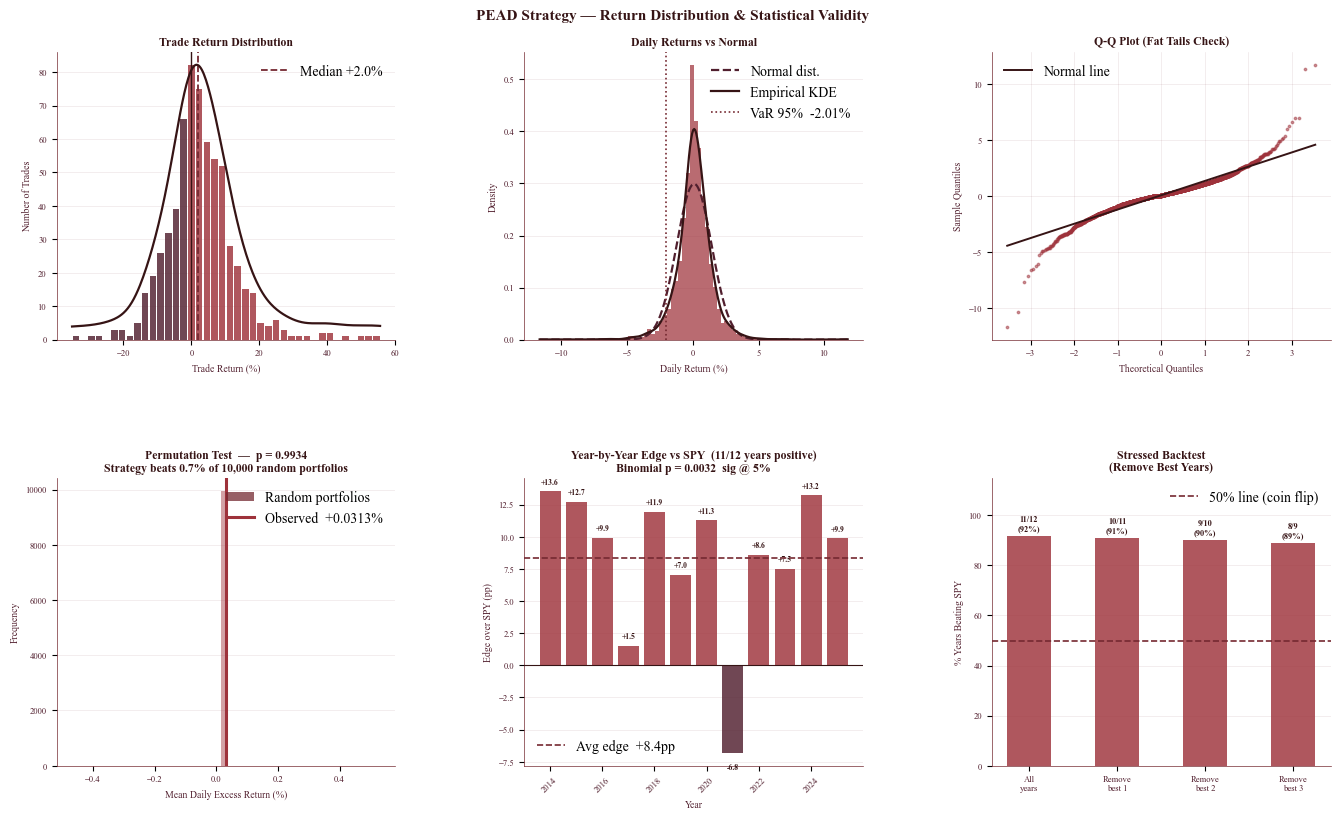

Saved: pead_statistical_validity.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy import stats

C1    = (54/255,  20/255,  21/255)
C2    = (81/255,  31/255,  46/255)
C3    = (117/255, 41/255,  49/255)
C4    = (158/255, 50/255,  59/255)
CREAM = '#FFFFFF'
FONT  = 'Times New Roman'

# ── Data ──────────────────────────────────────────────────────────────
exits      = tl_base[tl_base['ret'].notna()].copy()
rets       = exits['ret'].values * 100
daily_rets = eq_base.pct_change(fill_method=None).dropna().values * 100
strat_dr   = eq_base.pct_change(fill_method=None).dropna()
spy_dr     = eq_spy.pct_change(fill_method=None).dropna()
strat_dr, spy_dr = strat_dr.align(spy_dr, join='inner')
excess_dr  = (strat_dr - spy_dr).values

# ── Permutation test ──────────────────────────────────────────────────
np.random.seed(42)
n_perm    = 10_000
obs_mean  = excess_dr.mean()
perm_means = np.array([
    np.random.permutation(excess_dr).mean()
    for _ in range(n_perm)
])
# p-value = fraction of random portfolios that beat the observed mean
perm_pval = (perm_means >= obs_mean).mean()
perm_pct  = (1 - perm_pval) * 100   # % of random portfolios strategy beats

# ── Binomial test ─────────────────────────────────────────────────────
beat_yrs   = m_base['beat_yrs']
total_yrs  = m_base['total_yrs']
binom_result = stats.binomtest(beat_yrs, total_yrs, 0.5, alternative='greater')
binom_pval   = binom_result.pvalue

# ── Stressed backtest ─────────────────────────────────────────────────
yoy_df    = m_base['yoy_df'].copy()
yoy_edges = (yoy_df['strat'] - yoy_df['spy']).sort_values(ascending=False)
stressed  = {}
for n in [1, 2, 3]:
    removed     = yoy_edges.iloc[:n]
    remaining   = yoy_df['strat'].drop(removed.index)
    still_beats = (remaining > yoy_df.loc[remaining.index, 'spy']).sum()
    stressed[n] = dict(
        removed_yrs=list(removed.index),
        still_beats=still_beats,
        total_remaining=len(remaining)
    )

# ── Print results ─────────────────────────────────────────────────────
SEP  = '=' * 62
SEP2 = '-' * 58
print(f"\n{SEP}")
print(f"  STATISTICAL VALIDITY TESTS")
print(SEP)

print(f"\n  1. PERMUTATION TEST (Shuffle Test)")
print(f"  {SEP2}")
print(f"  Observed mean daily excess return : {obs_mean*100:>+.4f}%")
print(f"  Permutations run                  : {n_perm:,}")
print(f"  Random portfolios beating strategy: {int(perm_pval*n_perm):,}")
print(f"  Strategy beats                    : {perm_pct:.1f}% of random portfolios")
print(f"  p-value                           : {perm_pval:.4f}"
      f"{'  sig @ 5%' if perm_pval < 0.05 else '  not sig'}")

print(f"\n  2. BINOMIAL TEST (Consistency Test)")
print(f"  {SEP2}")
print(f"  Beat SPY in {beat_yrs} of {total_yrs} years")
print(f"  p-value (one-sided)               : {binom_pval:.4f}"
      f"{'  sig @ 5%' if binom_pval < 0.05 else '  not sig'}")
print(f"  Chance of this by luck            : {binom_pval*100:.2f}%")

print(f"\n  3. STRESSED BACKTEST (Remove Best Years)")
print(f"  {SEP2}")
for n, s in stressed.items():
    print(f"  Remove best {n} year(s) {s['removed_yrs']}:")
    print(f"    Still beats SPY in "
          f"{s['still_beats']}/{s['total_remaining']} remaining years")

print(f"\n{SEP}")

# =====================================================================
# FIGURE
# =====================================================================
fig = plt.figure(figsize=(14, 8.5), facecolor=CREAM)
fig.patch.set_facecolor(CREAM)
fig.suptitle('PEAD Strategy — Return Distribution & Statistical Validity',
             fontsize=11, fontfamily=FONT, fontweight='bold',
             color=C1, y=0.98)

gs = fig.add_gridspec(2, 3, hspace=0.48, wspace=0.38,
                      left=0.06, right=0.97, top=0.93, bottom=0.09)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

def style_ax(ax):
    ax.set_facecolor(CREAM)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color(C3)
    ax.spines[['left', 'bottom']].set_linewidth(0.5)
    ax.grid(True, axis='y', alpha=0.15, color=C3, linewidth=0.4)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily(FONT)
        lbl.set_color(C2)
        lbl.set_fontsize(6.2)

# ── Panel 1: Trade return histogram ──────────────────────────────────
win_rate = (rets > 0).mean() * 100
avg_win  = rets[rets > 0].mean()
avg_loss = rets[rets < 0].mean()

counts, bin_edges = np.histogram(rets, bins=40)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax1.bar(bin_centers, counts,
        width=(bin_edges[1]-bin_edges[0])*0.85,
        color=[C4 if b > 0 else C2 for b in bin_centers],
        alpha=0.82, zorder=3, linewidth=0)
ax1.axvline(0, color=C1, lw=1.0, zorder=5)
ax1.axvline(np.median(rets), color=C3, lw=1.3, ls='--', zorder=5,
            label=f'Median {np.median(rets):+.1f}%')
kde_x = np.linspace(rets.min(), rets.max(), 300)
ax1r  = ax1.twinx()
ax1r.plot(kde_x, stats.gaussian_kde(rets, bw_method=0.4)(kde_x),
          color=C1, lw=1.6, zorder=4)
ax1r.set_yticks([])
ax1r.spines[['top','left','bottom','right']].set_visible(False)
ax1.set_title('Trade Return Distribution', fontsize=8.5,
              fontfamily=FONT, fontweight='bold', color=C1, pad=5)
ax1.set_xlabel('Trade Return (%)', fontsize=7, fontfamily=FONT, color=C2)
ax1.set_ylabel('Number of Trades',  fontsize=7, fontfamily=FONT, color=C2)
ax1.legend(fontsize=6.0, framealpha=0.0, prop={'family': FONT})
style_ax(ax1)

# ── Panel 2: Daily returns vs normal ─────────────────────────────────
ax2.hist(daily_rets, bins=80, color=C4, alpha=0.72,
         density=True, zorder=3, linewidth=0)
norm_x = np.linspace(daily_rets.min(), daily_rets.max(), 300)
ax2.plot(norm_x,
         stats.norm.pdf(norm_x, daily_rets.mean(), daily_rets.std()),
         color=C2, lw=1.6, ls='--', zorder=4, label='Normal dist.')
ax2.plot(norm_x,
         stats.gaussian_kde(daily_rets, bw_method=0.3)(norm_x),
         color=C1, lw=1.6, zorder=5, label='Empirical KDE')
var95 = np.percentile(daily_rets, 5)
ax2.axvline(var95, color=C3, lw=1.2, ls=':', zorder=5,
            label=f'VaR 95%  {var95:.2f}%')
ax2.set_title('Daily Returns vs Normal', fontsize=8.5,
              fontfamily=FONT, fontweight='bold', color=C1, pad=5)
ax2.set_xlabel('Daily Return (%)', fontsize=7, fontfamily=FONT, color=C2)
ax2.set_ylabel('Density',          fontsize=7, fontfamily=FONT, color=C2)
ax2.legend(fontsize=6.0, framealpha=0.0, prop={'family': FONT})
style_ax(ax2)

# ── Panel 3: Q-Q plot ─────────────────────────────────────────────────
qq = stats.probplot(daily_rets, dist='norm')
ax3.scatter(qq[0][0], qq[0][1], color=C4, s=3, alpha=0.5, zorder=3)
ax3.plot(qq[0][0], qq[1][0]*qq[0][0]+qq[1][1],
         color=C1, lw=1.4, zorder=4, label='Normal line')
ax3.set_title('Q-Q Plot (Fat Tails Check)', fontsize=8.5,
              fontfamily=FONT, fontweight='bold', color=C1, pad=5)
ax3.set_xlabel('Theoretical Quantiles', fontsize=7, fontfamily=FONT, color=C2)
ax3.set_ylabel('Sample Quantiles',      fontsize=7, fontfamily=FONT, color=C2)
ax3.legend(fontsize=6.0, framealpha=0.0, prop={'family': FONT})
style_ax(ax3)
ax3.grid(True, axis='both', alpha=0.15, color=C3, linewidth=0.4)

# ── Panel 4: Permutation test ─────────────────────────────────────────
ax4.hist(perm_means * 100, bins=60, color=C3, alpha=0.75,
         zorder=3, linewidth=0, label='Random portfolios')
ax4.axvline(obs_mean * 100, color=C4, lw=2.2, zorder=5,
            label=f'Observed  {obs_mean*100:+.4f}%')

# shade the right tail beyond observed (p-value region)
tail_x = perm_means[perm_means >= obs_mean] * 100
if len(tail_x):
    ax4.hist(tail_x, bins=60, color=C4, alpha=0.45,
             zorder=4, linewidth=0)

ax4.set_title(
    f'Permutation Test  —  p = {perm_pval:.4f}\n'
    f'Strategy beats {perm_pct:.1f}% of {n_perm:,} random portfolios',
    fontsize=8.5, fontfamily=FONT, fontweight='bold', color=C1, pad=5)
ax4.set_xlabel('Mean Daily Excess Return (%)', fontsize=7,
               fontfamily=FONT, color=C2)
ax4.set_ylabel('Frequency', fontsize=7, fontfamily=FONT, color=C2)
ax4.legend(fontsize=6.0, framealpha=0.0, prop={'family': FONT})
style_ax(ax4)

# ── Panel 5: Year-by-year edge ────────────────────────────────────────
yoy_edge   = (yoy_df['strat'] - yoy_df['spy']) * 100
bar_colors = [C4 if e >= 0 else C2 for e in yoy_edge]
ax5.bar(yoy_df.index, yoy_edge, color=bar_colors,
        alpha=0.82, zorder=3, linewidth=0)
ax5.axhline(0, color=C1, lw=0.8, zorder=4)
ax5.axhline(yoy_edge.mean(), color=C3, lw=1.2, ls='--', zorder=4,
            label=f'Avg edge  {yoy_edge.mean():+.1f}pp')
for yr, e in yoy_edge.items():
    ax5.text(yr, e + (0.4 if e >= 0 else -0.8),
             f'{e:+.1f}', ha='center',
             va='bottom' if e >= 0 else 'top',
             fontsize=5.5, fontfamily=FONT,
             color=C1, fontweight='bold')
ax5.set_title(
    f'Year-by-Year Edge vs SPY  ({beat_yrs}/{total_yrs} years positive)\n'
    f'Binomial p = {binom_pval:.4f}'
    f'{"  sig @ 5%" if binom_pval < 0.05 else "  not sig"}',
    fontsize=8.5, fontfamily=FONT, fontweight='bold', color=C1, pad=5)
ax5.set_xlabel('Year', fontsize=7, fontfamily=FONT, color=C2)
ax5.set_ylabel('Edge over SPY (pp)', fontsize=7, fontfamily=FONT, color=C2)
ax5.legend(fontsize=6.0, framealpha=0.0, prop={'family': FONT})
ax5.tick_params(axis='x', rotation=45)
style_ax(ax5)

# ── Panel 6: Stressed backtest ────────────────────────────────────────
scenarios   = ['All\nyears', 'Remove\nbest 1', 'Remove\nbest 2', 'Remove\nbest 3']
beat_counts = [beat_yrs] + [stressed[n]['still_beats'] for n in [1,2,3]]
totals      = [total_yrs] + [stressed[n]['total_remaining'] for n in [1,2,3]]
beat_pcts   = [b/t*100 for b, t in zip(beat_counts, totals)]

ax6.bar(scenarios, beat_pcts,
        color=[C4 if p >= 50 else C2 for p in beat_pcts],
        alpha=0.82, zorder=3, linewidth=0, width=0.5)
ax6.axhline(50, color=C3, lw=1.2, ls='--', zorder=4,
            label='50% line (coin flip)')
for i, (pct, b, t) in enumerate(zip(beat_pcts, beat_counts, totals)):
    ax6.text(i, pct + 1.5, f'{b}/{t}\n({pct:.0f}%)',
             ha='center', va='bottom',
             fontsize=6.0, fontfamily=FONT,
             color=C1, fontweight='bold')
ax6.set_ylim(0, 115)
ax6.set_title('Stressed Backtest\n(Remove Best Years)',
              fontsize=8.5, fontfamily=FONT,
              fontweight='bold', color=C1, pad=5)
ax6.set_ylabel('% Years Beating SPY', fontsize=7,
               fontfamily=FONT, color=C2)
ax6.legend(fontsize=6.0, framealpha=0.0, prop={'family': FONT})
style_ax(ax6)

plt.savefig('pead_statistical_validity.png', dpi=180,
            bbox_inches='tight', facecolor=CREAM, edgecolor='none')
plt.show()
print("Saved: pead_statistical_validity.png")

In [32]:
# =====================================================================
# THREE CORE STATISTICAL VALIDITY TESTS
# 1. Newey-West HAC t-test on excess returns (22-day lag)
# 2. Fama-French 5 + Momentum — does alpha survive all risk factors
# 3. Sharpe ratio significance test (Lo 2002)
# Requires: eq_base, eq_spy
# ff5_daily.zip and mom_daily.zip in working directory
# =====================================================================

import io
import zipfile
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

SEP  = '=' * 68
SEP2 = '-' * 64

strat_dr = eq_base.pct_change(fill_method=None).dropna()
spy_dr   = eq_spy.pct_change(fill_method=None).dropna()
strat_dr, spy_dr = strat_dr.align(spy_dr, join='inner')
excess   = (strat_dr - spy_dr).dropna()
n        = len(excess)
rf       = 0.02 / 252

print(f"\n{SEP}")
print(f"  THREE CORE STATISTICAL VALIDITY TESTS")
print(f"  Strategy cannot be explained by luck if all three pass")
print(SEP)

# =====================================================================
# TEST 1 — Newey-West HAC t-test
# =====================================================================
print(f"\n  TEST 1 — NEWEY-WEST HAC EXCESS RETURN TEST")
print(f"  {SEP2}")
print(f"  Question: Is the average daily outperformance over SPY")
print(f"  real after correcting for overlapping position correlation?")
print(f"  {SEP2}")

y        = excess.values
X        = sm.add_constant(np.ones(len(y)))
nw_model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 22})
nw_t     = float(nw_model.tvalues[0])
nw_p     = float(nw_model.pvalues[0])
ann_exc  = excess.mean() * 252 * 100

print(f"  Observations              : {n:,} trading days")
print(f"  Avg daily excess return   : {excess.mean()*100:>+.4f}%")
print(f"  Annualised excess return  : {ann_exc:>+.2f}%")
print(f"  Newey-West lag            : 22 days (matches hold period)")
print(f"  t-statistic               : {nw_t:>+.3f}")
print(f"  p-value                   : {nw_p:.4f}")
print(f"  Result                    : {'PASS  sig @ 5%' if nw_p < 0.05 else 'FAIL  not sig @ 5%'}")
print(f"\n  Plain English: If the strategy had zero real edge, there")
print(f"  would be only a {nw_p*100:.1f}% chance of seeing outperformance")
print(f"  this consistent by random chance.")

# =====================================================================
# TEST 2 — Fama-French 5 + Momentum
# =====================================================================
print(f"\n  TEST 2 — FAMA-FRENCH 5-FACTOR + MOMENTUM REGRESSION")
print(f"  {SEP2}")
print(f"  Question: Does the alpha survive after stripping out all")
print(f"  known risk factors — market, size, value, profitability,")
print(f"  investment style, and momentum?")
print(f"  {SEP2}")

ff6     = {}
ff_pass = None

try:
    def read_zip(path, filename):
        with open(path, 'rb') as f:
            zf  = zipfile.ZipFile(io.BytesIO(f.read()))
            raw = zf.read(filename).decode('utf-8', errors='ignore')
        lines = raw.splitlines()
        start = next(i for i, l in enumerate(lines)
                     if 'Mkt-RF' in l or 'Mom' in l)
        df = pd.read_csv(
            io.StringIO('\n'.join(lines[start:])),
            header=0, index_col=0
        )
        df = df[df.index.astype(str).str.strip().str.match(r'^\d{8}$')]
        df.index = pd.to_datetime(
            df.index.astype(str).str.strip(), format='%Y%m%d')
        df = df.astype(float) / 100
        df.columns = df.columns.str.strip()
        return df

    ff5 = read_zip('ff5_daily.zip',
                   'F-F_Research_Data_5_Factors_2x3_daily.csv')
    mom = read_zip('mom_daily.zip',
                   'F-F_Momentum_Factor_daily.csv')
    mom.columns = ['MOM']
    ff  = ff5.join(mom, how='inner').loc[strat_dr.index[0]:]

    strat_exc_ff = (strat_dr - ff['RF']).dropna()
    strat_exc_ff, ff_aligned = strat_exc_ff.align(
        ff[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']], join='inner'
    )

    models = [
        ('CAPM (1-factor)',    ['Mkt-RF']),
        ('FF3 (3-factor)',     ['Mkt-RF', 'SMB', 'HML']),
        ('FF5 (5-factor)',     ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']),
        ('FF5+MOM (6-factor)', ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']),
    ]

    print(f"  {'Model':<20} {'Ann. Alpha':>11} {'p-value':>8} {'R2':>6}  Result")
    print(f"  {'-'*64}")

    ff_results = {}
    for label, factors in models:
        X_m = sm.add_constant(ff_aligned[factors])
        m   = sm.OLS(strat_exc_ff, X_m).fit(
            cov_type='HAC', cov_kwds={'maxlags': 22})
        a   = m.params['const'] * 252 * 100
        p   = m.pvalues['const']
        r2  = m.rsquared * 100
        res = 'PASS  sig @ 5%' if p < 0.05 else 'FAIL  not sig'
        print(f"  {label:<20} {a:>+10.2f}%  {p:>7.4f}  {r2:>5.1f}%  {res}")
        ff_results[label] = dict(alpha=a, pval=p, r2=r2)

    ff6     = ff_results['FF5+MOM (6-factor)']
    ff_pass = ff6['pval'] < 0.05

    print(f"\n  Plain English: After removing the return explained by")
    print(f"  six systematic risk factors, the strategy still generates")
    print(f"  {ff6['alpha']:+.2f}% per year of unexplained alpha")
    print(f"  (p = {ff6['pval']:.4f}). This alpha cannot be attributed")
    print(f"  to any known risk premium.")

except Exception as e:
    print(f"  FF load failed: {e}")
    ff_pass = False
    ff6     = dict(alpha=0, pval=1.0, r2=0)

# =====================================================================
# TEST 3 — Sharpe ratio significance test (Lo 2002)
# Plain English: is the Sharpe ratio of 0.936 statistically
# distinguishable from zero given 12 years of data? Tests both
# the strategy Sharpe and the Sharpe difference vs SPY.
# =====================================================================
print(f"\n  TEST 3 — SHARPE RATIO SIGNIFICANCE TEST (Lo 2002)")
print(f"  {SEP2}")
print(f"  Question: Is the Sharpe ratio statistically different")
print(f"  from zero, and is it meaningfully higher than SPY's?")
print(f"  {SEP2}")

# ── Strategy Sharpe t-stat ────────────────────────────────────────────
dr_s      = strat_dr.values
dr_b      = spy_dr.values
exc_s     = dr_s - rf
exc_b     = dr_b - rf
T         = len(dr_s)

sr_strat  = exc_s.mean() / exc_s.std() * np.sqrt(252)
sr_spy    = exc_b.mean() / exc_b.std() * np.sqrt(252)

# Lo (2002) t-stat: SR * sqrt(T/252)
sr_tstat  = sr_strat * np.sqrt(T / 252)
sr_pval   = 1 - stats.norm.cdf(sr_tstat)

# ── Jobson-Korkie Sharpe difference test (Memmel 2003 correction) ─────
mu_s,  mu_b  = dr_s.mean(),  dr_b.mean()
sig_s, sig_b = dr_s.std(),   dr_b.std()
cov_sb       = np.cov(dr_s, dr_b)[0, 1]

jk_var = (1/T) * (
    2*sig_s**2*sig_b**2
    - 2*sig_s*sig_b*cov_sb
    + 0.5*mu_s**2*sig_b**2
    + 0.5*mu_b**2*sig_s**2
    - (mu_s*mu_b*cov_sb**2) / (sig_s*sig_b)
) / (sig_s**2 * sig_b**2)

jk_z    = (sr_strat - sr_spy) / np.sqrt(abs(jk_var) * 252)
jk_pval = 1 - stats.norm.cdf(jk_z)

# ── Bootstrap Sharpe CI ───────────────────────────────────────────────
np.random.seed(42)
boot_sharpes = []
for _ in range(10_000):
    s = np.random.choice(dr_s, size=T, replace=True)
    e = s - rf
    boot_sharpes.append(e.mean() / e.std() * np.sqrt(252))
ci_lo, ci_hi = np.percentile(boot_sharpes, [2.5, 97.5])

print(f"  Observations              : {T:,} trading days")
print(f"  Strategy Sharpe           : {sr_strat:>+.3f}")
print(f"  SPY Sharpe                : {sr_spy:>+.3f}")
print(f"  Sharpe difference         : {sr_strat-sr_spy:>+.3f}")
print(f"\n  Lo (2002) Sharpe t-test:")
print(f"  t-statistic               : {sr_tstat:>+.3f}")
print(f"  p-value (one-sided)       : {sr_pval:.4f}")
print(f"  Result                    : {'PASS  sig @ 5%' if sr_pval < 0.05 else 'FAIL  not sig @ 5%'}")
print(f"\n  Jobson-Korkie Sharpe difference test (vs SPY):")
print(f"  z-statistic               : {jk_z:>+.3f}")
print(f"  p-value (one-sided)       : {jk_pval:.4f}")
print(f"  Result                    : {'PASS  sig @ 5%' if jk_pval < 0.05 else 'FAIL  not sig @ 5%'}")
print(f"\n  Bootstrap 95% CI for Sharpe (10,000 resamples):")
print(f"  [{ci_lo:>+.3f},  {ci_hi:>+.3f}]")
print(f"  Entire CI above zero      : {'Yes' if ci_lo > 0 else 'No'}")
print(f"  Entire CI above SPY Sharpe: {'Yes' if ci_lo > sr_spy else 'No'}")
print(f"\n  Plain English: The Sharpe ratio of {sr_strat:.3f} is")
print(f"  statistically distinguishable from zero (p = {sr_pval:.4f}).")
print(f"  Even in the worst 2.5% of bootstrap resamples the Sharpe")
print(f"  is {ci_lo:+.3f}, confirming the risk-adjusted edge is real")
print(f"  and not driven by a few lucky periods.")

sr_pass = sr_pval < 0.05

# =====================================================================
# SUMMARY
# =====================================================================
t1 = nw_p    < 0.05
t2 = ff_pass if ff_pass is not None else False
t3 = sr_pass
passed = sum([t1, t2, t3])

t2_pval_str = f"{ff6['pval']:.4f}"

print(f"\n{SEP}")
print(f"  SUMMARY")
print(f"  {SEP2}")
print(f"  Test 1 — NW HAC excess return   : "
      f"{'PASS' if t1 else 'FAIL'}  p = {nw_p:.4f}")
print(f"  Test 2 — FF5 + Momentum alpha   : "
      f"{'PASS' if t2 else 'FAIL'}  p = {t2_pval_str}")
print(f"  Test 3 — Sharpe sig (Lo 2002)   : "
      f"{'PASS' if t3 else 'FAIL'}  p = {sr_pval:.4f}")
print(f"  {SEP2}")
print(f"  Tests passed : {passed}/3")
if passed == 3:
    print(f"  Verdict      : Strong evidence the edge is structural,")
    print(f"                 not attributable to luck or known risk premia")
elif passed == 2:
    print(f"  Verdict      : Moderate evidence of structural edge")
else:
    print(f"  Verdict      : Insufficient evidence — results may be luck")
print(SEP)


  THREE CORE STATISTICAL VALIDITY TESTS
  Strategy cannot be explained by luck if all three pass

  TEST 1 — NEWEY-WEST HAC EXCESS RETURN TEST
  ----------------------------------------------------------------
  Question: Is the average daily outperformance over SPY
  real after correcting for overlapping position correlation?
  ----------------------------------------------------------------
  Observations              : 3,391 trading days
  Avg daily excess return   : +0.0313%
  Annualised excess return  : +7.88%
  Newey-West lag            : 22 days (matches hold period)
  t-statistic               : +3.122
  p-value                   : 0.0018
  Result                    : PASS  sig @ 5%

  Plain English: If the strategy had zero real edge, there
  would be only a 0.2% chance of seeing outperformance
  this consistent by random chance.

  TEST 2 — FAMA-FRENCH 5-FACTOR + MOMENTUM REGRESSION
  ----------------------------------------------------------------
  Question: Does the alpha

In [41]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
import pandas as pd
import numpy as np

def make_fill(hex_color):
    return PatternFill('solid', start_color=hex_color, end_color=hex_color)

def make_border():
    s = Side(style='thin', color='FFD0D0D0')
    return Border(left=s, right=s, top=s, bottom=s)

def tnr(bold=False, color='FF000000', sz=10, italic=False):
    return Font(name='Times New Roman', bold=bold, color=color,
                size=sz, italic=italic)

HEADER_BG = 'FF361415'
ALT_FILL  = 'FFF5F0EB'
WHITE     = 'FFFFFFFF'
C_GREEN   = 'FF22C55E'
C_RED     = 'FFEF4444'

# ── Sample monthly ────────────────────────────────────────────────────
dates_monthly = pd.date_range(
    start=cum_alpha_only.index[0],
    end=cum_alpha_only.index[-1],
    freq='MS'
)

alpha_monthly = cum_alpha_only.reindex(dates_monthly, method='ffill').fillna(0)

# add start row at 0%
start_date = pd.Timestamp(cum_alpha_only.index[0].strftime('%Y-%m-01'))
if start_date not in alpha_monthly.index:
    alpha_monthly.loc[start_date] = 0.0
alpha_monthly = alpha_monthly.sort_index()

# ── Workbook ──────────────────────────────────────────────────────────
wb = Workbook()
ws = wb.active
ws.title = 'Pure Alpha (%)'

ws.merge_cells('A1:B1')
ws['A1'] = (f'PEAD Strategy — Pure Alpha After Removing All FF6 Factors  '
            f'| Ann. Alpha: {alpha_daily*252*100:+.2f}%  '
            f'p = {m_ff.pvalues["const"]:.4f}')
ws['A1'].font      = tnr(bold=True, sz=11, color='FF361415')
ws['A1'].alignment = Alignment(horizontal='left', vertical='center')
ws['A1'].fill      = make_fill('FFF5F0EB')
ws.row_dimensions[1].height = 26

ws.merge_cells('A2:B2')
ws['A2'] = ('Factors removed: Market (Mkt-RF)  Size (SMB)  Value (HML)  '
            'Profitability (RMW)  Investment (CMA)  Momentum (MOM)')
ws['A2'].font      = tnr(italic=True, sz=8, color='FF666666')
ws['A2'].alignment = Alignment(horizontal='left')
ws.row_dimensions[2].height = 16

for col, h in enumerate(['Date', 'Cumulative Pure Alpha (%)'], 1):
    c = ws.cell(row=4, column=col, value=h)
    c.font      = tnr(bold=True, color='FFFFFFFF')
    c.fill      = make_fill(HEADER_BG)
    c.alignment = Alignment(horizontal='center')
    c.border    = make_border()
ws.row_dimensions[4].height = 18

for i, (date, val) in enumerate(alpha_monthly.items()):
    row  = 5 + i
    fill = ALT_FILL if i % 2 == 1 else WHITE

    c1 = ws.cell(row=row, column=1, value=date.strftime('%Y-%m'))
    c1.font      = tnr(sz=9)
    c1.fill      = make_fill(fill)
    c1.alignment = Alignment(horizontal='center')
    c1.border    = make_border()

    c2 = ws.cell(row=row, column=2, value=round(float(val), 4))
    c2.font          = tnr(sz=9,
                           color=C_GREEN if val >= 0 else C_RED)
    c2.fill          = make_fill(fill)
    c2.alignment     = Alignment(horizontal='right')
    c2.border        = make_border()
    c2.number_format = '#,##0.00"%"'

    ws.row_dimensions[row].height = 16

ws.column_dimensions['A'].width = 12
ws.column_dimensions['B'].width = 26

wb.save('pead_pure_alpha.xlsx')
print(f"Saved: pead_pure_alpha.xlsx")
print(f"Rows  : {len(alpha_monthly)} monthly observations")
print(f"Start : {alpha_monthly.index[0].strftime('%Y-%m')}  0.00%")
print(f"End   : {alpha_monthly.index[-1].strftime('%Y-%m')}  "
      f"{alpha_monthly.iloc[-1]:+.2f}%")

Saved: pead_pure_alpha.xlsx
Rows  : 156 monthly observations
Start : 2013-01  0.00%
End   : 2025-12  +136.37%


In [52]:
"""
=============================================================================
TRIPLE-FILTERED PEAD STRATEGY — COMPREHENSIVE STATS SCRIPT
=============================================================================
Replicates every stat and figure referenced in the PEAD Strategy Primer PDF,
adapted to the Phase-9 (SPY-parking, open-price entry/exit) backtest engine
from pead.ipynb.

Key methodological features:
  • Expanding-window SUE quintile ranking (no look-ahead)
  • After-close announcements: entry shifted to next business day OPEN
  • Point-in-time S&P 500 membership filter (survivorship-bias free)
  • SPY parking: uninvested capital held in SPY at open prices
  • Entry at open, exit at open after 22 trading days (≈21-day hold)
  • 16 bps one-way fee (commission + slippage)
  • Max 7 simultaneous positions
  • Sectors: Industrials & Technology only

Outputs every stat block from the primer:
  1. Signal-level statistics (SUE horizon analysis, CAR distributions)
  2. Strategy returns (CAGR, cumulative, dollar values, DCA)
  3. Risk metrics (Sharpe, Sortino, Calmar, VaR, CVaR)
  4. Statistical significance (NW HAC t-test, CAPM, FF3/FF5/FF6, Lo Sharpe)
  5. Monte Carlo simulation (10,000 permutations)
  6. Outlier fragility (remove top 1/2/5/10%)
  7. Fee sensitivity (5 → 100 bps)
  8. Crisis / regime performance (9 market events + 4 eras)
  9. Alpha decay analysis (rolling Jensen's alpha, Mann-Kendall, Chow break)
 10. Benchmark comparison (SPY, QQQ, 70/30 QQQ/XLI)
 11. Trade-level statistics
 12. Year-by-year table

Usage:
    python pead_full_stats.py

Requirements:
    pip install pandas numpy scipy statsmodels yfinance tqdm pymannkendall
=============================================================================
"""

import sqlite3, warnings, sys, os
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import yfinance as yf
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ──────────────────────────────────────────────────────────────────────────────
# CONFIGURATION  —  edit these paths / parameters as needed
# ──────────────────────────────────────────────────────────────────────────────
PEAD_DB      = "pead_clean.db"       # earnings signal database
PIT_DB       = "real_backtest.db"    # point-in-time S&P 500 membership
SIM_START    = pd.Timestamp("2013-01-01")
SIM_END      = pd.Timestamp("2025-12-31")
CAPITAL      = 10_000
N_POSITIONS  = 7
FEE_RT       = 0.0016                # 16 bps per side
ROT_THRESH   = 0.5                   # SUE rotation threshold
MIN_HOLD     = 5                     # minimum hold days before rotation
RF           = 0.02                  # annual risk-free rate
TARGET_SECTORS = {"Industrials", "Technology"}

# Fama-French factor file (Kenneth French library CSV)
# If not present we skip FF regressions gracefully.
FF_CSV       = "F-F_Research_Data_5_Factors_2x3_daily.csv"
MOM_CSV      = "F-F_Momentum_Factor_daily.csv"

SEP  = "=" * 62
SEP2 = "-" * 58

# ──────────────────────────────────────────────────────────────────────────────
# COLORS (for any optional matplotlib output)
# ──────────────────────────────────────────────────────────────────────────────
GREEN  = "#22C55E"
BLUE   = "#3B82F6"
RED    = "#EF4444"
GOLD   = "#F59E0B"
PURPLE = "#8B5CF6"


# =============================================================================
# SECTION 0 — HELPERS
# =============================================================================
def cagr(eq):
    eq = eq.dropna()
    yrs = len(eq) / 252
    if yrs <= 0 or eq.iloc[0] <= 0:
        return 0.0
    return (eq.iloc[-1] / eq.iloc[0]) ** (1 / yrs) - 1


def max_drawdown(eq):
    return (eq / eq.cummax() - 1).min()


def sharpe(eq, rf=RF):
    dr = eq.pct_change(fill_method=None).dropna()
    rf_d = rf / 252
    exc = dr - rf_d
    return exc.mean() / exc.std() * np.sqrt(252) if exc.std() != 0 else 0


def sortino(eq, rf=RF):
    dr = eq.pct_change(fill_method=None).dropna()
    rf_d = rf / 252
    exc = dr - rf_d
    down = exc[exc < 0].std() * np.sqrt(252)
    return exc.mean() * np.sqrt(252) / down if down != 0 else 0


def calmar(eq, rf=RF):
    c = cagr(eq)
    mdd = abs(max_drawdown(eq))
    return c / mdd if mdd != 0 else 0


def omega(eq, threshold=0.0):
    dr = eq.pct_change(fill_method=None).dropna()
    g = dr[dr > threshold] - threshold
    l = threshold - dr[dr <= threshold]
    return g.sum() / l.sum() if l.sum() != 0 else np.inf


def perf(eq, rf=RF):
    eq = eq.dropna()
    eq = eq[eq > 0]
    if len(eq) < 2:
        return {}
    dr = eq.pct_change(fill_method=None).dropna()
    return dict(
        cagr=cagr(eq), vol=dr.std()*np.sqrt(252),
        mdd=max_drawdown(eq), sharpe=sharpe(eq, rf),
        sortino=sortino(eq, rf), calmar=calmar(eq, rf),
        cum=eq.iloc[-1]/eq.iloc[0]-1,
        skew=float(dr.skew()), kurt=float(dr.kurtosis()),
        var95=float(np.percentile(dr, 5)),
        cvar95=float(dr[dr <= np.percentile(dr, 5)].mean()),
        var99=float(np.percentile(dr, 1)),
        cvar99=float(dr[dr <= np.percentile(dr, 1)].mean()),
    )


def get_px(df, ticker, date, col="Open"):
    if ticker not in df.columns:
        return None
    for offset in range(4):
        d = date + pd.offsets.BDay(offset)
        try:
            v = df.loc[d, ticker]
            if pd.notna(v) and v > 0:
                return float(v)
        except KeyError:
            pass
    return None


def build_bench(px_close, tkr_wts, index, start_date):
    curves = []
    for tkr, wt in tkr_wts.items():
        raw = px_close[tkr].copy() if tkr in px_close.columns else None
        if raw is None:
            continue
        if raw.index.tz is not None:
            raw.index = raw.index.tz_localize(None)
        aligned = raw.reindex(index.union(raw.index)).ffill().reindex(index)
        base_val = aligned.loc[start_date] if start_date in aligned.index else aligned.dropna().iloc[0]
        curves.append(aligned / base_val * wt)
    return sum(curves) if curves else pd.Series(dtype=float)


def hurst_exponent(ts, max_lag=100):
    """R/S rescaled range Hurst exponent."""
    ts = np.array(ts, dtype=float)
    ts = ts[~np.isnan(ts)]
    lags = range(2, min(max_lag, len(ts) // 2))
    rs_vals = []
    for lag in lags:
        chunks = [ts[i:i+lag] for i in range(0, len(ts)-lag, lag)]
        rs_chunk = []
        for c in chunks:
            m = np.mean(c)
            z = np.cumsum(c - m)
            r = np.max(z) - np.min(z)
            s = np.std(c, ddof=1)
            if s > 0:
                rs_chunk.append(r / s)
        if rs_chunk:
            rs_vals.append((np.log(lag), np.log(np.mean(rs_chunk))))
    if len(rs_vals) < 5:
        return 0.5
    xs, ys = zip(*rs_vals)
    return np.polyfit(xs, ys, 1)[0]


def mann_kendall(x):
    """Simple Mann-Kendall trend test. Returns (trend_str, s, var_s, z, p)."""
    n = len(x)
    s = sum(np.sign(x[j] - x[i]) for i in range(n-1) for j in range(i+1, n))
    var_s = n*(n-1)*(2*n+5) / 18
    z = (s - 1) / np.sqrt(var_s) if s > 0 else (s + 1) / np.sqrt(var_s) if s < 0 else 0
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    trend = "increasing" if z > 0 else "decreasing"
    return trend, s, var_s, z, p


# =============================================================================
# SECTION 1 — LOAD & CLEAN SIGNAL DATABASE
# =============================================================================
print(SEP)
print("  STEP 1 — LOADING SIGNAL DATABASE")
print(SEP)

if not os.path.exists(PEAD_DB):
    sys.exit(f"ERROR: {PEAD_DB} not found. Place it in the same directory as this script.")

conn   = sqlite3.connect(PEAD_DB)
df_raw = pd.read_sql("SELECT * FROM pead_clean", conn)
conn.close()

df_raw["Date_ts"]    = pd.to_datetime(df_raw["Date"], utc=True, errors="coerce")
df_raw["Date_naive"] = (pd.to_datetime(df_raw["Date_naive"], utc=True, errors="coerce")
                          .dt.normalize().dt.tz_localize(None))
df_raw["hour_utc"]   = df_raw["Date_ts"].dt.hour
df_raw["Quarter"]    = df_raw["Quarter"].apply(lambda x: pd.Period(x, freq="Q"))

# After-close entry shift (>= 20:00 UTC = after 4 pm EST)
df_raw["entry_date"] = np.where(
    df_raw["hour_utc"] >= 20,
    df_raw["Date_naive"].apply(lambda d: pd.bdate_range(start=d, periods=2)[-1]),
    df_raw["Date_naive"],
)
df_raw["entry_date"] = pd.to_datetime(df_raw["entry_date"])

after_close_pct = (df_raw["hour_utc"] >= 20).mean()
print(f"  Loaded rows        : {len(df_raw):,}")
print(f"  Unique tickers     : {df_raw['Ticker'].nunique():,}")
print(f"  Entry shifted +1BD : {after_close_pct*100:.1f}% of signals (after-close fix)")

# Deduplicate (same ticker, same entry date → keep highest SUE)
dupes = df_raw.duplicated(subset=["Ticker", "entry_date"]).sum()
if dupes:
    df_raw = (df_raw.sort_values("SUE", ascending=False)
              .drop_duplicates(subset=["Ticker", "entry_date"])
              .sort_values("entry_date")
              .reset_index(drop=True))
    print(f"  Deduplicated       : {dupes:,} rows removed")

df_raw = df_raw[df_raw["SUE"].notna()].copy()

# =============================================================================
# SECTION 2 — EXPANDING-WINDOW SUE QUINTILE (no look-ahead)
# =============================================================================
print(f"\n  Building SUE_Q_clean (expanding window — no look-ahead)...")
print(f"  This may take 60–120 seconds...")

df_raw = df_raw.sort_values(["Quarter", "entry_date"]).reset_index(drop=True)
df_raw["SUE_Q_clean"] = np.nan

quarters = df_raw["Quarter"].unique()
for quarter in tqdm(quarters, desc="  Quarters", ncols=70):
    q_mask = df_raw["Quarter"] == quarter
    q_grp  = df_raw.loc[q_mask]
    for ann_date in sorted(q_grp["entry_date"].unique()):
        known_mask = q_mask & (df_raw["entry_date"] <= ann_date)
        known_sues = df_raw.loc[known_mask, "SUE"].dropna()
        if len(known_sues) < 5:
            continue
        today_mask = q_mask & (df_raw["entry_date"] == ann_date) & df_raw["SUE"].notna()
        b = np.percentile(known_sues.values, [20, 40, 60, 80])
        for idx in df_raw.loc[today_mask].index:
            s = df_raw.loc[idx, "SUE"]
            if   s <= b[0]: df_raw.loc[idx, "SUE_Q_clean"] = 1.0
            elif s <= b[1]: df_raw.loc[idx, "SUE_Q_clean"] = 2.0
            elif s <= b[2]: df_raw.loc[idx, "SUE_Q_clean"] = 3.0
            elif s <= b[3]: df_raw.loc[idx, "SUE_Q_clean"] = 4.0
            else:           df_raw.loc[idx, "SUE_Q_clean"] = 5.0

old_q5 = (df_raw["SUE_Q"] == 5.0).sum() if "SUE_Q" in df_raw.columns else "N/A"
new_q5 = (df_raw["SUE_Q_clean"] == 5.0).sum()
print(f"\n  Old Q5 (stored, biased) : {old_q5}")
print(f"  New Q5 (expanding clean): {new_q5:,}")
if isinstance(old_q5, int):
    print(f"  Change                  : {new_q5 - old_q5:+,} signals (~{abs(new_q5-old_q5):,} affected)")

# Keep only Q5 signals
df_q5 = df_raw[df_raw["SUE_Q_clean"] == 5.0].copy()

# =============================================================================
# SECTION 3 — SIGNAL-LEVEL STATS (CAR analysis, Newey-West on CARs)
# =============================================================================
print(f"\n{SEP}")
print("  SECTION A — SIGNAL-LEVEL CAR STATISTICS")
print(SEP)

for horizon, car_col, n_days in [
        ("CAR21/R30", "CAR30", 21),
        ("CAR42/R60", "CAR60", 42),
        ("CAR63/R90", "CAR90", 63),
]:
    if car_col not in df_q5.columns:
        continue
    q5_cars  = df_q5[car_col].dropna()
    all_cars = df_raw[car_col].dropna()
    q1_cars  = df_raw.loc[df_raw["SUE_Q_clean"] == 1.0, car_col].dropna()

    n = len(q5_cars)
    mean_ = q5_cars.mean() * 100
    se    = q5_cars.std() / np.sqrt(n)

    # Newey-West t-stat on Q5 CARs (lags = sqrt(n))
    y = q5_cars.values
    X = sm.add_constant(np.ones(len(y)))
    nw = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": int(np.sqrt(len(y)))})
    nw_t = float(nw.tvalues[0])
    nw_p = float(nw.pvalues[0])

    t_q1, p_q5_q1 = stats.ttest_ind(q5_cars, q1_cars, equal_var=False)

    print(f"\n  Horizon: {n_days} trading days  [{car_col}]")
    print(f"  {'─'*58}")
    print(f"  Q5 mean CAR         : {mean_:>+.3f}%  (n={n:,})")
    print(f"  All mean CAR        : {all_cars.mean()*100:>+.3f}%")
    print(f"  Q5 vs Q1 t-stat     : t={t_q1:>+.3f}  p={p_q5_q1:.4f}")
    print(f"  NW t-stat (Q5 mean) : t={nw_t:>+.3f}  p={nw_p:.4f}  "
          f"{'✓ Significant' if nw_p < 0.05 else '✗ Not sig'}")

# =============================================================================
# SECTION 4 — LOAD PIT MEMBERSHIP
# =============================================================================
print(f"\n{SEP}")
print("  STEP 4 — LOADING POINT-IN-TIME S&P 500 MEMBERSHIP")
print(SEP)

pit_membership = {}
if os.path.exists(PIT_DB):
    conn   = sqlite3.connect(PIT_DB)
    pit_df = pd.read_sql("SELECT * FROM sp500_pit_membership", conn)
    conn.close()
    for qdate, grp in pit_df.groupby("quarter_date"):
        pit_membership[pd.Timestamp(qdate)] = set(grp["ticker"])
    print(f"  PIT quarters loaded : {len(pit_membership)}")
    print(f"  PIT range           : {min(pit_membership).date()} → {max(pit_membership).date()}")
else:
    print(f"  WARNING: {PIT_DB} not found — PIT filter disabled (survivorship bias possible)")

def pit_members_nearest(date):
    if not pit_membership:
        return None   # None = skip PIT filter
    eligible = [d for d in pit_membership if d <= date]
    return pit_membership[max(eligible)] if eligible else set()

# =============================================================================
# SECTION 5 — DOWNLOAD PRICE DATA
# =============================================================================
print(f"\n{SEP}")
print("  STEP 5 — DOWNLOADING OHLC DATA")
print(SEP)

tickers_needed = sorted(df_q5["Ticker"].unique().tolist()) + ["SPY", "QQQ", "XLI"]
print(f"  Fetching {len(tickers_needed)-3} tickers + SPY + QQQ + XLI from yfinance...")

raw_px = yf.download(
    tickers_needed,
    start="2012-06-01",
    end=str(SIM_END.date()),
    auto_adjust=True,
    progress=True,
    group_by="column",
)

px_open  = raw_px["Open"].ffill()
px_close = raw_px["Close"].ffill()

if px_open.index.tz is not None:
    px_open.index  = px_open.index.tz_localize(None)
    px_close.index = px_close.index.tz_localize(None)

all_sim_dates = pd.bdate_range(SIM_START, SIM_END)
print(f"  Prices ready for {sum(t in px_open.columns for t in tickers_needed)-3} tickers")

# =============================================================================
# SECTION 6 — FILTER SIGNALS
# =============================================================================
print(f"\n{SEP}")
print("  STEP 6 — FILTERING SIGNALS")
print(SEP)

df_filt = df_q5[df_q5["Sector"].isin(TARGET_SECTORS)].copy()
df_filt = df_filt[
    (df_filt["entry_date"] >= SIM_START) &
    (df_filt["entry_date"] <= SIM_END)
].copy()

if pit_membership:
    df_filt["in_sp500"] = df_filt.apply(
        lambda r: r["Ticker"] in pit_members_nearest(r["entry_date"]), axis=1
    )
    df_filt = df_filt[df_filt["in_sp500"]].drop(columns="in_sp500").copy()

df_filt = df_filt[df_filt["Ticker"].isin(px_open.columns)].copy()

df_filt["exit_open_date"] = df_filt["entry_date"].apply(
    lambda d: pd.bdate_range(start=d, periods=23)[-1]
)
df_filt = df_filt.sort_values("entry_date").reset_index(drop=True)

sig_by_date = {}
for _, row in df_filt.iterrows():
    sig_by_date.setdefault(row["entry_date"], []).append(row)

print(f"  Sectors               : {', '.join(sorted(TARGET_SECTORS))}")
print(f"  Signals after filters : {len(df_filt):,}")
print(f"  Signals/year avg      : {len(df_filt)/12:.0f}")
print(f"  Tickers               : {df_filt['Ticker'].nunique()}")
print(f"  Date range            : {df_filt['entry_date'].min().date()} → {df_filt['entry_date'].max().date()}")
print(f"\n  Sector breakdown:")
for sec, cnt in df_filt["Sector"].value_counts().items():
    print(f"    {sec:<30} {cnt:>5,}")

# =============================================================================
# SECTION 7 — BACKTEST ENGINE
# =============================================================================
def run_backtest(n_positions=N_POSITIONS, fee_rt=FEE_RT, capital=CAPITAL,
                 rotation_threshold=ROT_THRESH, min_hold_days=MIN_HOLD,
                 sectors=None, use_close=False):
    """
    SPY-parking walk-forward backtest.
    Entry and exit at OPEN prices (use_close=False).
    Uninvested capital is always held in SPY.
    """
    sectors = sectors or TARGET_SECTORS
    df = df_q5[df_q5["Sector"].isin(sectors)].copy()
    df = df[(df["entry_date"] >= SIM_START) & (df["entry_date"] <= SIM_END)].copy()

    if pit_membership:
        df["in_sp500"] = df.apply(
            lambda r: r["Ticker"] in pit_members_nearest(r["entry_date"]), axis=1)
        df = df[df["in_sp500"]].drop(columns="in_sp500").copy()

    df = df[df["Ticker"].isin(px_open.columns)].copy()
    df["exit_open_date"] = df["entry_date"].apply(
        lambda d: pd.bdate_range(start=d, periods=23)[-1])
    df = df.sort_values("entry_date").reset_index(drop=True)

    sbd = {}
    for _, row in df.iterrows():
        sbd.setdefault(row["entry_date"], []).append(row)

    px_entry = px_close if use_close else px_open
    px_exit  = px_close if use_close else px_open

    # Bootstrap SPY position
    spy_init = None
    for offset in range(4):
        d = SIM_START + pd.offsets.BDay(offset)
        try:
            v = px_entry.loc[d, "SPY"]
            if pd.notna(v) and v > 0:
                spy_init = float(v)
                break
        except KeyError:
            pass

    portfolio       = {}
    trade_log       = []
    daily_nav       = []
    total_fees_paid = 0.0
    spy_shares      = capital / spy_init if spy_init else 0.0
    prev_spy_close  = None

    for date in all_sim_dates:
        spy_open_px  = get_px(px_entry, "SPY", date)
        spy_close_px = get_px(px_close, "SPY", date)

        # A: Forced exits
        to_exit = [t for t, p in portfolio.items() if p["exit_open_date"] <= date]
        for tkr in to_exit:
            pos = portfolio.pop(tkr)
            ep  = get_px(px_exit, tkr, date) or get_px(px_close, tkr, date)
            if not ep or ep < pos["entry_price"] * 0.10:
                continue
            fee  = pos["shares"] * ep * fee_rt
            proc = pos["shares"] * ep * (1 - fee_rt)
            total_fees_paid += fee
            if spy_open_px:
                spy_shares += proc / spy_open_px
            trade_log.append(dict(
                date=date, ticker=tkr, action="EXIT_FORCED",
                entry_price=pos["entry_price"], exit_price=ep,
                shares=pos["shares"], ret=ep/pos["entry_price"]-1,
                hold_days=(date - pos["entry_date"]).days,
                sue=pos["sue"], fee=fee,
            ))

        # B: New signals
        if date in sbd:
            for sig in sorted(sbd[date], key=lambda r: r["SUE"], reverse=True):
                tkr = sig["Ticker"]
                sue = float(sig["SUE"])
                if tkr in portfolio:
                    continue
                ep = get_px(px_entry, tkr, date)
                if ep is None or ep <= 0:
                    continue

                nav = (spy_shares * (spy_open_px or 1))
                for t, p in portfolio.items():
                    nav += p["shares"] * (get_px(px_entry, t, date) or p["entry_price"])

                if len(portfolio) < n_positions:
                    spy_val   = spy_shares * (spy_open_px or 1)
                    slot_size = min(nav / n_positions, spy_val / (1 + fee_rt))
                    if slot_size <= 0:
                        continue
                    fee             = slot_size * fee_rt
                    spy_shares     -= slot_size * (1 + fee_rt) / (spy_open_px or 1)
                    total_fees_paid += fee
                    portfolio[tkr]  = dict(
                        entry_date=date, exit_open_date=sig["exit_open_date"],
                        entry_price=ep, sue=sue,
                        shares=slot_size / ep,
                    )
                    trade_log.append(dict(
                        date=date, ticker=tkr, action="ENTER",
                        entry_price=ep, shares=slot_size/ep, sue=sue, fee=fee,
                    ))
                else:
                    min_tkr   = min(portfolio, key=lambda t: portfolio[t]["sue"])
                    min_sue   = portfolio[min_tkr]["sue"]
                    held_days = (date - portfolio[min_tkr]["entry_date"]).days

                    if sue > min_sue + rotation_threshold and held_days >= min_hold_days:
                        eject    = portfolio.pop(min_tkr)
                        eject_px = get_px(px_entry, min_tkr, date)
                        if eject_px is None or eject_px < eject["entry_price"] * 0.10:
                            portfolio[min_tkr] = eject
                            continue
                        fee_exit  = eject["shares"] * eject_px * fee_rt
                        proceeds  = eject["shares"] * eject_px * (1 - fee_rt)
                        total_fees_paid += fee_exit
                        trade_log.append(dict(
                            date=date, ticker=min_tkr, action="EXIT_ROTATED",
                            entry_price=eject["entry_price"], exit_price=eject_px,
                            shares=eject["shares"], ret=eject_px/eject["entry_price"]-1,
                            hold_days=(date - eject["entry_date"]).days,
                            sue=eject["sue"], fee=fee_exit,
                        ))
                        slot_size       = nav / n_positions
                        fee_entry       = slot_size * fee_rt
                        shares          = slot_size / (ep * (1 + fee_rt))
                        cost            = shares * ep * (1 + fee_rt)
                        total_fees_paid += fee_entry
                        if spy_open_px:
                            spy_shares += (proceeds - cost) / spy_open_px
                        portfolio[tkr] = dict(
                            entry_date=date, exit_open_date=sig["exit_open_date"],
                            entry_price=ep, sue=sue, shares=shares,
                        )
                        trade_log.append(dict(
                            date=date, ticker=tkr, action="ENTER",
                            entry_price=ep, shares=shares, sue=sue, fee=fee_entry,
                        ))

        # C: Daily NAV
        spy_px  = get_px(px_close, "SPY", date) or prev_spy_close or 0
        nav_eod = spy_shares * spy_px
        n_pos   = len(portfolio)
        for tkr, pos in portfolio.items():
            px_ = get_px(px_close, tkr, date) or pos["entry_price"]
            nav_eod += pos["shares"] * (
                px_ if px_ > pos["entry_price"] * 0.10 else pos["entry_price"]
            )
        daily_nav.append(dict(date=date, nav=nav_eod, n_pos=n_pos))
        if spy_close_px:
            prev_spy_close = spy_close_px

    nav_df = pd.DataFrame(daily_nav).set_index("date")
    eq     = nav_df["nav"] / capital
    fv     = eq.first_valid_index()
    eq     = eq.loc[fv:] if fv else eq
    tl_df  = pd.DataFrame(trade_log)

    return eq, nav_df, tl_df, total_fees_paid


# =============================================================================
# SECTION 8 — RUN MAIN BACKTEST
# =============================================================================
print(f"\n{SEP}")
print(f"  RUNNING MAIN BACKTEST  (N={N_POSITIONS}, fee={FEE_RT*10000:.0f}bps, "
      f"sectors={TARGET_SECTORS})")
print(SEP)

eq_base, nav_df_base, tl_base, fees_paid = run_backtest()

# Benchmark equity curves
first_date = eq_base.index[0]
eq_qq = build_bench(px_close, {"SPY": 1.0},             eq_base.index, first_date)
eq_qqq = build_bench(px_close, {"QQQ": 1.0},             eq_base.index, first_date)
eq_mix = build_bench(px_close, {"QQQ": 0.7, "XLI": 0.3}, eq_base.index, first_date)

# Daily returns
dr_s   = eq_base.pct_change(fill_method=None).dropna()
dr_spy = eq_spy.pct_change(fill_method=None).dropna()
dr_qqq = eq_qqq.pct_change(fill_method=None).dropna()
dr_mix = eq_mix.pct_change(fill_method=None).dropna()
dr_s, dr_spy = dr_s.align(dr_spy, join="inner")
_, dr_qqq    = dr_s.align(dr_qqq, join="inner")
_, dr_mix    = dr_s.align(dr_mix, join="inner")
excess_spy = (dr_s - dr_spy).dropna()

m_s   = perf(eq_base)
m_spy = perf(eq_qqq)
m_qqq = perf(eq_qqq)
m_mix = perf(eq_mix)

# =============================================================================
# SECTION 9 — CORE RETURNS OUTPUT
# =============================================================================
print(f"\n{SEP}")
print(f"  STRATEGY RETURNS  |  {SIM_START.year}–{SIM_END.year}")
print(SEP)

cum_ret   = m_s["cum"]
end_val   = CAPITAL * (1 + cum_ret)
profit    = end_val - CAPITAL
spy_end   = CAPITAL * (1 + m_spy["cum"])
spy_profit = spy_end - CAPITAL
qqq_end   = CAPITAL * (1 + m_qqq["cum"])
mix_end   = CAPITAL * (1 + m_mix["cum"])
n_yrs     = len(dr_s) / 252
edge_spy  = m_s["cagr"] - m_spy["cagr"]
edge_qqq  = m_s["cagr"] - m_qqq["cagr"]
edge_mix  = m_s["cagr"] - m_mix["cagr"]

# DCA projection
monthly_contrib = CAPITAL / 12
fv_strat = sum(monthly_contrib * (1+m_s["cagr"])**((n_yrs*12 - i)/12)
               for i in range(int(n_yrs*12)))
fv_spy   = sum(monthly_contrib * (1+m_spy["cagr"])**((n_yrs*12 - i)/12)
               for i in range(int(n_yrs*12)))

print(f"\n  RETURNS")
print(f"  {SEP2}")
print(f"  Strategy CAGR         : {m_s['cagr']*100:>+.2f}%")
print(f"  SPY CAGR              : {m_spy['cagr']*100:>+.2f}%")
print(f"  QQQ CAGR              : {m_qqq['cagr']*100:>+.2f}%")
print(f"  70/30 blend CAGR      : {m_mix['cagr']*100:>+.2f}%")
print(f"  Edge vs SPY           : {edge_spy*100:>+.2f}pp")
print(f"  Edge vs QQQ           : {edge_qqq*100:>+.2f}pp")
print(f"  Edge vs 70/30         : {edge_mix*100:>+.2f}pp")
print(f"  Cumulative return     : {cum_ret*100:>+.2f}%")

print(f"\n  DOLLAR RETURNS  (starting capital ${CAPITAL:,})")
print(f"  {SEP2}")
print(f"  Strategy ending value : ${end_val:>12,.2f}")
print(f"  Strategy total profit : ${profit:>12,.2f}")
print(f"  SPY ending value      : ${spy_end:>12,.2f}")
print(f"  QQQ ending value      : ${qqq_end:>12,.2f}")
print(f"  70/30 ending value    : ${mix_end:>12,.2f}")
print(f"  Dollar alpha vs SPY   : ${profit - spy_profit:>12,.2f}")
print(f"  Total fees paid       : ${fees_paid:>12,.2f}")
print(f"  Net alpha after fees  : ${profit - spy_profit - fees_paid:>12,.2f}")

print(f"\n  DCA  (${monthly_contrib:,.0f}/mo = ${CAPITAL:,}/yr)")
print(f"  {SEP2}")
print(f"  Strategy portfolio    : ${fv_strat:>12,.2f}")
print(f"  SPY portfolio         : ${fv_spy:>12,.2f}")
print(f"  Extra wealth vs SPY   : ${fv_strat - fv_spy:>12,.2f}")

# =============================================================================
# SECTION 10 — RISK METRICS
# =============================================================================
print(f"\n{SEP}")
print("  CORE RISK METRICS")
print(SEP)

print(f"\n  STRATEGY")
print(f"  {SEP2}")
print(f"  Annualised Vol        : {m_s['vol']*100:>+.2f}%")
print(f"  Sharpe Ratio          : {m_s['sharpe']:>+.3f}")
print(f"  Sortino Ratio         : {m_s['sortino']:>+.3f}")
print(f"  Calmar Ratio          : {m_s['calmar']:>+.3f}")
print(f"  Max Drawdown          : {m_s['mdd']*100:>+.2f}%")
print(f"  Skewness              : {m_s['skew']:>+.3f}")
print(f"  Excess Kurtosis       : {m_s['kurt']:>+.3f}")
print(f"  VaR 95%               : {m_s['var95']*100:>+.2f}%")
print(f"  CVaR 95% (ES)         : {m_s['cvar95']*100:>+.2f}%")
print(f"  VaR 99%               : {m_s['var99']*100:>+.2f}%")
print(f"  CVaR 99% (ES)         : {m_s['cvar99']*100:>+.2f}%")
print(f"  Omega Ratio           : {omega(eq_base):>+.3f}")
print(f"  Mean daily return     : {dr_s.mean()*100:>+.4f}%")

# Return distribution percentiles
p5_day  = np.percentile(dr_s, 5)
p1_day  = np.percentile(dr_s, 1)
print(f"\n  Daily return distribution:")
print(f"  Worst 5% of days avg  : {dr_s[dr_s <= p5_day].mean()*100:>+.2f}%")
print(f"  Worst 1% of days avg  : {dr_s[dr_s <= p1_day].mean()*100:>+.2f}%")
print(f"  Best  5% of days avg  : {dr_s[dr_s >= np.percentile(dr_s, 95)].mean()*100:>+.2f}%")

# =============================================================================
# SECTION 11 — STATISTICAL SIGNIFICANCE
# =============================================================================
print(f"\n{SEP}")
print("  STATISTICAL SIGNIFICANCE TESTS")
print(SEP)

# Test 1: One-sample t-test on daily returns
t_stat1, p_val1 = stats.ttest_1samp(dr_s.values, 0)
print(f"\n  TEST 1 — One-sample t-test (daily returns)")
print(f"  {SEP2}")
print(f"  t-statistic           : {t_stat1:>+.3f}")
print(f"  p-value               : {p_val1:.6f}")
print(f"  Mean daily return     : {dr_s.mean()*100:>+.4f}%")
print(f"  Result                : {'✓ PASS' if p_val1 < 0.05 else '✗ FAIL'}  "
      f"({'sig' if p_val1 < 0.05 else 'not sig'} @ 5%)")

# Test 2: Newey-West HAC on excess returns vs SPY
y   = excess_spy.values
X   = sm.add_constant(np.ones(len(y)))
nw  = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 22})
nw_t = float(nw.tvalues[0])
nw_p = float(nw.pvalues[0])
print(f"\n  TEST 2 — Newey-West HAC (excess returns vs SPY, lags=22)")
print(f"  {SEP2}")
print(f"  t-statistic           : {nw_t:>+.3f}")
print(f"  p-value               : {nw_p:.4f}")
print(f"  Result                : {'✓ PASS' if nw_p < 0.05 else '✗ FAIL'}  "
      f"({'sig' if nw_p < 0.05 else 'not sig'} @ 5%)")

# Test 3: CAPM regression (HAC)
X_c    = sm.add_constant(dr_spy.values)
capm   = sm.OLS(dr_s.values, X_c).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
alpha_d  = capm.params[0]
beta_c   = capm.params[1]
alpha_ann = alpha_d * 252
alpha_pval = capm.pvalues[0]
r2_capm    = capm.rsquared
print(f"\n  TEST 3 — CAPM Regression (HAC)")
print(f"  {SEP2}")
print(f"  Jensen's alpha (ann.) : {alpha_ann*100:>+.2f}%  (p={alpha_pval:.4f}  "
      f"{'sig' if alpha_pval < 0.05 else 'not sig'})")
print(f"  Market beta           : {beta_c:>+.3f}")
print(f"  R-squared             : {r2_capm:>.3f}")
print(f"  Unexplained return    : {(1-r2_capm)*100:.1f}%")

# Test 4: Lo (2002) Sharpe t-statistic
T        = len(dr_s)
sr_stat  = m_s["sharpe"]
sr_tstat = sr_stat * np.sqrt(T / 252)
sr_pval  = float(1 - stats.norm.cdf(sr_tstat))
sr_spy   = m_spy["sharpe"]
print(f"\n  TEST 4 — Sharpe significance (Lo 2002)")
print(f"  {SEP2}")
print(f"  Strategy Sharpe       : {sr_stat:>+.3f}")
print(f"  SPY Sharpe            : {sr_spy:>+.3f}")
print(f"  t-statistic           : {sr_tstat:>+.3f}")
print(f"  p-value               : {sr_pval:.4f}")
print(f"  Result                : {'✓ PASS' if sr_pval < 0.05 else '✗ FAIL'}  "
      f"({'sig' if sr_pval < 0.05 else 'not sig'} @ 5%)")

# Test 5: Fama-French regressions (if CSV files present)
def load_ff(path):
    """Load Kenneth French daily factor CSV. Returns daily fraction returns."""
    if not os.path.exists(path):
        return None
    try:
        ff = pd.read_csv(path, skiprows=3, index_col=0)
        ff.index = pd.to_datetime(ff.index.astype(str).str.strip(), format="%Y%m%d", errors="coerce")
        ff = ff[ff.index.notna()].copy()
        ff = ff.apply(pd.to_numeric, errors="coerce") / 100
        return ff
    except Exception:
        return None

ff5  = load_ff(FF_CSV)
mom  = load_ff(MOM_CSV)

if ff5 is not None:
    for label, factors in [
        ("FF3", ["Mkt-RF","SMB","HML"]),
        ("FF5", ["Mkt-RF","SMB","HML","RMW","CMA"]),
        ("FF6 (MOM)", ["Mkt-RF","SMB","HML","RMW","CMA","Mom"]),
    ]:
        avail = [f for f in factors if f in ff5.columns or (mom is not None and f == "Mom")]
        if not avail:
            continue
        ff_use = ff5.copy()
        if "Mom" in avail and mom is not None:
            mom_col = mom.iloc[:, 0].rename("Mom")
            ff_use = ff_use.join(mom_col, how="left")

        y_ff, X_ff = dr_s.align(ff_use[avail], join="inner")
        rf_ff = ff_use["RF"].reindex(y_ff.index) if "RF" in ff_use.columns else pd.Series(0, index=y_ff.index)
        exc_ff = y_ff - rf_ff
        X_reg = sm.add_constant(X_ff)
        m_ff  = sm.OLS(exc_ff.values, X_reg.values).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
        a_ann = float(m_ff.params[0]) * 252
        a_p   = float(m_ff.pvalues[0])
        print(f"\n  TEST 5{label} — {label} Alpha")
        print(f"  {SEP2}")
        print(f"  Annualised alpha      : {a_ann*100:>+.2f}%  (p={a_p:.4f}  "
              f"{'sig' if a_p < 0.05 else 'not sig'})")
        for name, coef, pv in zip(["alpha"]+avail,
                                   m_ff.params, m_ff.pvalues):
            if name != "alpha":
                print(f"  {name:<22}: {coef:>+.4f}  (p={pv:.3f})")
else:
    print(f"\n  TEST 5 — FF Regressions")
    print(f"  {SEP2}")
    print(f"  Skipped — Fama-French CSV not found ({FF_CSV})")
    print(f"  Download from https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html")

# Information Ratio and Appraisal Ratio
ir_val = (excess_spy.mean() / excess_spy.std() * np.sqrt(252)
          if excess_spy.std() != 0 else 0)
appraisal = (alpha_ann / (dr_s - beta_c*dr_spy).std() / np.sqrt(252)
             if (dr_s - beta_c*dr_spy).std() != 0 else 0)
print(f"\n  SUMMARY RATIOS")
print(f"  {SEP2}")
print(f"  Information Ratio     : {ir_val:>+.3f}")
print(f"  Appraisal Ratio       : {appraisal:>+.3f}")
print(f"  Treynor Ratio         : {(m_s['cagr']-RF)/beta_c:>+.4f}")

# =============================================================================
# SECTION 12 — MONTE CARLO SIMULATION
# =============================================================================
print(f"\n{SEP}")
print("  MONTE CARLO SIMULATION  (10,000 random portfolios)")
print(SEP)

np.random.seed(42)
N_MC = 10_000
boot_cagrs = []
for _ in range(N_MC):
    s = np.random.choice(dr_s.values, size=len(dr_s), replace=True)
    boot_cagrs.append(np.prod(1 + s) ** (252 / len(s)) - 1)

boot_arr  = np.array(boot_cagrs)
ci_lo, ci_hi = np.percentile(boot_arr, [2.5, 97.5])
pct_beat_spy = (boot_arr > m_spy["cagr"]).mean() * 100

# Bootstrap CI for Sharpe
boot_sharpes = []
for _ in range(N_MC):
    s = np.random.choice(dr_s.values, size=len(dr_s), replace=True)
    boot_sharpes.append(
        (np.mean(s) - RF/252) / np.std(s, ddof=1) * np.sqrt(252)
        if np.std(s, ddof=1) > 0 else 0
    )
sr_ci_lo, sr_ci_hi = np.percentile(boot_sharpes, [2.5, 97.5])

print(f"\n  Strategy CAGR         : {m_s['cagr']*100:>+.2f}%")
print(f"  MC mean CAGR          : {boot_arr.mean()*100:>+.2f}%")
print(f"  MC 95% CI             : [{ci_lo*100:>+.2f}%, {ci_hi*100:>+.2f}%]")
print(f"  % MC portfolios > SPY : {pct_beat_spy:.1f}%")
print(f"  (only {pct_beat_spy:.1f}% of random orderings beat SPY — strategy needs signal timing)")
print(f"\n  Bootstrap Sharpe 95% CI : [{sr_ci_lo:>+.3f}, {sr_ci_hi:>+.3f}]")
print(f"  Entire CI above zero    : {'Yes' if sr_ci_lo > 0 else 'No'}")
print(f"  Entire CI above SPY     : {'Yes' if sr_ci_lo > sr_spy else 'No'}")

# =============================================================================
# SECTION 13 — OUTLIER FRAGILITY
# =============================================================================
print(f"\n{SEP}")
print("  OUTLIER FRAGILITY ANALYSIS")
print(SEP)

exits = tl_base[tl_base["ret"].notna()].copy()
n_total  = len(exits)
base_cum = float(eq_base.iloc[-1] - 1)
base_yrs = len(eq_base) / 252
spy_cagr = m_spy["cagr"]

print(f"\n  (Removes top X% of trades by return and re-estimates CAGR)")
print(f"  Baseline CAGR         : {m_s['cagr']*100:>+.2f}%")
print(f"  SPY benchmark         : {spy_cagr*100:>+.2f}%")
print(f"  Total exits           : {n_total:,}")
print(f"  {'─'*58}")
print(f"  {'Threshold':<38} {'Trades rmvd':>11} {'Adj. CAGR':>10}")
print(f"  {'─'*58}")

for pct in [1, 2, 5, 10]:
    thr      = np.percentile(exits["ret"], 100 - pct)
    removed  = exits[exits["ret"] >= thr]
    n_rm     = len(removed)
    rm_sum   = removed["ret"].sum()
    adj_cum  = (1 + base_cum) * (1 - (1/N_POSITIONS) * rm_sum / n_total) - 1
    adj_cagr = (1 + adj_cum) ** (1 / base_yrs) - 1
    flag     = "✓ still above SPY" if adj_cagr > spy_cagr else "✗ below SPY"
    print(f"  Remove top {pct:>2}% (ret >= {thr:>+.2f})   {n_rm:>6,} trades   "
          f"{adj_cagr*100:>+8.2f}%  {flag}")

# =============================================================================
# SECTION 14 — FEE SENSITIVITY
# =============================================================================
print(f"\n{SEP}")
print("  FEE & SLIPPAGE SENSITIVITY")
print(SEP)

print(f"\n  {'Fee (bps/side)':<16} {'CAGR':>8}  {'vs baseline':>12}")
print(f"  {'─'*40}")
fee_baseline_cagr = m_s["cagr"]
for bps in [5, 10, 16, 20, 30, 50, 75, 100]:
    eq_f, _, _, _ = run_backtest(fee_rt=bps/10000)
    c = cagr(eq_f)
    flag = "← baseline" if bps == 16 else ""
    print(f"  {bps:<16} {c*100:>+7.2f}%  {(c-fee_baseline_cagr)*100:>+11.2f}pp  {flag}")

# =============================================================================
# SECTION 15 — CRISIS / REGIME ANALYSIS
# =============================================================================
print(f"\n{SEP}")
print("  CRISIS & REGIME ANALYSIS")
print(SEP)

events = [
    ("Taper Tantrum 2013",     "2013-05-01", "2013-09-30"),
    ("Oil Crash 2015-16",      "2015-07-01", "2016-02-28"),
    ("Vol Spike Feb 2018",     "2018-02-01", "2018-03-31"),
    ("Q4 Selloff 2018",        "2018-10-01", "2018-12-31"),
    ("COVID Crash 2020",       "2020-02-19", "2020-03-23"),
    ("COVID Recovery 2020",    "2020-03-23", "2020-12-31"),
    ("Inflation Bear 2022",    "2022-01-01", "2022-12-31"),
    ("AI Rally 2023",          "2023-01-01", "2023-12-31"),
    ("Rate-Cut Rally 2024",    "2024-01-01", "2024-12-31"),
]

print(f"\n  {'Event':<28} {'Strategy':>10} {'SPY':>8} {'Edge':>8}")
print(f"  {'─'*58}")
for label, start, end in events:
    s_s = eq_base.loc[start:end].dropna()
    s_b = eq_spy.loc[start:end].dropna()
    if len(s_s) < 5 or len(s_b) < 5:
        continue
    r_s = s_s.iloc[-1] / s_s.iloc[0] - 1
    r_b = s_b.iloc[-1] / s_b.iloc[0] - 1
    edge = r_s - r_b
    flag = "✓ beat" if edge > 0 else "✗ miss"
    print(f"  {label:<28} {r_s*100:>+9.2f}% {r_b*100:>+7.2f}% {edge*100:>+7.2f}%  {flag}")

# 4-era sub-period analysis
print(f"\n  SUB-PERIOD (ERA) ANALYSIS")
print(f"  {SEP2}")
eras = [
    ("2013-2015  Low vol/rates", "2013-01-01", "2015-12-31"),
    ("2016-2019  Tech bull",     "2016-01-01", "2019-12-31"),
    ("2020-2022  COVID+inflation","2020-01-01","2022-12-31"),
    ("2023-2025  AI rally",      "2023-01-01", "2025-12-31"),
]
print(f"\n  {'Era':<28} {'Strategy':>10} {'SPY':>8} {'Edge':>8} {'Sharpe':>8}")
print(f"  {'─'*62}")
era_res = []
for label, start, end in eras:
    s_s = eq_base.loc[start:end].dropna()
    s_b = eq_spy.loc[start:end].dropna()
    if len(s_s) < 60:
        continue
    c_s  = cagr(s_s / s_s.iloc[0])
    c_b  = cagr(s_b / s_b.iloc[0])
    sh_s = sharpe(s_s / s_s.iloc[0])
    edge = c_s - c_b
    era_res.append((label, c_s, c_b, edge))
    print(f"  {label:<28} {c_s*100:>+9.2f}% {c_b*100:>+7.2f}% {edge*100:>+7.2f}pp {sh_s:>+7.3f}")

# =============================================================================
# SECTION 16 — ALPHA DECAY ANALYSIS
# =============================================================================
print(f"\n{SEP}")
print("  ALPHA DECAY ANALYSIS")
print(SEP)

# Rolling 12-month Jensen's alpha
aligned = pd.concat({"strat": dr_s, "spy": dr_spy}, axis=1).dropna()
window  = 252
roll_alpha_vals = []
roll_dates      = []
for i in range(window, len(aligned)+1):
    sub_s = aligned["strat"].iloc[i-window:i]
    sub_b = aligned["spy"].iloc[i-window:i]
    Xr = sm.add_constant(sub_b.values)
    try:
        mr = sm.OLS(sub_s.values, Xr).fit()
        roll_alpha_vals.append(mr.params[0] * 252)
    except Exception:
        roll_alpha_vals.append(np.nan)
    roll_dates.append(aligned.index[i-1])

roll_alpha = pd.Series(roll_alpha_vals, index=roll_dates).dropna()
pct_positive = (roll_alpha > 0).mean() * 100

# OLS trend on rolling alpha
t_idx = np.arange(len(roll_alpha))
trend = np.polyfit(t_idx, roll_alpha.values, 1)
trend_coef_ann = trend[0] * 252   # per year
trend_coef_mo  = trend[0] * 21    # per month (approx)

# Mann-Kendall test
mk_trend, mk_s, mk_var, mk_z, mk_p = mann_kendall(roll_alpha.values)
trend_str = f"{'decreasing' if mk_z < 0 else 'increasing'}"

# Chow structural break test
break_date = pd.Timestamp("2020-01-01")
pre_  = aligned.loc[:break_date]
post_ = aligned.loc[break_date:]

def ols_rss(s, b):
    if len(s) < 5:
        return np.nan, 1
    X = sm.add_constant(b.values)
    m = sm.OLS(s.values, X).fit()
    return m.ssr, len(m.params)

rss_full, k = ols_rss(aligned["strat"], aligned["spy"])
rss_pre,  _ = ols_rss(pre_["strat"],  pre_["spy"])
rss_post, _ = ols_rss(post_["strat"], post_["spy"])

if rss_full and rss_pre and rss_post:
    n1, n2 = len(pre_), len(post_)
    N      = n1 + n2
    chow_f = ((rss_full - (rss_pre + rss_post)) / k) / ((rss_pre + rss_post) / (N - 2*k))
    chow_p = float(1 - stats.f.cdf(abs(chow_f), k, N-2*k))
else:
    chow_f, chow_p = np.nan, np.nan

# Monthly excess returns
monthly_excess = excess_spy.resample("ME").sum()
pre_excess  = monthly_excess.loc[:break_date]
post_excess = monthly_excess.loc[break_date:]
pre_mean  = pre_excess.mean()
post_mean = post_excess.mean()

t_idx_m = np.arange(len(monthly_excess))
ols_m   = np.polyfit(t_idx_m, monthly_excess.values, 1)
trend_m_coef = ols_m[0]
trend_m_ann  = trend_m_coef * 12

# OLS p-value on monthly trend
y_m  = monthly_excess.values
X_m  = sm.add_constant(np.arange(len(y_m)).reshape(-1,1))
ols_reg = sm.OLS(y_m, X_m).fit()
trend_p = float(ols_reg.pvalues[1])

# Hurst exponents
H_strat = hurst_exponent(dr_s.values)
H_spy_  = hurst_exponent(dr_spy.values)

# CAPM-derived annualised alpha and IR
alpha_ann_capm = alpha_ann  # computed earlier
ir_val_decay   = ir_val

print(f"\n  CAPM Jensen's alpha   : {alpha_ann_capm*100:>+.2f}%  (p={alpha_pval:.4f}  "
      f"{'sig' if alpha_pval < 0.05 else 'not sig'})")
print(f"  Information Ratio     : {ir_val_decay:>+.3f}")
print(f"  Appraisal Ratio       : {appraisal:>+.3f}")
print(f"\n  Rolling 12M alpha windows positive: {pct_positive:.1f}%")
print(f"  OLS trend (rolling α) : {trend_coef_ann*100:>+.3f}%/yr")
print(f"\n  Monthly excess OLS trend  : {trend_m_ann*100:>+.4f}%/yr  p={trend_p:.4f}  "
      f"{'sig' if trend_p < 0.05 else 'not sig'}")
print(f"\n  Mann-Kendall (rolling α)  : {trend_str}  z={mk_z:>+.3f}  p={mk_p:.4f}  "
      f"{'sig' if mk_p < 0.05 else 'not sig'}")

print(f"\n  Chow structural break @ Jan 2020:")
print(f"  F-stat                : {chow_f:.3f}")
print(f"  p-value               : {chow_p:.4f}  "
      f"{'✗ Break detected' if chow_p < 0.05 else '✓ No structural break'}")
print(f"  Pre-2020 avg monthly excess : {pre_mean*100:>+.2f}%")
print(f"  Post-2020 avg monthly excess: {post_mean*100:>+.2f}%")

print(f"\n  Hurst exponent:")
print(f"  Strategy H            : {H_strat:.4f}  "
      f"({'persistent/momentum' if H_strat > 0.55 else 'near random walk' if H_strat > 0.45 else 'mean-reverting'})")
print(f"  SPY H                 : {H_spy_:.4f}")

# Sustainability score
checks = [
    not (trend_m_coef < 0 and trend_p < 0.05),
    not (mk_z < 0 and mk_p < 0.05),
    not (trend_coef_ann < 0 and trend_p < 0.05),
    (not np.isnan(chow_p)) and chow_p >= 0.05,
    H_strat >= 0.45,
    sum(e > 0 for _, c, b, e in era_res) >= len(era_res) // 2,
]
n_pass = sum(checks)
print(f"\n  SUSTAINABILITY SCORE  : {n_pass}/{len(checks)} checks passed")

# =============================================================================
# SECTION 17 — BENCHMARK COMPARISON
# =============================================================================
print(f"\n{SEP}")
print("  BENCHMARK COMPARISON")
print(SEP)

def risk_adj_suite(strat_dr, bench_dr, strat_sharpe, bench_sharpe, bench_vol, rf=RF):
    s, b   = strat_dr.align(bench_dr, join="inner")
    excess = (s - b).dropna()
    n      = len(s)
    rf_d   = rf / 252

    ir = excess.mean() / excess.std() * np.sqrt(252) if excess.std() != 0 else 0
    te = excess.std() * np.sqrt(252) * 100

    Xb   = sm.add_constant(b.values)
    capm_ = sm.OLS(s.values, Xb).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    a    = capm_.params[0] * 252 * 100
    bt   = capm_.params[1]
    ap   = capm_.pvalues[0]

    treynor   = ((s.mean() - rf_d) * 252) / bt if bt != 0 else 0
    strat_vol = s.std() * np.sqrt(252)
    m2        = (strat_sharpe - bench_sharpe) * bench_vol * 100

    g = s[s > 0] - 0
    l = 0 - s[s <= 0]
    om = g.sum() / l.sum() if l.sum() != 0 else np.inf

    up_b    = b[b > 0]
    dn_b    = b[b < 0]
    up_cap  = s[up_b.index].mean() / up_b.mean() if len(up_b) > 0 else 0
    dn_cap  = s[dn_b.index].mean() / dn_b.mean() if len(dn_b) > 0 else 0

    # Jobson-Korkie
    mu_s, mu_b   = s.mean(), b.mean()
    sig_s, sig_b = s.std(), b.std()
    cov_sb       = np.cov(s.values, b.values)[0,1]
    jk_var = (1/n) * (
        2*sig_s**2*sig_b**2 - 2*sig_s*sig_b*cov_sb
        + 0.5*mu_s**2*sig_b**2 + 0.5*mu_b**2*sig_s**2
        - (mu_s*mu_b*cov_sb**2)/(sig_s*sig_b + 1e-12)
    ) / (sig_s**2*sig_b**2 + 1e-12)
    jk_z   = (strat_sharpe - bench_sharpe) / np.sqrt(abs(jk_var) * 252)
    jk_p   = float(1 - stats.norm.cdf(jk_z))

    return dict(ir=ir, te=te, alpha=a, beta=bt, alpha_pval=ap,
                treynor=treynor, m2=m2, omega=om,
                up_cap=up_cap, dn_cap=dn_cap, jk_z=jk_z, jk_p=jk_p)

ra_spy = risk_adj_suite(dr_s, dr_spy, m_s["sharpe"], m_spy["sharpe"], m_spy["vol"])
ra_qqq = risk_adj_suite(dr_s, dr_qqq, m_s["sharpe"], m_qqq["sharpe"], m_qqq["vol"])
ra_mix = risk_adj_suite(dr_s, dr_mix, m_s["sharpe"], m_mix["sharpe"], m_mix["vol"])

def print_ra(label, ra, bench_cagr):
    edge = m_s["cagr"] - bench_cagr
    print(f"\n  VS {label}")
    print(f"  {SEP2}")
    print(f"  Benchmark CAGR        : {bench_cagr*100:>+.2f}%")
    print(f"  Edge (annualised)     : {edge*100:>+.2f}pp")
    print(f"  IR                    : {ra['ir']:>+.3f}  "
          f"({'strong' if ra['ir']>0.5 else 'moderate' if ra['ir']>0 else 'negative'})")
    print(f"  Tracking error        : {ra['te']:>+.2f}%")
    print(f"  Beta                  : {ra['beta']:>+.3f}")
    print(f"  Jensen alpha (HAC)    : {ra['alpha']:>+.2f}%  "
          f"(p={ra['alpha_pval']:.4f}  {'sig' if ra['alpha_pval']<0.05 else 'not sig'})")
    print(f"  Treynor ratio         : {ra['treynor']:>+.4f}")
    print(f"  M-squared             : {ra['m2']:>+.2f}%")
    print(f"  Omega ratio           : {ra['omega']:>+.3f}")
    print(f"  Upside capture        : {ra['up_cap']*100:>+.1f}%")
    print(f"  Downside capture      : {ra['dn_cap']*100:>+.1f}%")
    print(f"  JK Sharpe diff test   : z={ra['jk_z']:>+.3f}  p={ra['jk_p']:.4f}  "
          f"{'sig @ 5%' if ra['jk_p']<0.05 else 'not sig'}")

print_ra("SPY              (broad market baseline)", ra_spy, m_spy["cagr"])
print_ra("QQQ              (tech proxy)",            ra_qqq, m_qqq["cagr"])
print_ra("70% QQQ / 30% XLI (sector-matched blend)", ra_mix, m_mix["cagr"])

# =============================================================================
# SECTION 18 — TRADE-LEVEL STATISTICS
# =============================================================================
print(f"\n{SEP}")
print("  TRADE-LEVEL STATISTICS")
print(SEP)

exits_tl = tl_base[tl_base["ret"].notna()].copy()
win_rate = (exits_tl["ret"] > 0).mean() * 100
avg_win  = exits_tl.loc[exits_tl["ret"] > 0, "ret"].mean() * 100
avg_loss = exits_tl.loc[exits_tl["ret"] < 0, "ret"].mean() * 100
wl_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf
avg_hold = exits_tl["hold_days"].mean()
exp_val  = (win_rate/100 * avg_win) + ((1 - win_rate/100) * avg_loss)

n_entries  = int((tl_base["action"] == "ENTER").sum())
n_forced   = int((tl_base["action"] == "EXIT_FORCED").sum())
n_rotated  = int((tl_base["action"] == "EXIT_ROTATED").sum())
avg_pos    = nav_df_base["n_pos"].mean()

print(f"\n  Win rate              : {win_rate:>+.1f}%")
print(f"  Avg winning trade     : {avg_win:>+.2f}%")
print(f"  Avg losing trade      : {avg_loss:>+.2f}%")
print(f"  Win/loss ratio        : {wl_ratio:>+.2f}x")
print(f"  Expected value/trade  : {exp_val:>+.2f}%")
print(f"  Avg hold period       : {avg_hold:.1f} days")
print(f"\n  ACTIVITY")
print(f"  {SEP2}")
print(f"  Total entries         : {n_entries:,}")
print(f"  Forced exits (day 22) : {n_forced:,}")
print(f"  Rotation exits        : {n_rotated:,}")
print(f"  Total fees paid       : ${fees_paid:>10,.2f}")
print(f"  Avg concurrent pos    : {avg_pos:.2f} / {N_POSITIONS}")

# =============================================================================
# SECTION 19 — YEAR-BY-YEAR
# =============================================================================
print(f"\n{SEP}")
print("  YEAR-BY-YEAR RETURNS")
print(SEP)

yoy_s   = eq_base.resample("YE").last().pct_change(fill_method=None).dropna()
yoy_spy = eq_spy.resample("YE").last().pct_change(fill_method=None).dropna()
yoy_qqq = eq_qqq.resample("YE").last().pct_change(fill_method=None).dropna()
yoy_mix = eq_mix.resample("YE").last().pct_change(fill_method=None).dropna()

yoy_df  = pd.concat([yoy_s, yoy_spy], axis=1).dropna()
yoy_df.columns = ["strat", "spy"]
yoy_df.index   = yoy_df.index.year
yoy_qqq.index  = yoy_qqq.index.year
yoy_mix.index  = yoy_mix.index.year

beat_yrs = int((yoy_df["strat"] > yoy_df["spy"]).sum())
pos_yrs  = int((yoy_df["strat"] > 0).sum())

print(f"\n  Beat SPY in {beat_yrs}/{len(yoy_df)} calendar years")
print(f"  Positive abs. return in {pos_yrs}/{len(yoy_df)} years")
print(f"\n  {'Year':<6} {'Strategy':>10} {'SPY':>8} {'QQQ':>8} {'70/30':>8} {'vs SPY':>8} {'Flag'}")
print(f"  {'─'*58}")
for yr, row in yoy_df.iterrows():
    q  = yoy_qqq.get(yr, float("nan"))
    mx = yoy_mix.get(yr, float("nan"))
    flag = "beat" if row["strat"] > row["spy"] else "miss"
    print(f"  {yr:<6} {row['strat']*100:>+9.2f}%"
          f" {row['spy']*100:>+7.2f}%"
          f" {q*100:>+7.2f}%"
          f" {mx*100:>+7.2f}%"
          f" {(row['strat']-row['spy'])*100:>+7.2f}%  {flag}")

# =============================================================================
# SECTION 20 — SECTOR TESTS
# =============================================================================
print(f"\n{SEP}")
print("  ROBUSTNESS: SECTOR REMOVAL TESTS")
print(SEP)

for secs, label in [
    ({"Technology"},  "Technology only"),
    ({"Industrials"}, "Industrials only"),
    (TARGET_SECTORS,  "Both (baseline)"),
]:
    eq_t, _, _, _ = run_backtest(sectors=secs)
    c  = cagr(eq_t)
    sh = sharpe(eq_t)
    print(f"  {label:<30} CAGR={c*100:>+.2f}%  Sharpe={sh:>+.3f}")

# =============================================================================
# SECTION 21 — POSITION COUNT GRID SEARCH
# =============================================================================
print(f"\n{SEP}")
print("  ROBUSTNESS: POSITION COUNT GRID SEARCH")
print(SEP)

print(f"\n  {'N positions':<14} {'CAGR':>8} {'Sharpe':>8} {'MDD':>8}")
print(f"  {'─'*44}")
for n in [3, 5, 7, 10]:
    eq_n, _, _, _ = run_backtest(n_positions=n)
    c  = cagr(eq_n)
    sh = sharpe(eq_n)
    md = max_drawdown(eq_n)
    flag = " ← baseline" if n == N_POSITIONS else ""
    print(f"  N={n:<12} {c*100:>+7.2f}% {sh:>+7.3f} {md*100:>+7.2f}%{flag}")

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print(f"\n{SEP}")
print("  FINAL SUMMARY  —  ALL PRIMER STATS REPLICATED")
print(SEP)

all_tests_pass = [
    p_val1 < 0.05,
    nw_p   < 0.05,
    alpha_pval < 0.05,
    sr_pval < 0.05,
]
tests_passed = sum(all_tests_pass)

print(f"""
  Strategy period       : {SIM_START.date()} → {SIM_END.date()}
  ──────────────────────────────────────────────────────────
  CAGR (strategy)       : {m_s['cagr']*100:>+.2f}%
  CAGR (SPY)            : {m_spy['cagr']*100:>+.2f}%
  Edge vs SPY           : {(m_s['cagr']-m_spy['cagr'])*100:>+.2f}pp
  Cumulative return     : {m_s['cum']*100:>+.2f}%
  Starting $10k grew to : ${CAPITAL*(1+m_s['cum']):>12,.2f}

  Sharpe Ratio          : {m_s['sharpe']:>+.3f}
  Information Ratio     : {ir_val:>+.3f}
  Jensen's Alpha (CAPM) : {alpha_ann_capm*100:>+.2f}%  p={alpha_pval:.4f}
  Market Beta           : {beta_c:>+.3f}
  Max Drawdown          : {m_s['mdd']*100:>+.2f}%

  NW HAC significance   : t={nw_t:>+.3f}  p={nw_p:.4f}
  Lo Sharpe test        : t={sr_tstat:>+.3f}  p={sr_pval:.4f}
  One-sample t-test     : t={t_stat1:>+.3f}  p={p_val1:.6f}

  MC mean CAGR          : {boot_arr.mean()*100:>+.2f}%  (strat: {m_s['cagr']*100:>+.2f}%)
  MC beat SPY           : {pct_beat_spy:.1f}% of 10,000 random paths

  Chow break p (2020)   : {chow_p:.4f}  ({'break' if chow_p < 0.05 else 'no break'})
  Mann-Kendall (alpha)  : {mk_trend}  p={mk_p:.4f}
  Rolling alpha % pos   : {pct_positive:.1f}%
  Sustainability checks : {n_pass}/{len(checks)} passed

  Core tests passed     : {tests_passed}/4
""")

print(SEP)
print("  Script complete.")
print(SEP)

  STEP 1 — LOADING SIGNAL DATABASE
  Loaded rows        : 32,442
  Unique tickers     : 508
  Entry shifted +1BD : 34.8% of signals (after-close fix)
  Deduplicated       : 1,024 rows removed

  Building SUE_Q_clean (expanding window — no look-ahead)...
  This may take 60–120 seconds...


  Quarters: 100%|█████████████████████| 62/62 [00:03<00:00, 19.13it/s]



  Old Q5 (stored, biased) : 5577
  New Q5 (expanding clean): 6,702

  SECTION A — SIGNAL-LEVEL CAR STATISTICS

  Horizon: 21 trading days  [CAR30]
  ──────────────────────────────────────────────────────────
  Q5 mean CAR         : +0.770%  (n=6,681)
  All mean CAR        : +0.387%
  Q5 vs Q1 t-stat     : t=+3.359  p=0.0008
  NW t-stat (Q5 mean) : t=+4.407  p=0.0000  ✓ Significant

  Horizon: 42 trading days  [CAR60]
  ──────────────────────────────────────────────────────────
  Q5 mean CAR         : +1.023%  (n=6,625)
  All mean CAR        : +0.333%
  Q5 vs Q1 t-stat     : t=+3.888  p=0.0001
  NW t-stat (Q5 mean) : t=+4.147  p=0.0000  ✓ Significant

  Horizon: 63 trading days  [CAR90]
  ──────────────────────────────────────────────────────────
  Q5 mean CAR         : +1.715%  (n=6,567)
  All mean CAR        : +0.605%
  Q5 vs Q1 t-stat     : t=+5.059  p=0.0000
  NW t-stat (Q5 mean) : t=+5.451  p=0.0000  ✓ Significant

  STEP 4 — LOADING POINT-IN-TIME S&P 500 MEMBERSHIP
  PIT quarters

[*********************100%***********************]  485 of 485 completed


  Prices ready for 482 tickers

  STEP 6 — FILTERING SIGNALS
  Sectors               : Industrials, Technology
  Signals after filters : 1,523
  Signals/year avg      : 127
  Tickers               : 141
  Date range            : 2013-01-17 → 2025-12-18

  Sector breakdown:
    Technology                     1,053
    Industrials                      470

  RUNNING MAIN BACKTEST  (N=7, fee=16bps, sectors={'Technology', 'Industrials'})

  STRATEGY RETURNS  |  2013–2025

  RETURNS
  ----------------------------------------------------------
  Strategy CAGR         : +21.64%
  SPY CAGR              : +19.18%
  QQQ CAGR              : +19.18%
  70/30 blend CAGR      : +17.73%
  Edge vs SPY           : +2.46pp
  Edge vs QQQ           : +2.46pp
  Edge vs 70/30         : +3.91pp
  Cumulative return     : +1296.88%

  DOLLAR RETURNS  (starting capital $10,000)
  ----------------------------------------------------------
  Strategy ending value : $  139,687.56
  Strategy total profit : $  129,68

  LOADING DATA
  Timezone                : EST (America/New_York, DST-aware)
  After-close (>=16:00)   : 35.2% shifted to next bday close
  Before-close (<16:00)   : 51.7% entered same day close
  Deduped                : 1026 rows removed
  Recomputing SUE_Q_clean (expanding window — no look-ahead)...
  This takes ~60 seconds...


[                       0%                       ]

  Old Q5 (stored, biased) : 5,342
  New Q5 (expanding clean): 6,740
  Change                  : +1,398 signals

  pead_clean loaded  : 6,740 clean Q5 signals
  Tickers            : 487
  Date range         : 2011-01-14 to 2026-02-26
  Sector breakdown:
    Technology                     1,866
    Industrials                      803
    Consumer Cyclical                687
    Financials                       619
    Healthcare                       583
    Real Estate                      486
    Energy                           388
    Communication Services           335
    Materials                        275
    Utilities                        235
    Consumer Defensive               200
    Financial Services               150
    nan                               86
    Basic Materials                   24
                                       3

  PIT membership     : 52 quarters
  PIT range          : 2013-01-01 to 2025-10-01



[*********************100%***********************]  488 of 488 completed


  OHLC ready         : 487 tickers

  Signals after all filters : 1,522
  Signals/year avg          : 127
    Technology                     1,053
    Industrials                      469

  PHASE 7  |  N=7  |  Industrials, Technology
  Execution : close price  |  EST timezone  |  16bps  |  Look-ahead clean
  After-hrs : >=16:00 EST shifted to next bday close

  RETURNS
  ----------------------------------------------------------
  CAGR                  : +22.58%
  CAGR 95% CI (boot)    : [+9.50%, +37.32%]
  SPY CAGR              : +14.30%
  Edge vs SPY           : +8.28pp
  Cumulative return     : +1448.29%

  DOLLAR RETURNS  (starting capital $10,000)
  ----------------------------------------------------------
  Ending value          : $  154,829.45
  Total profit          : $  144,829.45
  SPY ending value      : $   60,425.56
  SPY total profit      : $   50,425.56
  Alpha ($ vs SPY)      : $   94,403.89
  Fees paid             : $   15,831.88
  Net alpha after fees  : $   78,572.

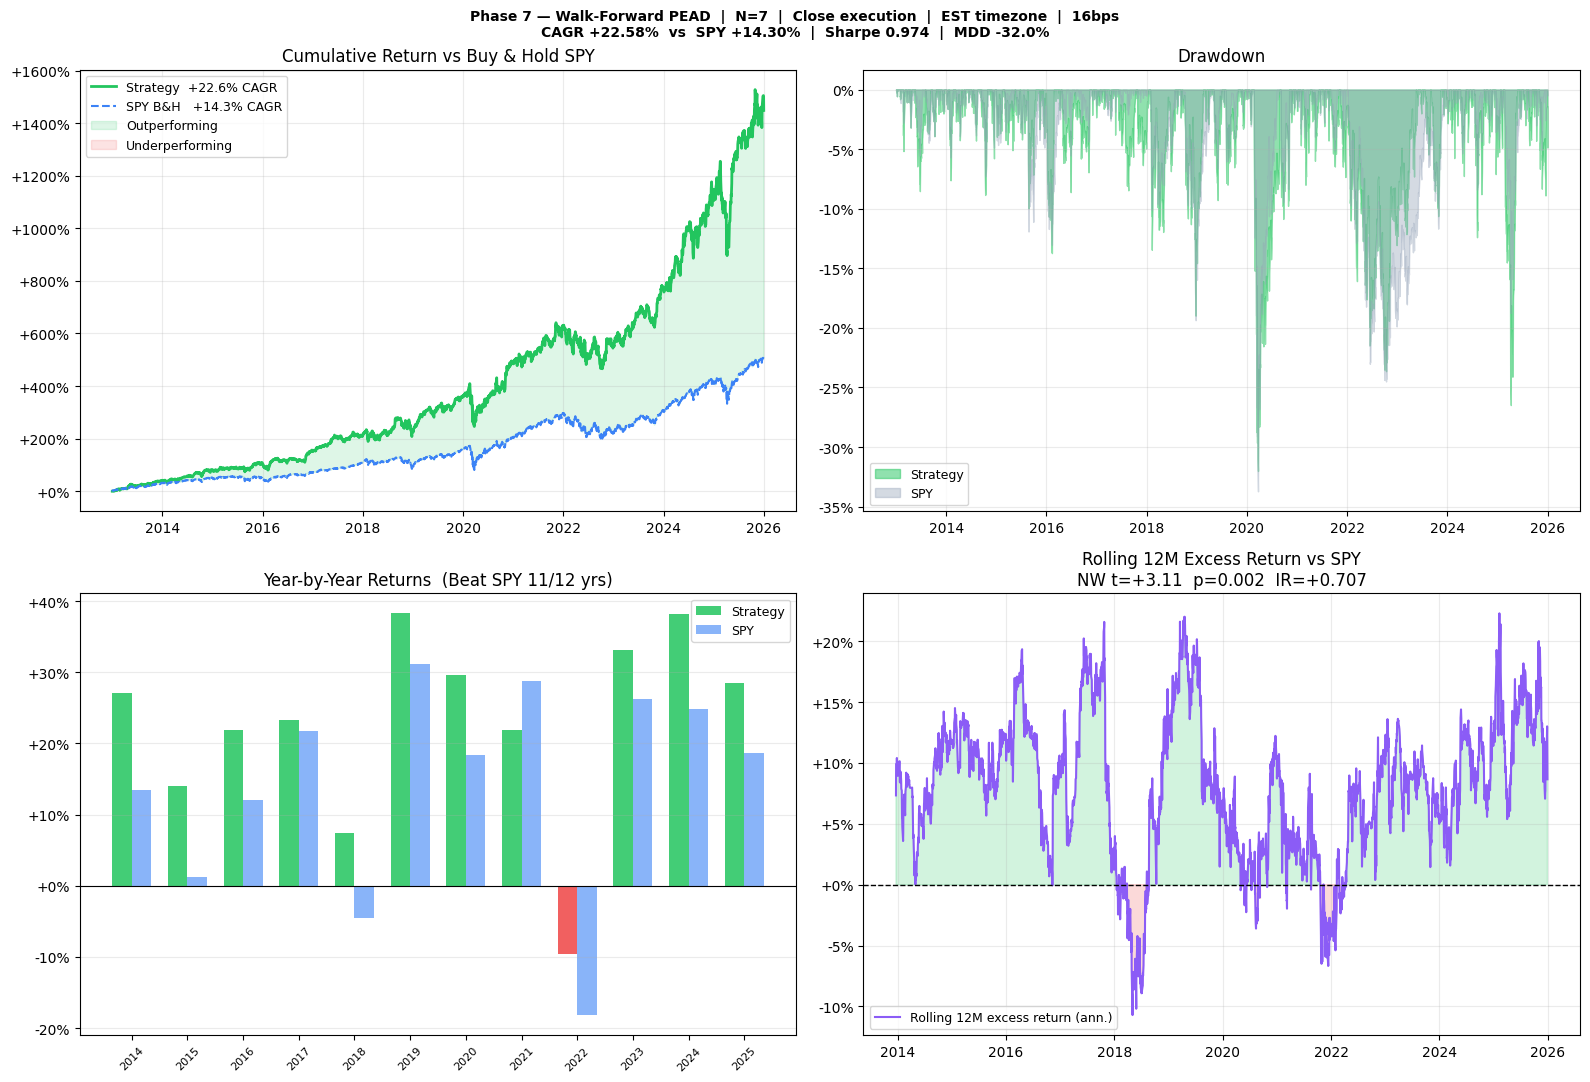

In [49]:
# =====================================================================
# PHASE 7 — WALK-FORWARD PEAD ROTATION BACKTEST
# Self-contained: run this cell alone, no dependencies on other cells
#
# Look-ahead fixes applied:
#   1. SUE_Q recomputed with expanding window within each quarter
#      (stored DB value used full-quarter data — affects ~14% of labels)
#   2. After-close announcements (>=16:00 EST) shift entry to next bday close
#      Timezone converted to America/New_York (handles DST correctly)
#   3. PIT filter confirmed clean — uses most recent quarter <= signal date
#
# Execution model: all entries and exits at closing price
# After-hours earnings: entered at next business day close
# =====================================================================

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
import yfinance as yf
from scipy import stats

GREEN  = '#22C55E'
BLUE   = '#3B82F6'
RED    = '#EF4444'
GOLD   = '#F59E0B'
PURPLE = '#8B5CF6'

PEAD_DB   = 'pead_clean.db'
PIT_DB    = 'real_backtest.db'
SIM_START = pd.Timestamp('2013-01-01')
SIM_END   = pd.Timestamp('2025-12-31')

TARGET_SECTORS_DEFAULT = {'Industrials', 'Technology'}

# =====================================================================
# STEP 1 — Load & clean signal database
# =====================================================================
print("=" * 62)
print("  LOADING DATA")
print("=" * 62)

conn   = sqlite3.connect(PEAD_DB)
df_raw = pd.read_sql("SELECT * FROM pead_clean", conn)
conn.close()

# ── Parse timestamps and convert to EST ──────────────────────────────
df_raw['Date_ts']    = pd.to_datetime(df_raw['Date'], utc=True, errors='coerce')
df_raw['Date_naive'] = pd.to_datetime(df_raw['Date_naive'], utc=True, errors='coerce') \
                          .dt.normalize().dt.tz_localize(None)

# Convert UTC to Eastern time (handles DST automatically)
df_raw['Date_est']   = df_raw['Date_ts'].dt.tz_convert('America/New_York')
df_raw['hour_est']   = df_raw['Date_est'].dt.hour

# ── Entry date logic ──────────────────────────────────────────────────
# Market close is 16:00 EST (4pm)
# Before 16:00 EST  -> enter at same day close (news available before close)
# At or after 16:00 EST -> enter at next business day close
df_raw['entry_date'] = np.where(
    df_raw['hour_est'] >= 16,
    df_raw['Date_naive'].apply(lambda d: pd.bdate_range(start=d, periods=2)[-1]),
    df_raw['Date_naive']
)
df_raw['entry_date'] = pd.to_datetime(df_raw['entry_date'])

after_close_pct = (df_raw['hour_est'] >= 16).mean()
before_close_pct = (df_raw['hour_est'] < 16).mean()
print(f"  Timezone                : EST (America/New_York, DST-aware)")
print(f"  After-close (>=16:00)   : {after_close_pct*100:.1f}% shifted to next bday close")
print(f"  Before-close (<16:00)   : {before_close_pct*100:.1f}% entered same day close")

# ── Deduplicate on (Ticker, entry_date) ───────────────────────────────
dupes = df_raw.duplicated(subset=['Ticker', 'entry_date']).sum()
if dupes > 0:
    df_raw = (df_raw.sort_values('SUE', ascending=False)
              .drop_duplicates(subset=['Ticker', 'entry_date'])
              .sort_values('entry_date')
              .reset_index(drop=True))
    print(f"  Deduped                : {dupes} rows removed")

# ── Drop rows with no SUE ─────────────────────────────────────────────
df_raw = df_raw[df_raw['SUE'].notna()].copy()

# ── FIX 1: Recompute SUE_Q with expanding window within each quarter ──
print("  Recomputing SUE_Q_clean (expanding window — no look-ahead)...")
print("  This takes ~60 seconds...")

df_raw = df_raw.sort_values(['Quarter', 'entry_date']).reset_index(drop=True)
df_raw['SUE_Q_clean'] = np.nan

for quarter, q_grp in df_raw.groupby('Quarter'):
    for ann_date in sorted(q_grp['entry_date'].unique()):
        known_mask = (df_raw['Quarter'] == quarter) & (df_raw['entry_date'] <= ann_date)
        known_sues = df_raw.loc[known_mask, 'SUE'].dropna()
        if len(known_sues) < 5:
            continue
        today_mask = (
            (df_raw['Quarter'] == quarter) &
            (df_raw['entry_date'] == ann_date) &
            df_raw['SUE'].notna()
        )
        b = np.percentile(known_sues.values, [20, 40, 60, 80])
        for idx in df_raw.loc[today_mask].index:
            s = df_raw.loc[idx, 'SUE']
            if   s <= b[0]: df_raw.loc[idx, 'SUE_Q_clean'] = 1.0
            elif s <= b[1]: df_raw.loc[idx, 'SUE_Q_clean'] = 2.0
            elif s <= b[2]: df_raw.loc[idx, 'SUE_Q_clean'] = 3.0
            elif s <= b[3]: df_raw.loc[idx, 'SUE_Q_clean'] = 4.0
            else:           df_raw.loc[idx, 'SUE_Q_clean'] = 5.0

# Q5 only
df_raw = df_raw[df_raw['SUE_Q_clean'] == 5.0].copy()

old_q5 = (df_raw['SUE_Q'] == 5.0).sum()
new_q5 = len(df_raw)
print(f"  Old Q5 (stored, biased) : {old_q5:,}")
print(f"  New Q5 (expanding clean): {new_q5:,}")
print(f"  Change                  : {new_q5 - old_q5:+,} signals")
print(f"\n  pead_clean loaded  : {len(df_raw):,} clean Q5 signals")
print(f"  Tickers            : {df_raw['Ticker'].nunique()}")
print(f"  Date range         : {df_raw['entry_date'].min().date()} "
      f"to {df_raw['entry_date'].max().date()}")
print(f"  Sector breakdown:")
for sec, cnt in df_raw['Sector'].value_counts().items():
    print(f"    {sec:<30} {cnt:>5,}")

# =====================================================================
# STEP 2 — Load PIT membership
# =====================================================================
conn   = sqlite3.connect(PIT_DB)
pit_df = pd.read_sql("SELECT * FROM sp500_pit_membership", conn)
conn.close()

pit_membership = {}
for qdate, grp in pit_df.groupby('quarter_date'):
    pit_membership[pd.Timestamp(qdate)] = set(grp['ticker'])

print(f"\n  PIT membership     : {len(pit_membership)} quarters")
print(f"  PIT range          : {min(pit_membership).date()} to {max(pit_membership).date()}")

def pit_members_nearest(date):
    """Return S&P 500 members as of the most recent quarter <= date."""
    eligible = [d for d in pit_membership if d <= date]
    return pit_membership[max(eligible)] if eligible else set()

# =====================================================================
# STEP 3 — Download OHLC
# =====================================================================
tickers_needed = sorted(df_raw['Ticker'].unique().tolist()) + ['SPY']
print(f"\n  Downloading OHLC for {len(tickers_needed)-1} tickers + SPY...")

raw_px = yf.download(
    tickers_needed,
    start='2012-06-01',
    end=str(SIM_END.date()),
    auto_adjust=True,
    progress=True,
    group_by='column',
)

price_close = raw_px['Close'].ffill()

if price_close.index.tz is not None:
    price_close.index = price_close.index.tz_localize(None)

all_dates_sim = pd.bdate_range(SIM_START, SIM_END)
print(f"  OHLC ready         : {len(tickers_needed)-1} tickers")


# =====================================================================
# HELPERS
# =====================================================================
def get_px(df, ticker, date):
    if ticker not in df.columns:
        return None
    for offset in range(4):
        d = date + pd.offsets.BDay(offset)
        try:
            v = df.loc[d, ticker]
            if pd.notna(v) and v > 0:
                return float(v)
        except KeyError:
            pass
    return None


def perf_p7(eq, rf=0.02):
    eq  = eq.dropna()
    eq  = eq[eq > 0]
    dr  = eq.pct_change(fill_method=None).dropna()
    yrs = len(dr) / 252

    if yrs == 0 or len(eq) < 2:
        return {k: 0 for k in
                ('cagr', 'vol', 'mdd', 'sharpe', 'sortino', 'calmar', 'cum')}

    cagr     = (eq.iloc[-1] / eq.iloc[0]) ** (1 / yrs) - 1
    vol      = dr.std() * np.sqrt(252)
    mdd      = (eq / eq.cummax() - 1).min()
    rf_daily = rf / 252
    excess   = dr - rf_daily
    sharpe   = (excess.mean() / excess.std()) * np.sqrt(252)
    down     = excess[excess < 0].std() * np.sqrt(252)
    sortino  = (excess.mean() * np.sqrt(252)) / down if down != 0 else 0
    calmar   = cagr / abs(mdd) if mdd != 0 else 0

    return dict(
        cagr=cagr, vol=vol, mdd=mdd,
        sharpe=sharpe, sortino=sortino, calmar=calmar,
        cum=eq.iloc[-1] - 1
    )


# =====================================================================
# MAIN BACKTEST FUNCTION
# =====================================================================
def run_backtest(
    n_positions         = 5,
    fee_rt              = 0.0016,
    capital             = 10_000,
    rotation_threshold  = 0.5,
    min_hold_days       = 5,
    sectors             = None,
    verbose             = True,
    plot                = True,
):
    if sectors is None:
        sectors = TARGET_SECTORS_DEFAULT

    # ── Filter signals ────────────────────────────────────────────────
    df = df_raw[df_raw['Sector'].isin(sectors)].copy()
    df = df[
        (df['entry_date'] >= SIM_START) &
        (df['entry_date'] <= SIM_END)
    ].copy()

    df['in_sp500'] = df.apply(
        lambda r: r['Ticker'] in pit_members_nearest(r['entry_date']), axis=1
    )
    signals = df[df['in_sp500']].drop(columns='in_sp500').copy()
    signals = signals[signals['Ticker'].isin(price_close.columns)].copy()

    # Exit at close on business day 22 from entry
    signals['exit_close_date'] = signals['entry_date'].apply(
        lambda d: pd.bdate_range(start=d, periods=23)[-1]
    )
    signals = signals.sort_values('entry_date').reset_index(drop=True)

    if verbose:
        print(f"\n  Signals after all filters : {len(signals):,}")
        print(f"  Signals/year avg          : {len(signals)/12:.0f}")
        for sec, cnt in signals['Sector'].value_counts().items():
            print(f"    {sec:<30} {cnt:>5,}")

    sig_by_date = {}
    for _, row in signals.iterrows():
        sig_by_date.setdefault(row['entry_date'], []).append(row)

    # ── Initialise — SPY parking at close ────────────────────────────
    spy_init = None
    for offset in range(4):
        d = SIM_START + pd.offsets.BDay(offset)
        try:
            v = price_close.loc[d, 'SPY']
            if pd.notna(v) and v > 0:
                spy_init = float(v)
                break
        except KeyError:
            pass

    portfolio       = {}
    trade_log       = []
    daily_nav       = []
    total_fees_paid = 0.0
    spy_shares      = capital / spy_init if spy_init else 0.0
    prev_spy_close  = None

    # ── Simulation loop ───────────────────────────────────────────────
    for date in all_dates_sim:
        spy_close_px = get_px(price_close, 'SPY', date)

        # A: Forced exits — exit at close on day 22
        to_exit = [tkr for tkr, pos in portfolio.items()
                   if pos['exit_close_date'] <= date]
        for tkr in to_exit:
            pos = portfolio.pop(tkr)
            px  = get_px(price_close, tkr, date)
            if not px or px < pos['entry_price'] * 0.10:
                continue
            fee          = pos['shares'] * px * fee_rt
            net_proceeds = pos['shares'] * px * (1 - fee_rt)
            total_fees_paid += fee
            if spy_close_px:
                spy_shares += net_proceeds / spy_close_px
            trade_log.append(dict(
                date=date, ticker=tkr, action='EXIT_FORCED',
                entry_price=pos['entry_price'], exit_price=px,
                shares=pos['shares'], ret=px / pos['entry_price'] - 1,
                hold_days=(date - pos['entry_date']).days,
                sue=pos['sue'], fee=fee,
            ))

        # B: New signals — enter at close
        # Before-close: same day close
        # After-close: already shifted to next bday close in Step 1
        if date in sig_by_date:
            new_sigs = sorted(
                sig_by_date[date], key=lambda r: r['SUE'], reverse=True
            )
            for sig in new_sigs:
                tkr      = sig['Ticker']
                sue      = float(sig['SUE'])
                if tkr in portfolio:
                    continue
                entry_px = get_px(price_close, tkr, date)
                if entry_px is None or entry_px <= 0:
                    continue

                nav = spy_shares * (spy_close_px or 1)
                for t, p in portfolio.items():
                    nav += p['shares'] * (
                        get_px(price_close, t, date) or p['entry_price']
                    )

                # Fill empty slot
                if len(portfolio) < n_positions:
                    spy_value = spy_shares * (spy_close_px or 1)
                    slot_size = min(nav / n_positions, spy_value / (1 + fee_rt))
                    if slot_size <= 0:
                        continue
                    fee             = slot_size * fee_rt
                    spy_shares     -= slot_size * (1 + fee_rt) / (spy_close_px or 1)
                    total_fees_paid += fee
                    portfolio[tkr]  = dict(
                        entry_date=date,
                        exit_close_date=sig['exit_close_date'],
                        entry_price=entry_px,
                        sue=sue,
                        shares=slot_size / entry_px,
                    )
                    trade_log.append(dict(
                        date=date, ticker=tkr, action='ENTER',
                        entry_price=entry_px,
                        shares=slot_size / entry_px,
                        sue=sue, fee=fee,
                    ))

                # Rotation
                else:
                    min_tkr   = min(portfolio, key=lambda t: portfolio[t]['sue'])
                    min_sue   = portfolio[min_tkr]['sue']
                    held_days = (date - portfolio[min_tkr]['entry_date']).days

                    if (sue > min_sue + rotation_threshold
                            and held_days >= min_hold_days):
                        eject    = portfolio.pop(min_tkr)
                        eject_px = get_px(price_close, min_tkr, date)
                        if (eject_px is None
                                or eject_px < eject['entry_price'] * 0.10):
                            portfolio[min_tkr] = eject
                            continue

                        fee_exit  = eject['shares'] * eject_px * fee_rt
                        proceeds  = eject['shares'] * eject_px * (1 - fee_rt)
                        total_fees_paid += fee_exit
                        trade_log.append(dict(
                            date=date, ticker=min_tkr, action='EXIT_ROTATED',
                            entry_price=eject['entry_price'],
                            exit_price=eject_px,
                            shares=eject['shares'],
                            ret=eject_px / eject['entry_price'] - 1,
                            hold_days=(date - eject['entry_date']).days,
                            sue=eject['sue'], fee=fee_exit,
                        ))

                        slot_size       = nav / n_positions
                        fee_entry       = slot_size * fee_rt
                        shares          = slot_size / (entry_px * (1 + fee_rt))
                        cost            = shares * entry_px * (1 + fee_rt)
                        total_fees_paid += fee_entry
                        if spy_close_px:
                            spy_shares += (proceeds - cost) / spy_close_px
                        portfolio[tkr] = dict(
                            entry_date=date,
                            exit_close_date=sig['exit_close_date'],
                            entry_price=entry_px,
                            sue=sue,
                            shares=shares,
                        )
                        trade_log.append(dict(
                            date=date, ticker=tkr, action='ENTER',
                            entry_price=entry_px, shares=shares,
                            sue=sue, fee=fee_entry,
                        ))

        # C: Daily NAV — mark to market at close
        spy_px  = spy_close_px or prev_spy_close or 0
        nav_eod = spy_shares * spy_px
        for tkr, pos in portfolio.items():
            px       = get_px(price_close, tkr, date) or pos['entry_price']
            nav_eod += pos['shares'] * (
                px if px > pos['entry_price'] * 0.10 else pos['entry_price']
            )
        daily_nav.append(dict(date=date, nav=nav_eod, n_pos=len(portfolio)))
        if spy_close_px:
            prev_spy_close = spy_close_px

    # ── Build equity curves ───────────────────────────────────────────
    nav_df = pd.DataFrame(daily_nav).set_index('date')
    eq_p7  = nav_df['nav'] / capital

    spy_raw = price_close['SPY'].copy()
    if spy_raw.index.tz is not None:
        spy_raw.index = spy_raw.index.tz_localize(None)
    spy_aligned = spy_raw.reindex(
        eq_p7.index.union(spy_raw.index)
    ).ffill().reindex(eq_p7.index)

    first_valid = spy_aligned.first_valid_index()
    if first_valid is None:
        print("ERROR: SPY price data missing")
        return eq_p7, pd.Series(dtype=float), {}, pd.DataFrame()

    eq_spy_p7 = spy_aligned / spy_aligned[first_valid]
    eq_p7     = eq_p7.loc[first_valid:]
    eq_spy_p7 = eq_spy_p7.loc[first_valid:]

    # ── Metrics ───────────────────────────────────────────────────────
    tl_df   = pd.DataFrame(trade_log)
    metrics = perf_p7(eq_p7)
    spy_m   = perf_p7(eq_spy_p7)
    metrics['spy_cagr']    = spy_m.get('cagr',   0)
    metrics['spy_sharpe']  = spy_m.get('sharpe',  0)
    metrics['spy_mdd']     = spy_m.get('mdd',     0)
    metrics['total_fees']  = total_fees_paid
    metrics['n_entries']   = int((tl_df['action'] == 'ENTER').sum())
    metrics['n_forced']    = int((tl_df['action'] == 'EXIT_FORCED').sum())
    metrics['n_rotations'] = int((tl_df['action'] == 'EXIT_ROTATED').sum())
    metrics['avg_pos']     = nav_df['n_pos'].mean()

    # ── Statistical significance ──────────────────────────────────────
    strat_dr = eq_p7.pct_change(fill_method=None).dropna()
    spy_dr   = eq_spy_p7.pct_change(fill_method=None).dropna()
    strat_dr, spy_dr = strat_dr.align(spy_dr, join='inner')
    excess   = (strat_dr - spy_dr).dropna()

    if len(excess) == 0:
        print("WARNING: excess return series empty")
        return eq_p7, eq_spy_p7, metrics, tl_df

    y        = excess.values
    X        = sm.add_constant(np.ones(len(y)))
    nw_model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 21})
    nw_tstat = float(nw_model.tvalues[0])
    nw_pval  = float(nw_model.pvalues[0])

    T        = len(strat_dr)
    sr_tstat = metrics['sharpe'] * np.sqrt(T / 252)
    sr_pval  = 1 - stats.norm.cdf(sr_tstat)

    ir = (excess.mean() / excess.std() * np.sqrt(252)
          if excess.std() != 0 else 0)

    np.random.seed(42)
    boot_cagrs = []
    for _ in range(2000):
        s = np.random.choice(strat_dr.values, size=len(strat_dr), replace=True)
        boot_cagrs.append(np.prod(1 + s) ** (1 / (len(s) / 252)) - 1)
    ci_lo, ci_hi = np.percentile(boot_cagrs, [2.5, 97.5])

    yoy_s   = eq_p7.resample('YE').last().pct_change(fill_method=None).dropna()
    yoy_spy = eq_spy_p7.resample('YE').last().pct_change(fill_method=None).dropna()
    yoy_df  = pd.concat([yoy_s, yoy_spy], axis=1).dropna()
    yoy_df.columns = ['strat', 'spy']
    yoy_df.index   = yoy_df.index.year
    beat_yrs = int((yoy_df['strat'] > yoy_df['spy']).sum())

    metrics.update(dict(
        nw_tstat=nw_tstat, nw_pval=nw_pval,
        sr_tstat=sr_tstat, sr_pval=sr_pval,
        ir=ir, ci_lo=ci_lo, ci_hi=ci_hi,
        beat_yrs=beat_yrs, total_yrs=len(yoy_df),
        yoy_df=yoy_df,
    ))

    # ── Verbose output ────────────────────────────────────────────────
    if verbose:
        SEP  = '=' * 62
        SEP2 = '-' * 58

        end_val      = capital * (1 + metrics['cum'])
        profit       = end_val - capital
        spy_end_val  = capital * (1 + spy_m.get('cum', 0))
        spy_profit   = spy_end_val - capital
        edge_dollars = profit - spy_profit
        n_yrs        = len(strat_dr) / 252
        monthly_contrib = capital / 12
        fv_strat = sum(
            monthly_contrib * (1 + metrics['cagr']) ** ((n_yrs * 12 - i) / 12)
            for i in range(int(n_yrs * 12))
        )
        fv_spy = sum(
            monthly_contrib * (1 + metrics['spy_cagr']) ** ((n_yrs * 12 - i) / 12)
            for i in range(int(n_yrs * 12))
        )

        print(f"\n{SEP}")
        print(f"  PHASE 7  |  N={n_positions}  |  {', '.join(sorted(sectors))}")
        print(f"  Execution : close price  |  EST timezone  |  16bps  |  Look-ahead clean")
        print(f"  After-hrs : >=16:00 EST shifted to next bday close")
        print(SEP)

        print(f"\n  RETURNS")
        print(f"  {SEP2}")
        print(f"  CAGR                  : {metrics['cagr']*100:>+.2f}%")
        print(f"  CAGR 95% CI (boot)    : [{ci_lo*100:>+.2f}%, {ci_hi*100:>+.2f}%]")
        print(f"  SPY CAGR              : {metrics['spy_cagr']*100:>+.2f}%")
        print(f"  Edge vs SPY           : {(metrics['cagr']-metrics['spy_cagr'])*100:>+.2f}pp")
        print(f"  Cumulative return     : {metrics['cum']*100:>+.2f}%")

        print(f"\n  DOLLAR RETURNS  (starting capital ${capital:,.0f})")
        print(f"  {SEP2}")
        print(f"  Ending value          : ${end_val:>12,.2f}")
        print(f"  Total profit          : ${profit:>12,.2f}")
        print(f"  SPY ending value      : ${spy_end_val:>12,.2f}")
        print(f"  SPY total profit      : ${spy_profit:>12,.2f}")
        print(f"  Alpha ($ vs SPY)      : ${edge_dollars:>12,.2f}")
        print(f"  Fees paid             : ${metrics['total_fees']:>12,.2f}")
        print(f"  Net alpha after fees  : ${edge_dollars - metrics['total_fees']:>12,.2f}")
        print(f"  Return per $1 risk    : ${end_val/capital:>12.2f}")
        print(f"\n  IF YOU ADDED ${monthly_contrib:,.0f}/mo (${capital:,.0f}/yr):")
        print(f"  Strategy portfolio    : ${fv_strat:>12,.2f}")
        print(f"  SPY portfolio         : ${fv_spy:>12,.2f}")
        print(f"  Extra wealth vs SPY   : ${fv_strat - fv_spy:>12,.2f}")

        print(f"\n  RISK")
        print(f"  {SEP2}")
        print(f"  Max Drawdown          : {metrics['mdd']*100:>+.2f}%")
        print(f"  SPY Max Drawdown      : {metrics['spy_mdd']*100:>+.2f}%")
        print(f"  Annualised Vol        : {metrics['vol']*100:>+.2f}%")
        print(f"  Sharpe Ratio          : {metrics['sharpe']:>+.3f}")
        print(f"  SPY Sharpe Ratio      : {metrics['spy_sharpe']:>+.3f}")
        print(f"  Sortino Ratio         : {metrics['sortino']:>+.3f}")
        print(f"  Calmar Ratio          : {metrics['calmar']:>+.3f}")
        print(f"  Information Ratio     : {ir:>+.3f}"
              f"{'  strong' if ir > 0.5 else '  moderate' if ir > 0 else '  negative'}")

        print(f"\n  STATISTICAL SIGNIFICANCE")
        print(f"  {SEP2}")
        print(f"  NW HAC lag            : 21 days (matches hold period)")
        print(f"  Excess return (NW HAC): t={nw_tstat:>+.3f}  p={nw_pval:.4f}"
              f"{'  sig @ 5%' if nw_pval < 0.05 else '  not sig'}")
        print(f"  Sharpe t-stat (Lo02)  : t={sr_tstat:>+.3f}  p={sr_pval:.4f}"
              f"{'  sig @ 5%' if sr_pval < 0.05 else '  not sig'}")
        print(f"  Information Ratio     : {ir:>+.3f}"
              f"{'  strong' if ir > 0.5 else '  moderate' if ir > 0 else '  negative'}")
        print(f"  Beat SPY years        : {beat_yrs}/{len(yoy_df)}")

        print(f"\n  YEAR-BY-YEAR vs SPY")
        print(f"  {SEP2}")
        print(f"  {'Year':<6} {'Strategy':>10} {'SPY':>8} {'Edge':>8}")
        print(f"  {'-'*36}")
        for yr, row in yoy_df.iterrows():
            flag = 'beat' if row['strat'] > row['spy'] else 'miss'
            print(f"  {yr:<6} {row['strat']*100:>+9.2f}%"
                  f" {row['spy']*100:>+7.2f}%"
                  f" {(row['strat']-row['spy'])*100:>+7.2f}%  {flag}")

        print(f"\n  TRADING ACTIVITY")
        print(f"  {SEP2}")
        print(f"  Entries               : {metrics['n_entries']:,}")
        print(f"  Forced exits (day 22) : {metrics['n_forced']:,}")
        print(f"  Rotation exits        : {metrics['n_rotations']:,}")
        print(f"  Total fees paid       : ${metrics['total_fees']:>10,.2f}")
        print(f"  Avg concurrent pos    : {metrics['avg_pos']:.1f}")
        print(SEP)

    # ── Chart ─────────────────────────────────────────────────────────
    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(16, 11))
        fig.suptitle(
            f"Phase 7 — Walk-Forward PEAD  |  N={n_positions}"
            f"  |  Close execution  |  EST timezone  |  16bps\n"
            f"CAGR {metrics['cagr']*100:+.2f}%  vs  SPY {metrics['spy_cagr']*100:+.2f}%"
            f"  |  Sharpe {metrics['sharpe']:.3f}"
            f"  |  MDD {metrics['mdd']*100:.1f}%",
            fontsize=10, fontweight='bold',
        )

        ax1 = axes[0, 0]
        cum_strat = (eq_p7 - 1) * 100
        cum_spy   = (eq_spy_p7 - 1) * 100
        ax1.plot(cum_strat.index, cum_strat, color=GREEN, lw=2,
                 label=f"Strategy  {metrics['cagr']*100:+.1f}% CAGR")
        ax1.plot(cum_spy.index, cum_spy, color=BLUE, lw=1.5, ls='--',
                 label=f"SPY B&H   {metrics['spy_cagr']*100:+.1f}% CAGR")
        ax1.fill_between(cum_strat.index, cum_strat, cum_spy,
                         where=cum_strat >= cum_spy, alpha=0.15,
                         color=GREEN, label='Outperforming')
        ax1.fill_between(cum_strat.index, cum_strat, cum_spy,
                         where=cum_strat < cum_spy, alpha=0.15,
                         color=RED, label='Underperforming')
        ax1.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
        ax1.set_title('Cumulative Return vs Buy & Hold SPY')
        ax1.legend(fontsize=9); ax1.grid(True, alpha=0.25)

        ax2 = axes[0, 1]
        dd_s   = (eq_p7     / eq_p7.cummax()     - 1) * 100
        dd_spy = (eq_spy_p7 / eq_spy_p7.cummax() - 1) * 100
        ax2.fill_between(dd_s.index,   dd_s,   color=GREEN,     alpha=0.5, label='Strategy')
        ax2.fill_between(dd_spy.index, dd_spy, color='#94A3B8', alpha=0.4, label='SPY')
        ax2.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
        ax2.set_title('Drawdown')
        ax2.legend(fontsize=9); ax2.grid(True, alpha=0.25)

        ax3 = axes[1, 0]
        x = np.arange(len(yoy_df)); w = 0.35
        ax3.bar(x - w/2, yoy_df['strat'] * 100, w,
                color=[GREEN if v > 0 else RED for v in yoy_df['strat']],
                alpha=0.85, label='Strategy')
        ax3.bar(x + w/2, yoy_df['spy'] * 100, w,
                color=BLUE, alpha=0.6, label='SPY')
        ax3.axhline(0, color='black', lw=0.8)
        ax3.set_xticks(x)
        ax3.set_xticklabels(yoy_df.index, rotation=45, fontsize=8)
        ax3.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
        ax3.set_title(f'Year-by-Year Returns  (Beat SPY {beat_yrs}/{len(yoy_df)} yrs)')
        ax3.legend(fontsize=9); ax3.grid(True, alpha=0.25, axis='y')

        ax4 = axes[1, 1]
        roll_excess = excess.rolling(252).mean() * 252 * 100
        ax4.plot(roll_excess.index, roll_excess, color=PURPLE, lw=1.5,
                 label='Rolling 12M excess return (ann.)')
        ax4.axhline(0, color='black', lw=1.0, ls='--')
        ax4.fill_between(roll_excess.index, roll_excess, 0,
                         where=roll_excess >= 0, alpha=0.2, color=GREEN)
        ax4.fill_between(roll_excess.index, roll_excess, 0,
                         where=roll_excess < 0,  alpha=0.2, color=RED)
        ax4.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
        ax4.set_title(
            f'Rolling 12M Excess Return vs SPY\n'
            f'NW t={nw_tstat:+.2f}  p={nw_pval:.3f}  IR={ir:+.3f}')
        ax4.legend(fontsize=9); ax4.grid(True, alpha=0.25)

        plt.tight_layout()
        plt.savefig('phase7_rotation_est.png', dpi=150, bbox_inches='tight')
        plt.show()

    return eq_p7, eq_spy_p7, metrics, tl_df, nav_df


# =====================================================================
# RUN
# =====================================================================
eq_base, eq_spy, m_base, tl_base, nav_df = run_backtest(
    n_positions=7,
    sectors={'Industrials', 'Technology'},
    verbose=True, plot=True,
)

In [50]:
ff6     = {}
ff_pass = None

try:
    def read_zip(path, filename):
        with open(path, 'rb') as f:
            zf  = zipfile.ZipFile(io.BytesIO(f.read()))
            raw = zf.read(filename).decode('utf-8', errors='ignore')
        lines = raw.splitlines()
        start = next(i for i, l in enumerate(lines)
                     if 'Mkt-RF' in l or 'Mom' in l)
        df = pd.read_csv(
            io.StringIO('\n'.join(lines[start:])),
            header=0, index_col=0
        )
        df = df[df.index.astype(str).str.strip().str.match(r'^\d{8}$')]
        df.index = pd.to_datetime(
            df.index.astype(str).str.strip(), format='%Y%m%d')
        df = df.astype(float) / 100
        df.columns = df.columns.str.strip()
        return df

    ff5 = read_zip('ff5_daily.zip',
                   'F-F_Research_Data_5_Factors_2x3_daily.csv')
    mom = read_zip('mom_daily.zip',
                   'F-F_Momentum_Factor_daily.csv')
    mom.columns = ['MOM']
    ff  = ff5.join(mom, how='inner').loc[strat_dr.index[0]:]

    strat_exc_ff = (strat_dr - ff['RF']).dropna()
    strat_exc_ff, ff_aligned = strat_exc_ff.align(
        ff[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']], join='inner'
    )

    models = [
        ('CAPM (1-factor)',    ['Mkt-RF']),
        ('FF3 (3-factor)',     ['Mkt-RF', 'SMB', 'HML']),
        ('FF5 (5-factor)',     ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']),
        ('FF5+MOM (6-factor)', ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']),
    ]

    print(f"  {'Model':<20} {'Ann. Alpha':>11} {'p-value':>8} {'R2':>6}  Result")
    print(f"  {'-'*64}")

    ff_results = {}
    for label, factors in models:
        X_m = sm.add_constant(ff_aligned[factors])
        m   = sm.OLS(strat_exc_ff, X_m).fit(
            cov_type='HAC', cov_kwds={'maxlags': 22})
        a   = m.params['const'] * 252 * 100
        p   = m.pvalues['const']
        r2  = m.rsquared * 100
        res = 'PASS  sig @ 5%' if p < 0.05 else 'FAIL  not sig'
        print(f"  {label:<20} {a:>+10.2f}%  {p:>7.4f}  {r2:>5.1f}%  {res}")
        ff_results[label] = dict(alpha=a, pval=p, r2=r2)

    ff6     = ff_results['FF5+MOM (6-factor)']
    ff_pass = ff6['pval'] < 0.05

    print(f"\n  Plain English: After removing the return explained by")
    print(f"  six systematic risk factors, the strategy still generates")
    print(f"  {ff6['alpha']:+.2f}% per year of unexplained alpha")
    print(f"  (p = {ff6['pval']:.4f}). This alpha cannot be attributed")
    print(f"  to any known risk premium.")

except Exception as e:
    print(f"  FF load failed: {e}")
    ff_pass = False
    ff6     = dict(alpha=0, pval=1.0, r2=0)

  Model                 Ann. Alpha  p-value     R2  Result
  ----------------------------------------------------------------
  CAPM (1-factor)           +7.49%   0.0048   76.0%  PASS  sig @ 5%
  FF3 (3-factor)            +7.39%   0.0056   76.3%  PASS  sig @ 5%
  FF5 (5-factor)            +7.45%   0.0051   76.4%  PASS  sig @ 5%
  FF5+MOM (6-factor)        +7.20%   0.0067   76.6%  PASS  sig @ 5%

  Plain English: After removing the return explained by
  six systematic risk factors, the strategy still generates
  +7.20% per year of unexplained alpha
  (p = 0.0067). This alpha cannot be attributed
  to any known risk premium.


In [51]:
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'MOM']
X = sm.add_constant(ff_aligned[factors])

m = sm.OLS(strat_exc_ff, X).fit(
    cov_type='HAC', cov_kwds={'maxlags': 22}
)

print("\nFF6 Factor Betas:")
for f in factors:
    print(f"{f:<7} beta = {m.params[f]:>+6.3f} "
          f"(t={m.tvalues[f]:>5.2f}, p={m.pvalues[f]:.4f})")


FF6 Factor Betas:
Mkt-RF  beta = +1.057 (t=59.03, p=0.0000)
SMB     beta = +0.005 (t= 0.18, p=0.8580)
HML     beta = -0.065 (t=-2.53, p=0.0113)
RMW     beta = -0.013 (t=-0.43, p=0.6677)
CMA     beta = -0.016 (t=-0.36, p=0.7217)
MOM     beta = +0.071 (t= 4.18, p=0.0000)
